# GTEx CellMarker Validation

Consolidated CellMarker analysis for the true-label RF/SHAP results.

This notebook uses **one language only: R**. It loads `CLAMPfull.rds` directly, reads the true-label SHAP outputs, and tests whether CellMarker 2024 recovers tissue biology for the cumulative-25% SHAP selection.

For each tissue, the selected LVs are the top-ranked LVs needed to reach 25% cumulative SHAP importance. For each selected LV, ORA is run on high-loading CLAMP `Z` genes ranked by decreasing raw loading. Significance is evaluated at a fixed FDR threshold of 0.10.


Environment: `clamp-analyses` / R kernel


In [1]:
library(here)
library(dplyr)
library(tidyr)
library(stringr)
library(ggplot2)
library(tibble)

set.seed(42)


here() starts at /home/msubirana/Documents/pivlab/clamp-analyses




Attaching package: ‘dplyr’




The following objects are masked from ‘package:stats’:

    filter, lag




The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [2]:
SHAP_DIR <- here('output', '03_model_biology', '01_gtex', '03_rf_true_labels',
                 '00_LV_importance_true_labels',
                 'gtex_feature_importance_true_labels_binary_shap')
OUT_DIR <- here('output', '03_model_biology', '01_gtex', '03_rf_true_labels',
                '03_cellmarker_validation')
dir.create(OUT_DIR, recursive = TRUE, showWarnings = FALSE)

CLAMP_RDS <- here('output', '01_model_building', '02_gtex', '01_CLAMP', 'CLAMPfull.rds')
CELLMARKER_FILE <- here('data', 'pathways', 'CellMarker_2024.txt')

CUMULATIVE_PCT <- 25
GENE_LOADING_FRACTION <- 0.01
FDR_THRESH <- 0.10
MIN_GS_SIZE <- 10L
MAX_GS_SIZE <- 500L
TOP_TERMS_PER_LV <- 3L


## Load Cumulative-25% SHAP Selection


In [3]:
shap_all <- read.delim(file.path(SHAP_DIR, 'all_shap_positive.tsv'),
                       stringsAsFactors = FALSE, check.names = FALSE)
accuracy <- read.delim(file.path(SHAP_DIR, 'accuracy_summary.tsv'),
                       stringsAsFactors = FALSE, check.names = FALSE)

selected_lvs_cum <- shap_all %>%
    arrange(Tissue, Rank) %>%
    group_by(Tissue) %>%
    mutate(
        cutoff_rank = if (any(Cumulative_Percent >= CUMULATIVE_PCT)) {
            min(Rank[Cumulative_Percent >= CUMULATIVE_PCT])
        } else {
            max(Rank)
        }
    ) %>%
    filter(Rank <= cutoff_rank) %>%
    ungroup() %>%
    rename(LV = Feature) %>%
    select(Tissue, LV, Rank, Mean_SHAP_Tissue, Cumulative_SHAP, Cumulative_Percent)

all_selected_lvs <- sort(unique(selected_lvs_cum$LV))

cat('Tissues:', n_distinct(selected_lvs_cum$Tissue), '
')
cat(sprintf('cumulative25: %d LV/tissue rows; %d unique LVs
',
            nrow(selected_lvs_cum), n_distinct(selected_lvs_cum$LV)))

selected_lvs_cum %>%
    count(Tissue, name = 'n_selected_lvs') %>%
    arrange(Tissue)


Tissues: 49 


cumulative25: 226 LV/tissue rows; 124 unique LVs


Tissue,n_selected_lvs
<chr>,<int>
Adipose - Subcutaneous,6
Adipose - Visceral (Omentum),5
Adrenal Gland,2
Artery - Aorta,3
Artery - Coronary,4
Artery - Tibial,4
Brain - Amygdala,4
Brain - Anterior cingulate cortex (BA24),6
Brain - Caudate (basal ganglia),8


## Load CLAMP gene loadings


In [4]:
clamp <- readRDS(CLAMP_RDS)
Z <- as.matrix(clamp$Z)
rm(clamp)

missing_lvs <- setdiff(all_selected_lvs, colnames(Z))
if (length(missing_lvs) > 0) {
    stop('Missing selected LVs in CLAMP Z matrix: ', paste(head(missing_lvs, 10), collapse = ', '))
}

universe_genes <- rownames(Z)
n_top_genes <- max(1L, ceiling(GENE_LOADING_FRACTION * nrow(Z)))

cat('Z matrix:', nrow(Z), 'genes x', ncol(Z), 'LVs
')
cat('Top genes per LV:', n_top_genes, '
')


Z matrix: 21613 genes x 578 LVs


Top genes per LV: 217 


## Load CellMarker 2024

CellMarker 2024 is stored as a GMT-style text file. Only `Human` marker sets are used. GTEx tissue matching uses a curated keyword map because CellMarker terms encode cell type and tissue in free text rather than a structured tissue column.


In [5]:

read_cellmarker_human <- function(filename) {
    lines <- readLines(filename, warn = FALSE)
    term_sets <- list()
    for (line in lines) {
        parts <- strsplit(line, '\t', fixed = FALSE)[[1]]
        if (length(parts) < 3) next
        term <- parts[[1]]
        if (!endsWith(term, ' Human')) next
        genes <- unique(parts[3:length(parts)])
        genes <- genes[nzchar(genes)]
        if (length(genes) > 0) term_sets[[term]] <- sort(genes)
    }
    term_sets
}

cellmarker_t2g <- read_cellmarker_human(CELLMARKER_FILE)
cat('CellMarker 2024 human sets:', length(cellmarker_t2g), '\n')
cat('Unique CellMarker genes:', length(unique(unlist(cellmarker_t2g))), '\n')

tissue_keywords <- c(
    'Adipose - Subcutaneous' = '\\bAdipose\\b|\\bFat\\b',
    'Adipose - Visceral (Omentum)' = '\\bAdipose\\b|\\bFat\\b|Omentum',
    'Adrenal Gland' = 'Adrenal',
    'Artery - Aorta' = '\\bArtery\\b|Aorta',
    'Artery - Coronary' = '\\bArtery\\b|Coronary',
    'Artery - Tibial' = '\\bArtery\\b|Tibial',
    'Bladder' = 'Bladder',
    'Brain - Amygdala' = 'Brain|Amygdala',
    'Brain - Anterior cingulate cortex (BA24)' = 'Brain|Cortex|Cingulate',
    'Brain - Caudate (basal ganglia)' = 'Brain|Caudate|Basal Ganglia',
    'Brain - Cerebellar Hemisphere' = 'Brain|Cerebell',
    'Brain - Cerebellum' = 'Brain|Cerebell',
    'Brain - Cortex' = 'Brain|Cortex',
    'Brain - Frontal Cortex (BA9)' = 'Brain|Cortex|Frontal',
    'Brain - Hippocampus' = 'Brain|Hippocampus',
    'Brain - Hypothalamus' = 'Brain|Hypothalamus',
    'Brain - Nucleus accumbens (basal ganglia)' = 'Brain|Nucleus Accumbens|Basal Ganglia',
    'Brain - Putamen (basal ganglia)' = 'Brain|Putamen|Basal Ganglia',
    'Brain - Spinal cord (cervical c-1)' = 'Brain|Spinal Cord',
    'Brain - Substantia nigra' = 'Brain|Substantia Nigra',
    'Breast - Mammary Tissue' = 'Breast|Mammary',
    'Cells - Cultured fibroblasts' = 'Fibroblast',
    'Cells - EBV-transformed lymphocytes' = 'Lymphocyte|B Cell|Blood|Immune',
    'Cervix - Ectocervix' = 'Cervix',
    'Cervix - Endocervix' = 'Cervix',
    'Colon - Sigmoid' = 'Colon',
    'Colon - Transverse' = 'Colon',
    'Esophagus - Gastroesophageal Junction' = 'Esophag|Gastroesophageal',
    'Esophagus - Mucosa' = 'Esophag',
    'Esophagus - Muscularis' = 'Esophag',
    'Fallopian Tube' = 'Fallopian',
    'Heart - Atrial Appendage' = 'Heart|Cardiac|Cardiomyocyte|Atrium|Atrial',
    'Heart - Left Ventricle' = 'Heart|Cardiac|Cardiomyocyte|Ventricle|Ventricular',
    'Kidney - Cortex' = 'Kidney|Renal',
    'Liver' = 'Liver|Hepat',
    'Lung' = 'Lung',
    'Minor Salivary Gland' = 'Salivary',
    'Muscle - Skeletal' = 'Skeletal Muscle|Muscle|Myocyte',
    'Nerve - Tibial' = 'Nerve|Neuron|Schwann',
    'Ovary' = 'Ovar',
    'Pancreas' = 'Pancrea|Islet',
    'Pituitary' = 'Pituitary',
    'Prostate' = 'Prostate',
    'Skin - Not Sun Exposed (Suprapubic)' = 'Skin|Epiderm|Keratinocyte|Melanocyte',
    'Skin - Sun Exposed (Lower leg)' = 'Skin|Epiderm|Keratinocyte|Melanocyte',
    'Small Intestine - Terminal Ileum' = 'Intestine|Ileum',
    'Spleen' = 'Spleen',
    'Stomach' = 'Stomach|Gastric',
    'Testis' = 'Testi(s|cular)',
    'Thyroid' = 'Thyroid',
    'Uterus' = 'Uterus|Uterine',
    'Vagina' = 'Vagin',
    'Whole Blood' = 'Blood|Immune|Leukocyte|Lymphocyte|Monocyte|Neutrophil|T Cell|B Cell|NK Cell'
)

term_names <- names(cellmarker_t2g)
tissue_to_terms <- lapply(sort(unique(shap_all$Tissue)), function(tissue) {
    pattern <- unname(tissue_keywords[tissue])
    if (length(pattern) == 0 || is.na(pattern)) return(character(0))
    term_names[grepl(pattern, term_names, ignore.case = TRUE)]
})
names(tissue_to_terms) <- sort(unique(shap_all$Tissue))

# Related-biology calls are LV-specific and must be backed by an enriched CellMarker term.
# They are used to annotate biologically concordant assignments that exact tissue-name matching misses.
related_biology_evidence <- tribble(
    ~Tissue, ~LV, ~Related_CellMarker_Term, ~Related_Biology,
    'Adrenal Gland', 'LV183', 'Leydig Cell Fetal Gonad Human', 'steroidogenic endocrine program shared with adrenal cortex',
    'Adrenal Gland', 'LV183', 'Sertoli Cell Fetal Gonad Human', 'steroidogenic endocrine program shared with adrenal cortex',
    'Adrenal Gland', 'LV3', 'Leydig Cell Fetal Gonad Human', 'steroidogenic endocrine program shared with adrenal cortex',
    'Adrenal Gland', 'LV3', 'Sertoli Cell Fetal Gonad Human', 'steroidogenic endocrine program shared with adrenal cortex',
    'Brain - Nucleus accumbens (basal ganglia)', 'LV494', 'Dopamine Neuron Skin Human', 'dopaminergic neuronal program expected for basal ganglia circuitry',
    'Colon - Sigmoid', 'LV322', 'Neuron Epithelium Human', 'enteric neuronal/neuroendocrine program in gut wall',
    'Esophagus - Gastroesophageal Junction', 'LV142', 'Pit Progenitor Cell Stomach Human', 'gastric epithelial program expected at the gastroesophageal junction',
    'Esophagus - Mucosa', 'LV330', 'Secretory Cell Airway Epithelium Human', 'KRT4/SERPINB3 mucosal epithelial program shared with squamous mucosa',
    'Minor Salivary Gland', 'LV513', 'Secretory Cell Lung Human', 'secretory epithelial program expected in salivary gland',
    'Minor Salivary Gland', 'LV513', 'Ductal Cell Pancreas Human', 'ductal epithelial program expected in salivary gland',
    'Minor Salivary Gland', 'LV513', 'Epithelial Cell Lung Human', 'secretory/ductal epithelial program expected in salivary gland',
    'Minor Salivary Gland', 'LV513', 'Cholangiocyte Liver Human', 'ductal epithelial program expected in salivary gland',
    'Minor Salivary Gland', 'LV58', 'Secretory Cell Lung Human', 'secretory epithelial program expected in salivary gland',
    'Minor Salivary Gland', 'LV58', 'Goblet Cell Epithelium Human', 'mucosal secretory epithelial program expected in salivary gland',
    'Minor Salivary Gland', 'LV58', 'Goblet Cell Small Intestine Human', 'mucosal secretory epithelial program expected in salivary gland',
    'Minor Salivary Gland', 'LV58', 'Goblet Cell Large Intestine Human', 'mucosal secretory epithelial program expected in salivary gland',
    'Minor Salivary Gland', 'LV58', 'Epithelial Cell Stomach Human', 'secretory epithelial program expected in salivary gland',
    'Ovary', 'LV32', 'Leydig Cell Fetal Gonad Human', 'gonadal steroidogenic program shared across reproductive tissues',
    'Ovary', 'LV32', 'Leydig Precursor Cell Fetal Gonad Human', 'gonadal steroidogenic/stromal program shared across reproductive tissues',
    'Ovary', 'LV3', 'Leydig Cell Fetal Gonad Human', 'gonadal steroidogenic program shared across reproductive tissues',
    'Ovary', 'LV3', 'Sertoli Cell Fetal Gonad Human', 'gonadal support-cell/endocrine program shared across reproductive tissues',
    'Pituitary', 'LV105', 'Beta Cell Pancreas Human', 'endocrine secretory program with DLK1/NPTX2/SIX3',
    'Pituitary', 'LV142', 'Alpha Cell Pancreatic Islet Human', 'endocrine secretory program shared with hormone-producing cells',
    'Small Intestine - Terminal Ileum', 'LV395', 'Neuron Brain Human', 'enteric neuronal program in intestinal tissue',
    'Spleen', 'LV55', 'Sinusoidal Endothelial Cell Liver Human', 'sinusoidal endothelial program relevant to splenic red-pulp vasculature',
    'Spleen', 'LV55', 'Endothelial Cell Blood Vessel Human', 'vascular endothelial program relevant to splenic tissue',
    'Spleen', 'LV26', 'Mast Cell Lung Human', 'immune-lineage program relevant to spleen',
    'Spleen', 'LV26', 'M2 Macrophage Lung Human', 'immune-lineage program relevant to spleen',
    'Vagina', 'LV80', 'Secretory Progenitor Cell Esophagus Human', 'stratified squamous mucosal epithelial program shared with vagina',
    'Vagina', 'LV80', 'Basal Cell Lung Human', 'basal/squamous epithelial program shared with vaginal mucosa',
    'Vagina', 'LV80', 'Keratinocyte Skin Human', 'keratinized squamous epithelial program shared with vaginal mucosa',
    'Vagina', 'LV80', 'Epithelial Cell Skin Human', 'squamous epithelial program shared with vaginal mucosa'
) %>%
    filter(Related_CellMarker_Term %in% term_names)

coverage <- tibble(
    Tissue = names(tissue_to_terms),
    n_cellmarker_sets = lengths(tissue_to_terms),
    n_related_biology_evidence_terms = vapply(
        names(tissue_to_terms),
        function(tissue) sum(related_biology_evidence$Tissue == tissue),
        integer(1)
    ),
    has_cellmarker_coverage = n_cellmarker_sets > 0
) %>% arrange(n_cellmarker_sets, Tissue)

write.csv(coverage, file.path(OUT_DIR, 'cellmarker_tissue_keyword_coverage.csv'), row.names = FALSE)
write.csv(related_biology_evidence, file.path(OUT_DIR, 'cellmarker_related_biology_evidence.csv'), row.names = FALSE)
coverage


CellMarker 2024 human sets: 1134 


Unique CellMarker genes: 10164 


Tissue,n_cellmarker_sets,n_related_biology_evidence_terms,has_cellmarker_coverage
<chr>,<int>,<int>,<lgl>
Minor Salivary Gland,0,9,FALSE
Pituitary,0,2,FALSE
Vagina,0,4,FALSE
Thyroid,3,0,TRUE
Uterus,3,0,TRUE
Artery - Aorta,4,0,TRUE
Artery - Coronary,4,0,TRUE
Artery - Tibial,4,0,TRUE
Adrenal Gland,5,4,TRUE


## ORA per selected LV

For each selected LV, genes are ranked by decreasing raw `Z` loading and the highest-loading genes are tested against CellMarker 2024 using a hypergeometric ORA with BH correction.


In [6]:
term_sets_bg <- lapply(cellmarker_t2g, function(genes) intersect(unique(genes), universe_genes))
term_sizes <- lengths(term_sets_bg)
term_sets_bg <- term_sets_bg[term_sizes >= MIN_GS_SIZE & term_sizes <= MAX_GS_SIZE]
cat('CellMarker sets after universe/size filter:', length(term_sets_bg), '
')

run_ora <- function(query_genes, term_sets, universe) {
    bg <- unique(universe)
    query <- intersect(unique(query_genes), bg)
    N <- length(bg)
    K <- length(query)
    if (K == 0) return(tibble())

    rows <- vector('list', length(term_sets))
    j <- 0L
    for (term in names(term_sets)) {
        gs <- term_sets[[term]]
        M <- length(gs)
        overlap <- intersect(query, gs)
        k <- length(overlap)
        if (k == 0) next
        j <- j + 1L
        rows[[j]] <- tibble(
            ID = term,
            Description = term,
            GeneRatio = paste0(k, '/', K),
            BgRatio = paste0(M, '/', N),
            pvalue = phyper(k - 1, M, N - M, K, lower.tail = FALSE),
            geneID = paste(sort(overlap), collapse = '/'),
            Count = k
        )
    }
    rows <- rows[seq_len(j)]
    if (length(rows) == 0) return(tibble())

    bind_rows(rows) %>%
        mutate(
            p.adjust = p.adjust(pvalue, method = 'BH'),
            qvalue = p.adjust,
            fold_enrich = (as.numeric(str_extract(GeneRatio, '^[0-9]+')) /
                           as.numeric(str_extract(GeneRatio, '[0-9]+$'))) /
                          (as.numeric(str_extract(BgRatio, '^[0-9]+')) /
                           as.numeric(str_extract(BgRatio, '[0-9]+$'))),
            neg_log_fdr = pmin(-log10(pmax(p.adjust, 1e-300)), 300)
        ) %>%
        arrange(p.adjust, pvalue)
}

top_genes_per_lv <- lapply(all_selected_lvs, function(lv) {
    vals <- Z[, lv]
    names(sort(vals, decreasing = TRUE))[seq_len(n_top_genes)]
})
names(top_genes_per_lv) <- all_selected_lvs

ora_list <- vector('list', length(top_genes_per_lv))
for (i in seq_along(top_genes_per_lv)) {
    lv <- names(top_genes_per_lv)[[i]]
    df <- run_ora(top_genes_per_lv[[i]], term_sets_bg, universe_genes)
    if (nrow(df) > 0) df <- mutate(df, LV = lv, .before = 1)
    ora_list[[i]] <- df
    if (i %% 25 == 0 || i == length(top_genes_per_lv)) {
        cat('Processed', i, '/', length(top_genes_per_lv), 'LVs
')
    }
}

ora_all <- bind_rows(ora_list)
write.csv(ora_all, file.path(OUT_DIR, 'cellmarker_ora_per_lv.csv'), row.names = FALSE)
cat('ORA rows:', nrow(ora_all), '
')
head(ora_all)


CellMarker sets after universe/size filter: 489 


Processed 25 / 124 LVs
Processed 50 / 124 LVs
Processed 75 / 124 LVs
Processed 100 / 124 LVs
Processed 124 / 124 LVs


ORA rows: 17246 


LV,ID,Description,GeneRatio,BgRatio,pvalue,geneID,Count,p.adjust,qvalue,fold_enrich,neg_log_fdr
<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
LV101,Neuron Brain Human,Neuron Brain Human,17/217,149/21613,1.698665e-13,ATP6V1A/CACNA2D2/CALB2/CBLN1/CNTN4/GAD2/INA/NEFL/NSF/PNOC/SLC10A4/SSTR1/STK32A/SYT1/TAC1/TH/TUBB3,17,1.604252e-11,1.604252e-11,11.36365,10.794727
LV101,Dopamine Neuron Skin Human,Dopamine Neuron Skin Human,8/217,14/21613,2.587503e-13,DDC/DRD2/EN1/FOXA1/FOXA2/LMX1B/SLC18A2/TH,8,1.604252e-11,1.604252e-11,56.91376,10.794727
LV101,Inhibitory Neuron Entorhinal Cortex Human,Inhibitory Neuron Entorhinal Cortex Human,4/217,16/21613,1.636461e-05,CALB2/PNOC/TAC1/TH,4,5.073029e-04,5.073029e-04,24.89977,3.294733
LV101,Inhibitory Neuron Superior Frontal Gyrus Human,Inhibitory Neuron Superior Frontal Gyrus Human,4/217,16/21613,1.636461e-05,CALB2/PNOC/TAC1/TH,4,5.073029e-04,5.073029e-04,24.89977,3.294733
LV101,Lake Et al.Science.Ex6 Brain Human,Lake Et al.Science.Ex6 Brain Human,3/217,29/21613,3.008526e-03,LUZP2/VAV2/ZNF385D,3,7.461144e-02,7.461144e-02,10.30335,1.127195
LV101,Lake Et al.Science.In3 Brain Human,Lake Et al.Science.In3 Brain Human,2/217,11/21613,5.199239e-03,SLC6A11/SYT2,2,8.813940e-02,8.813940e-02,18.10892,1.054830


## Apply Fixed FDR

CellMarker assignments and tissue recovery are evaluated at FDR < 0.05.


In [7]:

min_or_na <- function(x) {
    x <- x[!is.na(x)]
    if (length(x) == 0) return(NA_real_)
    min(x)
}

safe_pct <- function(num, denom) {
    if (is.na(denom) || denom == 0) return(NA_real_)
    100 * num / denom
}

alignment_detail <- function(selected_lvs, fdr_thresh = FDR_THRESH) {
    sig <- ora_all %>% filter(p.adjust < fdr_thresh)
    rows <- vector('list', nrow(selected_lvs))
    for (i in seq_len(nrow(selected_lvs))) {
        row <- selected_lvs[i, ]
        tissue <- row$Tissue
        lv <- row$LV
        lv_sig <- sig %>% filter(LV == lv)
        exact_terms <- tissue_to_terms[[tissue]]
        if (is.null(exact_terms)) exact_terms <- character(0)

        related_allowed <- related_biology_evidence %>%
            filter(Tissue == tissue, LV == lv)

        exact_hits <- lv_sig %>%
            filter(ID %in% exact_terms) %>%
            arrange(p.adjust, pvalue)
        related_hits <- lv_sig %>%
            inner_join(related_allowed, by = c('ID' = 'Related_CellMarker_Term')) %>%
            arrange(p.adjust, pvalue)

        related_labels <- if (nrow(related_hits) == 0) character(0) else {
            paste0(related_hits$ID, ' [', related_hits$Related_Biology, ']')
        }

        rows[[i]] <- row %>%
            mutate(
                n_sig_terms = nrow(lv_sig),
                n_exact_terms = nrow(exact_hits),
                n_related_biology_terms = nrow(related_hits),
                exact_tissue_correct = nrow(exact_hits) > 0,
                related_biology_correct = nrow(related_hits) > 0,
                tissue_correct = exact_tissue_correct | related_biology_correct,
                best_any_padj = min_or_na(lv_sig$p.adjust),
                best_exact_padj = min_or_na(exact_hits$p.adjust),
                best_related_biology_padj = min_or_na(related_hits$p.adjust),
                matched_exact_terms = paste(head(exact_hits$ID, 20), collapse = ' | '),
                matched_related_biology_terms = paste(head(related_labels, 20), collapse = ' | '),
                has_cellmarker_assignment = nrow(lv_sig) > 0,
                has_cellmarker_coverage = length(exact_terms) > 0,
                has_related_biology_evidence = nrow(related_allowed) > 0
            )
    }
    bind_rows(rows)
}

cum_detail <- alignment_detail(selected_lvs_cum, fdr_thresh = FDR_THRESH)
assigned_covered <- cum_detail %>% filter(has_cellmarker_assignment, has_cellmarker_coverage)

assignment_summary <- tibble(
    analysis = 'cumulative25',
    fdr_thresh = FDR_THRESH,
    n_lv_tissue_rows = nrow(cum_detail),
    n_lv_tissue_rows_with_cellmarker_coverage = sum(cum_detail$has_cellmarker_coverage),
    n_with_any_cellmarker_assignment = sum(cum_detail$has_cellmarker_assignment),
    pct_with_any_cellmarker_assignment = 100 * mean(cum_detail$has_cellmarker_assignment),
    n_without_any_cellmarker_assignment = sum(!cum_detail$has_cellmarker_assignment),
    pct_without_any_cellmarker_assignment = 100 * mean(!cum_detail$has_cellmarker_assignment),
    n_covered_assigned_lv_tissue_rows = nrow(assigned_covered),
    n_exact_correct_lv_tissue_rows = sum(cum_detail$exact_tissue_correct),
    n_related_biology_correct_lv_tissue_rows = sum(cum_detail$related_biology_correct & !cum_detail$exact_tissue_correct),
    n_combined_correct_lv_tissue_rows = sum(cum_detail$tissue_correct),
    pct_exact_correct_among_covered_assigned = safe_pct(
        sum(assigned_covered$exact_tissue_correct),
        nrow(assigned_covered)
    ),
    pct_combined_correct_among_covered_assigned = safe_pct(
        sum(assigned_covered$tissue_correct),
        nrow(assigned_covered)
    )
)

write.csv(assignment_summary, file.path(OUT_DIR, 'cellmarker_assignment_summary.csv'), row.names = FALSE)
assignment_summary


analysis,fdr_thresh,n_lv_tissue_rows,n_lv_tissue_rows_with_cellmarker_coverage,n_with_any_cellmarker_assignment,pct_with_any_cellmarker_assignment,n_without_any_cellmarker_assignment,pct_without_any_cellmarker_assignment,n_covered_assigned_lv_tissue_rows,n_exact_correct_lv_tissue_rows,n_related_biology_correct_lv_tissue_rows,n_combined_correct_lv_tissue_rows,pct_exact_correct_among_covered_assigned,pct_combined_correct_among_covered_assigned
<chr>,<dbl>,<int>,<int>,<int>,<dbl>,<int>,<dbl>,<int>,<int>,<int>,<int>,<dbl>,<dbl>
cumulative25,0.1,226,214,201,88.93805,25,11.06195,189,108,16,124,57.14286,62.96296


## Recovery summaries


In [8]:

summarize_alignment <- function(detail, analysis_name = 'cumulative25') {
    tissue_summary <- detail %>%
        group_by(Tissue) %>%
        summarise(
            n_selected_lvs = n(),
            n_assigned_lvs = sum(has_cellmarker_assignment),
            n_exact_correct_lvs = sum(exact_tissue_correct),
            n_related_biology_correct_lvs = sum(related_biology_correct & !exact_tissue_correct),
            n_combined_correct_lvs = sum(tissue_correct),
            exact_tissue_correct = any(exact_tissue_correct),
            related_biology_correct = any(related_biology_correct & !exact_tissue_correct),
            tissue_correct = any(tissue_correct),
            has_cellmarker_coverage = any(has_cellmarker_coverage),
            best_exact_padj = min_or_na(best_exact_padj),
            best_related_biology_padj = min_or_na(best_related_biology_padj),
            .groups = 'drop'
        ) %>%
        mutate(
            pct_lvs_assigned = 100 * n_assigned_lvs / n_selected_lvs,
            pct_assigned_lvs_exact_correct = if_else(
                n_assigned_lvs > 0,
                100 * n_exact_correct_lvs / n_assigned_lvs,
                NA_real_
            ),
            pct_assigned_lvs_combined_correct = if_else(
                n_assigned_lvs > 0,
                100 * n_combined_correct_lvs / n_assigned_lvs,
                NA_real_
            ),
            analysis = analysis_name
        )

    assigned_covered <- detail %>% filter(has_cellmarker_assignment, has_cellmarker_coverage)
    covered_tissues <- tissue_summary %>% filter(has_cellmarker_coverage)

    final_summary <- tibble(
        analysis = analysis_name,
        fdr_thresh = FDR_THRESH,
        n_tissues = nrow(tissue_summary),
        n_tissues_with_assigned_lvs = sum(tissue_summary$n_assigned_lvs > 0),
        n_tissues_with_cellmarker_coverage = nrow(covered_tissues),
        n_tissues_excluded_zero_cellmarker_sets = sum(!tissue_summary$has_cellmarker_coverage),
        n_exact_tissues_correct = sum(tissue_summary$exact_tissue_correct),
        n_related_biology_tissues_rescued = sum(tissue_summary$related_biology_correct & !tissue_summary$exact_tissue_correct),
        n_combined_tissues_correct = sum(tissue_summary$tissue_correct),
        pct_exact_tissues_correct_among_covered = safe_pct(
            sum(covered_tissues$exact_tissue_correct),
            nrow(covered_tissues)
        ),
        pct_combined_tissues_correct_among_covered = safe_pct(
            sum(covered_tissues$tissue_correct),
            nrow(covered_tissues)
        ),
        n_lv_tissue_rows = nrow(detail),
        n_lv_tissue_rows_with_cellmarker_coverage = sum(detail$has_cellmarker_coverage),
        n_lv_tissue_rows_assigned = sum(detail$has_cellmarker_assignment),
        n_covered_assigned_lv_tissue_rows = nrow(assigned_covered),
        pct_lv_tissue_rows_assigned = 100 * mean(detail$has_cellmarker_assignment),
        n_exact_correct_lv_tissue_rows = sum(detail$exact_tissue_correct),
        n_related_biology_lv_tissue_rows_rescued = sum(detail$related_biology_correct & !detail$exact_tissue_correct),
        n_combined_correct_lv_tissue_rows = sum(detail$tissue_correct),
        pct_exact_correct_among_covered_assigned = safe_pct(
            sum(assigned_covered$exact_tissue_correct),
            nrow(assigned_covered)
        ),
        pct_combined_correct_among_covered_assigned = safe_pct(
            sum(assigned_covered$tissue_correct),
            nrow(assigned_covered)
        )
    )
    list(tissue_summary = tissue_summary, final_summary = final_summary)
}

results <- list(cumulative25 = list(detail = cum_detail))
summary <- summarize_alignment(cum_detail, 'cumulative25')
results$cumulative25$tissue_summary <- summary$tissue_summary
results$cumulative25$final_summary <- summary$final_summary

out_dir <- file.path(OUT_DIR, 'cumulative25')
dir.create(out_dir, recursive = TRUE, showWarnings = FALSE)
write.csv(cum_detail, file.path(out_dir, 'cellmarker_global_alignment_detail.csv'), row.names = FALSE)
write.csv(summary$tissue_summary, file.path(out_dir, 'cellmarker_global_alignment_summary.csv'), row.names = FALSE)
write.csv(summary$final_summary, file.path(out_dir, 'cellmarker_global_alignment_final_pct.csv'), row.names = FALSE)
write.csv(summary$final_summary, file.path(OUT_DIR, 'cellmarker_global_alignment_final_summary.csv'), row.names = FALSE)

summary$final_summary


analysis,fdr_thresh,n_tissues,n_tissues_with_assigned_lvs,n_tissues_with_cellmarker_coverage,n_tissues_excluded_zero_cellmarker_sets,n_exact_tissues_correct,n_related_biology_tissues_rescued,n_combined_tissues_correct,pct_exact_tissues_correct_among_covered,⋯,n_lv_tissue_rows,n_lv_tissue_rows_with_cellmarker_coverage,n_lv_tissue_rows_assigned,n_covered_assigned_lv_tissue_rows,pct_lv_tissue_rows_assigned,n_exact_correct_lv_tissue_rows,n_related_biology_lv_tissue_rows_rescued,n_combined_correct_lv_tissue_rows,pct_exact_correct_among_covered_assigned,pct_combined_correct_among_covered_assigned
<chr>,<dbl>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<dbl>,⋯,<int>,<int>,<int>,<int>,<dbl>,<int>,<int>,<int>,<dbl>,<dbl>
cumulative25,0.1,49,49,46,3,37,7,44,80.43478,⋯,226,214,201,189,88.93805,108,16,124,57.14286,62.96296


In [9]:
related_biology_rescues <- cum_detail %>%
    filter(related_biology_correct, !exact_tissue_correct) %>%
    arrange(has_cellmarker_coverage, Tissue, Rank) %>%
    select(
        Tissue,
        LV,
        Rank,
        has_cellmarker_coverage,
        best_related_biology_padj,
        matched_related_biology_terms
    )

remaining_nonconcordant <- cum_detail %>%
    filter(has_cellmarker_assignment, has_cellmarker_coverage, !tissue_correct) %>%
    arrange(Tissue, Rank) %>%
    select(Tissue, LV, Rank, best_any_padj)

write.csv(
    related_biology_rescues,
    file.path(OUT_DIR, 'cumulative25', 'cellmarker_related_biology_rescued_lvs.csv'),
    row.names = FALSE
)
write.csv(
    remaining_nonconcordant,
    file.path(OUT_DIR, 'cumulative25', 'cellmarker_remaining_nonconcordant_assigned_lvs.csv'),
    row.names = FALSE
)

cat('Related-biology rescued LV/tissue rows:', nrow(related_biology_rescues), '\n')
cat('Remaining non-concordant assigned LV/tissue rows with CellMarker coverage:', nrow(remaining_nonconcordant), '\n')
related_biology_rescues


Related-biology rescued LV/tissue rows: 16 


Remaining non-concordant assigned LV/tissue rows with CellMarker coverage: 70 


Tissue,LV,Rank,has_cellmarker_coverage,best_related_biology_padj,matched_related_biology_terms
<chr>,<chr>,<int>,<lgl>,<dbl>,<chr>
Minor Salivary Gland,LV513,1,FALSE,1.650294e-09,Secretory Cell Lung Human [secretory epithelial program expected in salivary gland] | Cholangiocyte Liver Human [ductal epithelial program expected in salivary gland] | Ductal Cell Pancreas Human [ductal epithelial program expected in salivary gland] | Epithelial Cell Lung Human [secretory/ductal epithelial program expected in salivary gland]
Minor Salivary Gland,LV58,2,FALSE,1.037889e-04,Goblet Cell Small Intestine Human [mucosal secretory epithelial program expected in salivary gland] | Secretory Cell Lung Human [secretory epithelial program expected in salivary gland] | Goblet Cell Large Intestine Human [mucosal secretory epithelial program expected in salivary gland] | Epithelial Cell Stomach Human [secretory epithelial program expected in salivary gland] | Goblet Cell Epithelium Human [mucosal secretory epithelial program expected in salivary gland]
Pituitary,LV105,2,FALSE,3.862141e-02,Beta Cell Pancreas Human [endocrine secretory program with DLK1/NPTX2/SIX3]
Pituitary,LV142,5,FALSE,4.801563e-02,Alpha Cell Pancreatic Islet Human [endocrine secretory program shared with hormone-producing cells]
Vagina,LV80,2,FALSE,5.058599e-05,Secretory Progenitor Cell Esophagus Human [stratified squamous mucosal epithelial program shared with vagina] | Basal Cell Lung Human [basal/squamous epithelial program shared with vaginal mucosa] | Keratinocyte Skin Human [keratinized squamous epithelial program shared with vaginal mucosa] | Epithelial Cell Skin Human [squamous epithelial program shared with vaginal mucosa]
Adrenal Gland,LV183,1,TRUE,1.217763e-02,Leydig Cell Fetal Gonad Human [steroidogenic endocrine program shared with adrenal cortex] | Sertoli Cell Fetal Gonad Human [steroidogenic endocrine program shared with adrenal cortex]
Adrenal Gland,LV3,2,TRUE,5.462391e-04,Sertoli Cell Fetal Gonad Human [steroidogenic endocrine program shared with adrenal cortex] | Leydig Cell Fetal Gonad Human [steroidogenic endocrine program shared with adrenal cortex]
Brain - Nucleus accumbens (basal ganglia),LV494,1,TRUE,2.578272e-02,Dopamine Neuron Skin Human [dopaminergic neuronal program expected for basal ganglia circuitry]
Colon - Sigmoid,LV322,2,TRUE,2.153138e-03,Neuron Epithelium Human [enteric neuronal/neuroendocrine program in gut wall]


In [10]:

per_lv_pct <- cum_detail %>%
    filter(has_cellmarker_assignment, has_cellmarker_coverage) %>%
    group_by(LV) %>%
    summarise(
        n_tissues = n_distinct(Tissue),
        n_assignments = n(),
        n_exact_correct = sum(exact_tissue_correct),
        n_related_biology_correct = sum(related_biology_correct & !exact_tissue_correct),
        n_combined_correct = sum(tissue_correct),
        pct_exact_correct_among_assigned = 100 * n_exact_correct / n_assignments,
        pct_combined_correct_among_assigned = 100 * n_combined_correct / n_assignments,
        tissues = paste(sort(unique(Tissue)), collapse = '; '),
        .groups = 'drop'
    ) %>%
    arrange(desc(pct_combined_correct_among_assigned), desc(n_combined_correct), LV)

write.csv(per_lv_pct, file.path(OUT_DIR, 'cumulative25', 'cellmarker_global_alignment_per_lv_pct.csv'), row.names = FALSE)
per_lv_pct


LV,n_tissues,n_assignments,n_exact_correct,n_related_biology_correct,n_combined_correct,pct_exact_correct_among_assigned,pct_combined_correct_among_assigned,tissues
<chr>,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<chr>
LV230,6,6,6,0,6,100,100,Brain - Caudate (basal ganglia); Brain - Cerebellar Hemisphere; Brain - Cerebellum; Brain - Hippocampus; Brain - Putamen (basal ganglia); Brain - Substantia nigra
LV2,5,5,5,0,5,100,100,Brain - Anterior cingulate cortex (BA24); Brain - Cerebellar Hemisphere; Brain - Cerebellum; Brain - Cortex; Brain - Frontal Cortex (BA9)
LV34,5,5,5,0,5,100,100,Brain - Caudate (basal ganglia); Brain - Hippocampus; Brain - Hypothalamus; Brain - Putamen (basal ganglia); Brain - Substantia nigra
LV121,4,4,4,0,4,100,100,Brain - Amygdala; Brain - Anterior cingulate cortex (BA24); Brain - Cortex; Brain - Hippocampus
LV329,4,4,4,0,4,100,100,Brain - Hippocampus; Brain - Spinal cord (cervical c-1); Brain - Substantia nigra; Nerve - Tibial
LV123,3,3,3,0,3,100,100,Brain - Cerebellar Hemisphere; Brain - Cerebellum; Cells - EBV-transformed lymphocytes
LV155,3,3,3,0,3,100,100,Brain - Caudate (basal ganglia); Brain - Cerebellar Hemisphere; Brain - Putamen (basal ganglia)
LV169,3,3,3,0,3,100,100,Brain - Caudate (basal ganglia); Brain - Nucleus accumbens (basal ganglia); Brain - Putamen (basal ganglia)
LV25,3,3,3,0,3,100,100,Colon - Transverse; Pancreas; Small Intestine - Terminal Ileum


## Cumulative-25% plot data

For every LV in the cumulative-25% tissue selection, keep the top three significant CellMarker terms by FDR. This preserves per-LV interpretation rather than pooling genes across LVs.


In [11]:

top_terms_for_row <- function(row, fdr_thresh = FDR_THRESH, top_n = TOP_TERMS_PER_LV) {
    lv <- row$LV
    tissue <- row$Tissue
    exact_terms <- tissue_to_terms[[tissue]]
    if (is.null(exact_terms)) exact_terms <- character(0)
    related_terms <- related_biology_evidence %>%
        filter(Tissue == tissue, LV == lv) %>%
        pull(Related_CellMarker_Term)

    df <- ora_all %>%
        filter(LV == lv, p.adjust < fdr_thresh) %>%
        arrange(p.adjust, pvalue) %>%
        slice_head(n = top_n)
    if (nrow(df) == 0) return(tibble())

    df %>%
        mutate(
            Tissue = tissue,
            Rank = row$Rank,
            Mean_SHAP_Tissue = row$Mean_SHAP_Tissue,
            Cumulative_Percent = row$Cumulative_Percent,
            term_matches_exact_tissue = ID %in% exact_terms,
            term_matches_related_biology = ID %in% related_terms,
            term_matches_tissue = term_matches_exact_tissue | term_matches_related_biology,
            .before = 1
        )
}

plot_parts <- vector('list', nrow(selected_lvs_cum))
for (i in seq_len(nrow(selected_lvs_cum))) {
    plot_parts[[i]] <- top_terms_for_row(selected_lvs_cum[i, ])
}
plot_df <- bind_rows(plot_parts)

out_plot_dir <- file.path(OUT_DIR, 'cumulative25')
dir.create(out_plot_dir, recursive = TRUE, showWarnings = FALSE)
write.csv(plot_df, file.path(out_plot_dir, 'cellmarker_cumulative25_top3_per_lv.csv'), row.names = FALSE)

assigned_pairs <- if (nrow(plot_df) == 0) character(0) else unique(paste(plot_df$Tissue, plot_df$LV, sep = '||'))
selected_pairs <- unique(paste(selected_lvs_cum$Tissue, selected_lvs_cum$LV, sep = '||'))
unassigned_pairs <- setdiff(selected_pairs, assigned_pairs)

cat('Cumulative25 LV/tissue rows:', length(selected_pairs), '\n')
cat('Rows with at least one plotted CellMarker term:', length(assigned_pairs), '\n')
cat('Rows without plotted CellMarker term:', length(unassigned_pairs), '\n')
head(plot_df)


Cumulative25 LV/tissue rows: 226 


Rows with at least one plotted CellMarker term: 201 


Rows without plotted CellMarker term: 25 


Tissue,Rank,Mean_SHAP_Tissue,Cumulative_Percent,term_matches_exact_tissue,term_matches_related_biology,term_matches_tissue,LV,ID,Description,GeneRatio,BgRatio,pvalue,geneID,Count,p.adjust,qvalue,fold_enrich,neg_log_fdr
<chr>,<int>,<dbl>,<dbl>,<lgl>,<lgl>,<lgl>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
Adipose - Subcutaneous,1,0.05842972,6.54959,FALSE,FALSE,FALSE,LV263,Glial Cell Colon Human,Glial Cell Colon Human,5/217,18/21613,7.505086e-07,BMP4/CD36/CHI3L1/RBP7/S100B,5,1.060753e-04,1.060753e-04,27.66641,3.974386
Adipose - Subcutaneous,1,0.05842972,6.54959,FALSE,FALSE,FALSE,LV263,Stromal Cell Colon Human,Stromal Cell Colon Human,5/217,19/21613,1.010241e-06,BMP4/CD36/CHI3L1/RBP7/S100B,5,1.060753e-04,1.060753e-04,26.21028,3.974386
Adipose - Subcutaneous,1,0.05842972,6.54959,FALSE,FALSE,FALSE,LV263,M2 Macrophage Peripheral Blood Human,M2 Macrophage Peripheral Blood Human,4/217,10/21613,1.979844e-06,CD209/CD36/CHI3L1/IL1B,4,1.385891e-04,1.385891e-04,39.83963,3.858271
Adipose - Subcutaneous,2,0.04485311,11.57733,FALSE,FALSE,FALSE,LV369,Dendritic Cell Undefined Human,Dendritic Cell Undefined Human,4/217,27/21613,1.447048e-04,CD209/FCER1A/TLR7/TLR9,4,2.213983e-02,2.213983e-02,14.75542,1.654826
Adipose - Subcutaneous,2,0.04485311,11.57733,FALSE,FALSE,FALSE,LV369,Specialist Antigen Presenting Cell Undefined Human,Specialist Antigen Presenting Cell Undefined Human,4/217,34/21613,3.619264e-04,CD209/FCER2/TLR7/TLR9,4,2.768737e-02,2.768737e-02,11.71754,1.557718
Adipose - Subcutaneous,3,0.03934853,15.98804,FALSE,FALSE,FALSE,LV5,Basal Cell Lung Human,Basal Cell Lung Human,22/217,95/21613,4.002283e-24,CLCA4/CSTA/DSC2/DSG3/FGFBP1/IL1RN/KRT13/KRT16/KRT4/KRT5/KRT6A/KRT6B/LY6D/PKP1/S100A14/S100A2/S100A8/SERPINB13/SFN/SPINK5/SPRR1A/SPRR1B,22,4.242420e-22,4.242420e-22,23.06505,21.372386


## Plot Cumulative CellMarker Terms


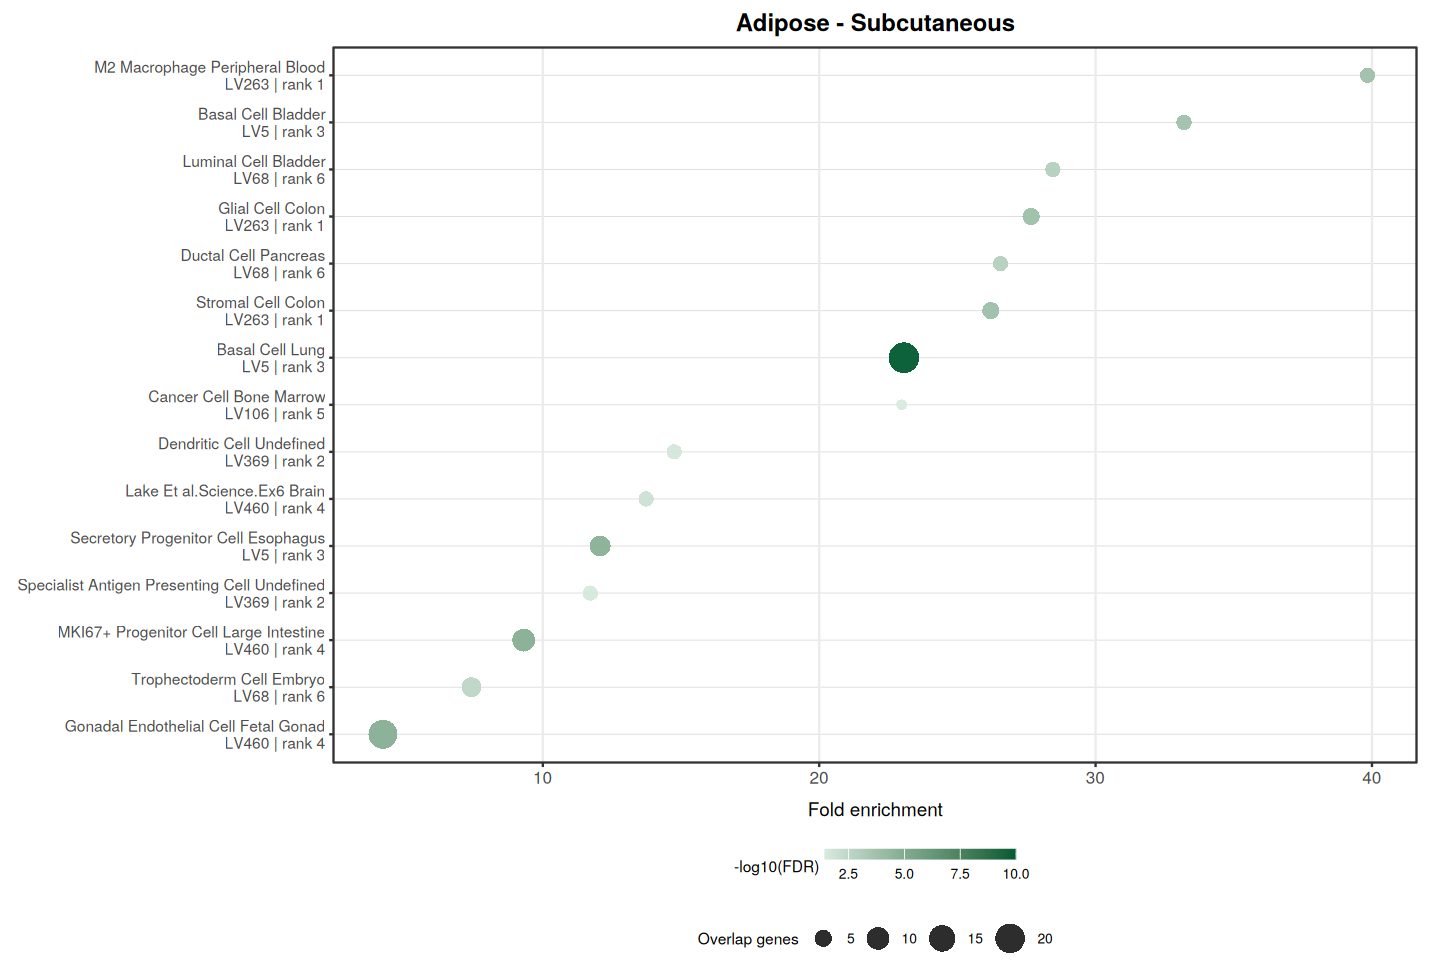

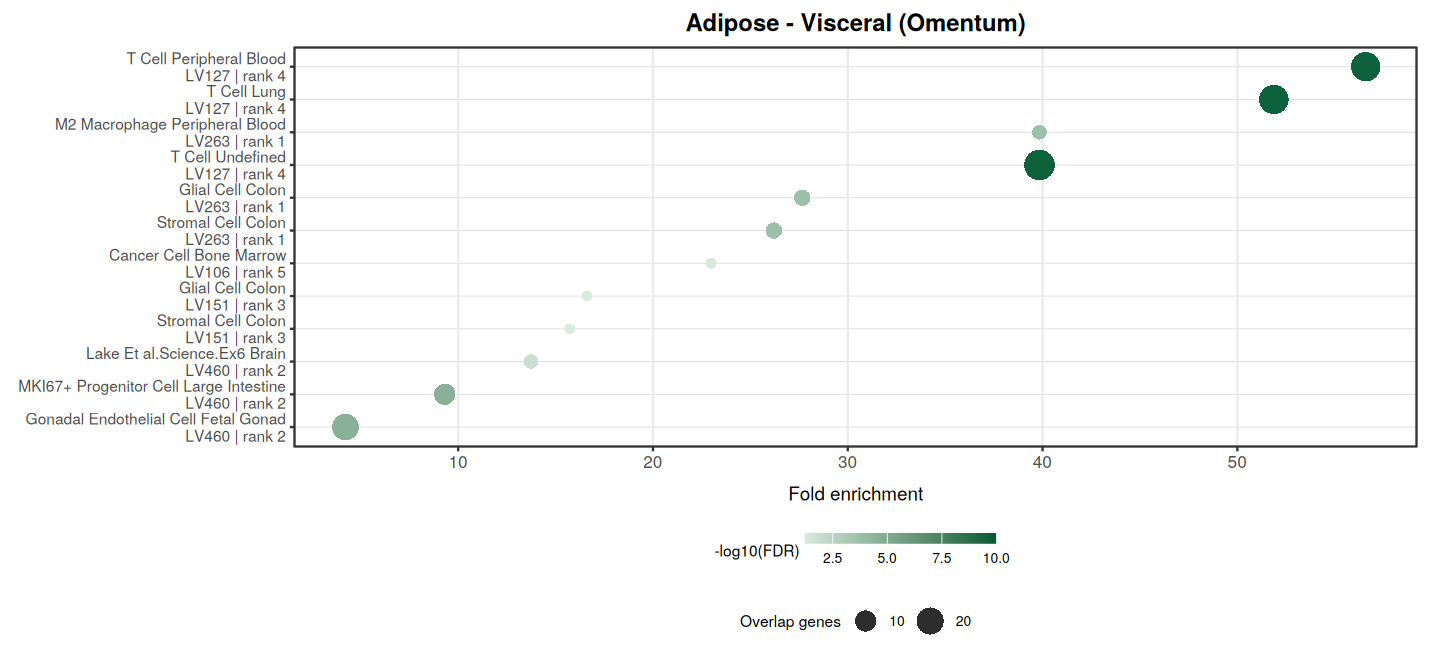

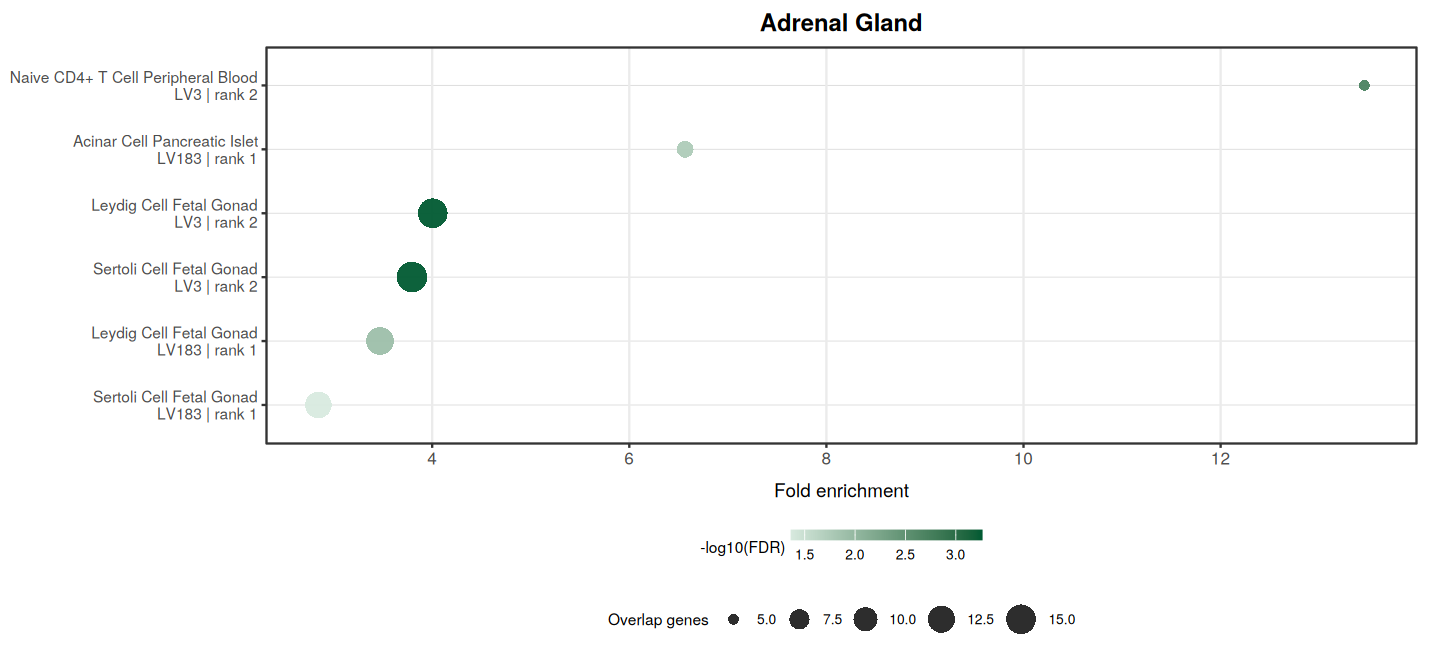

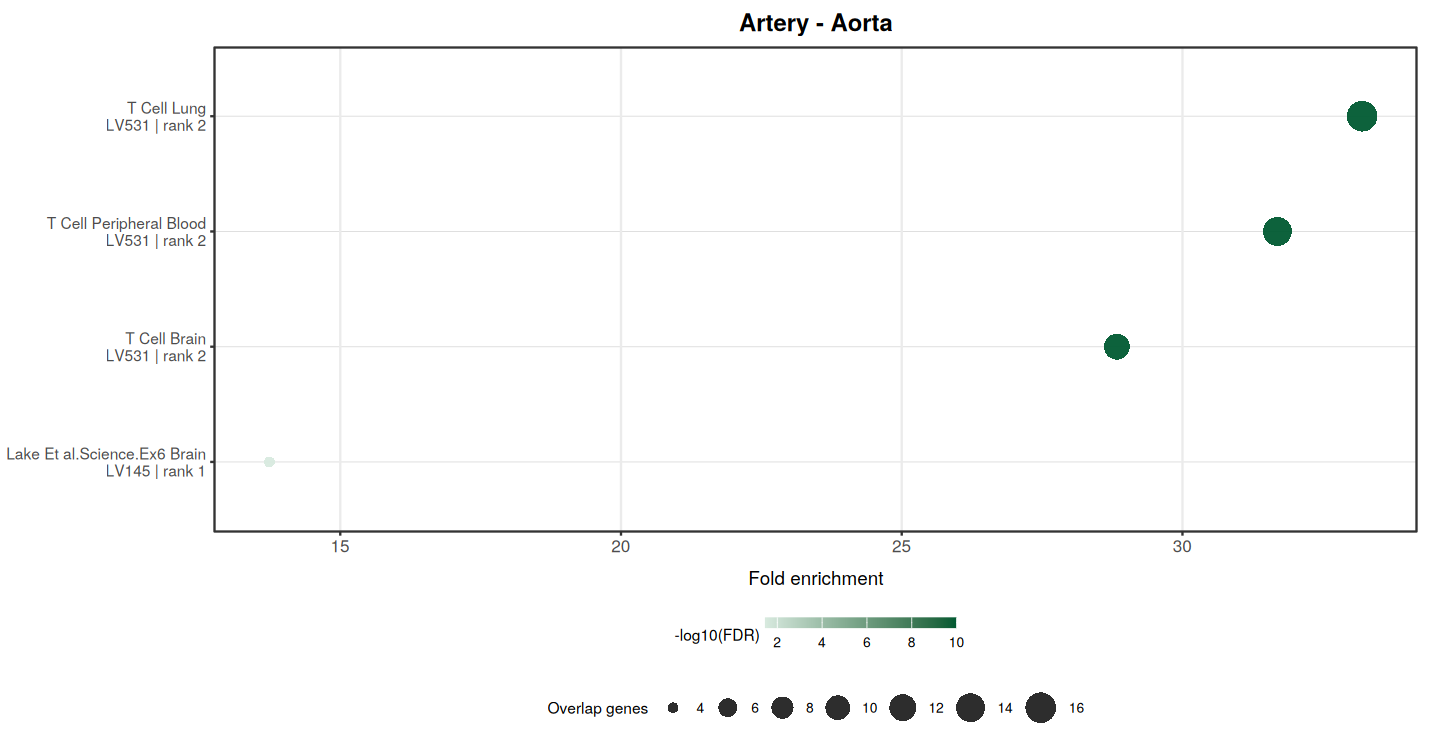

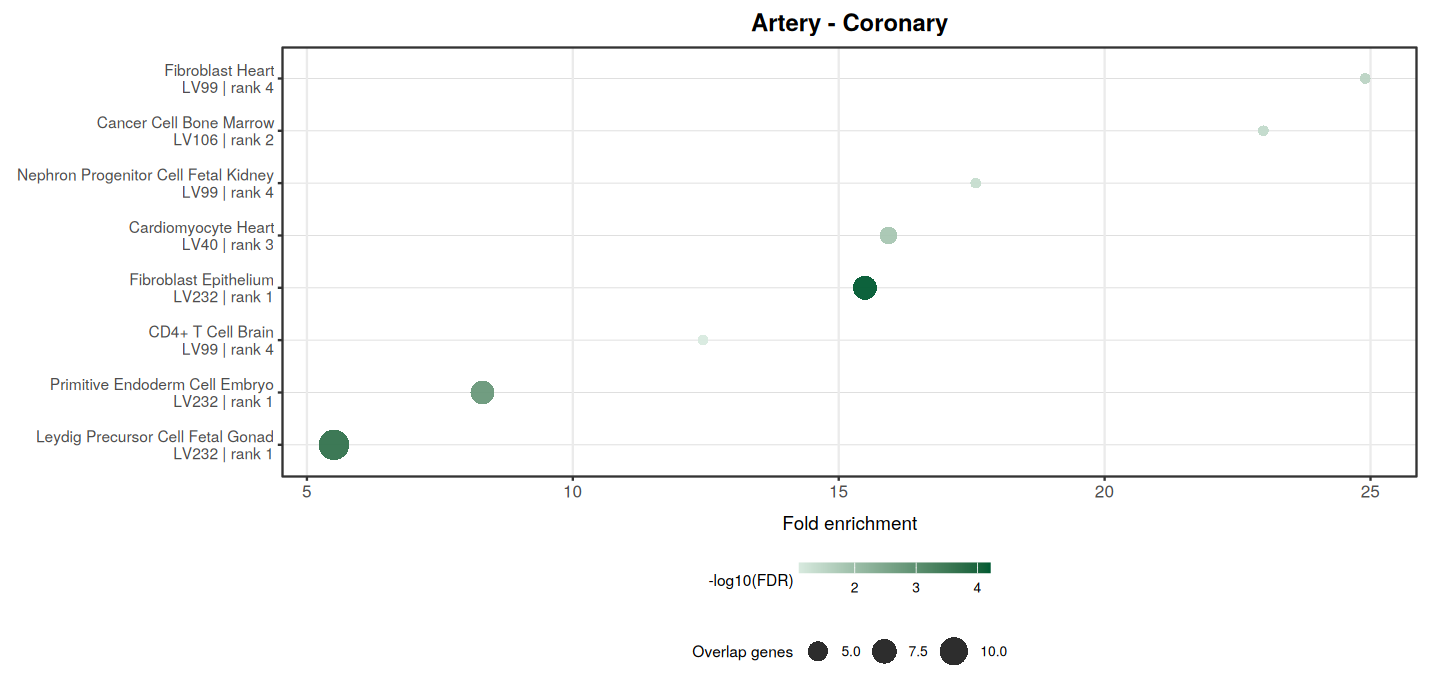

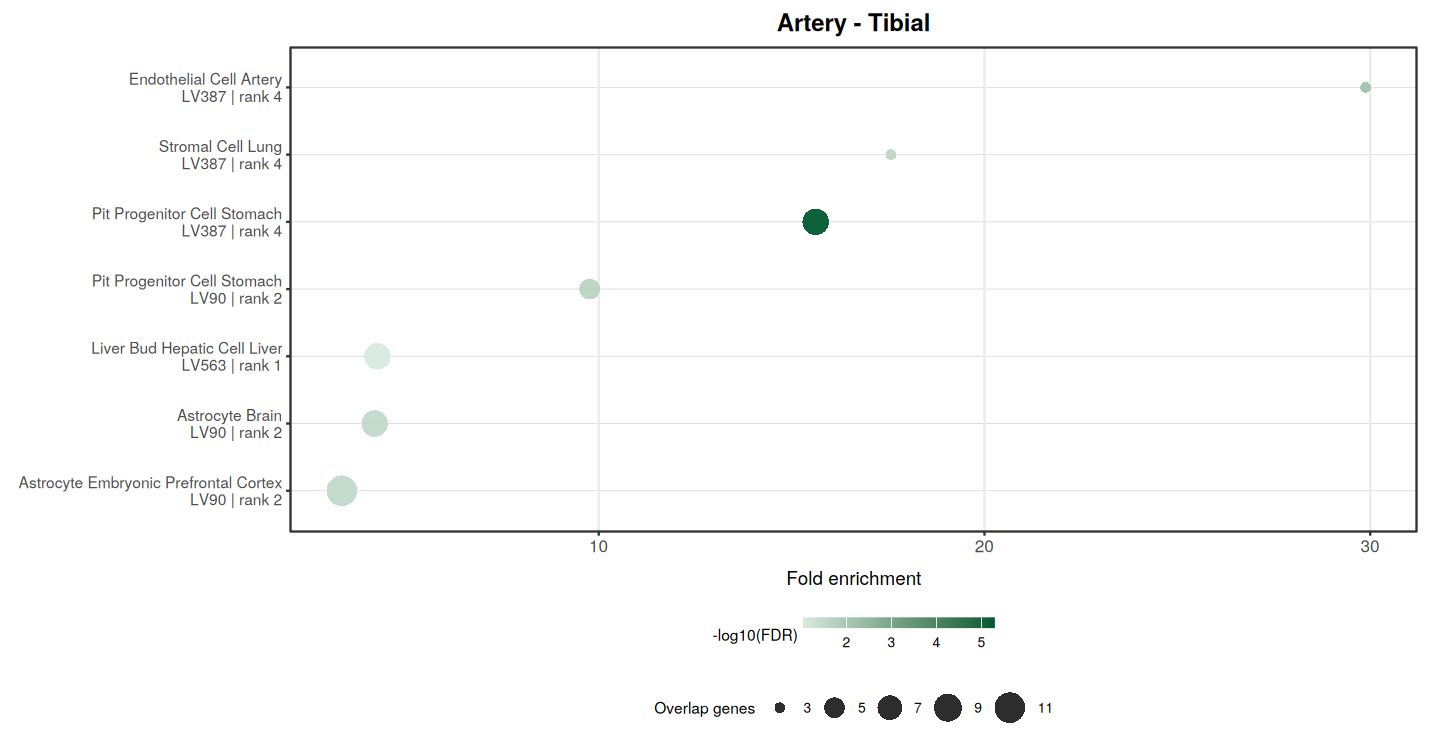

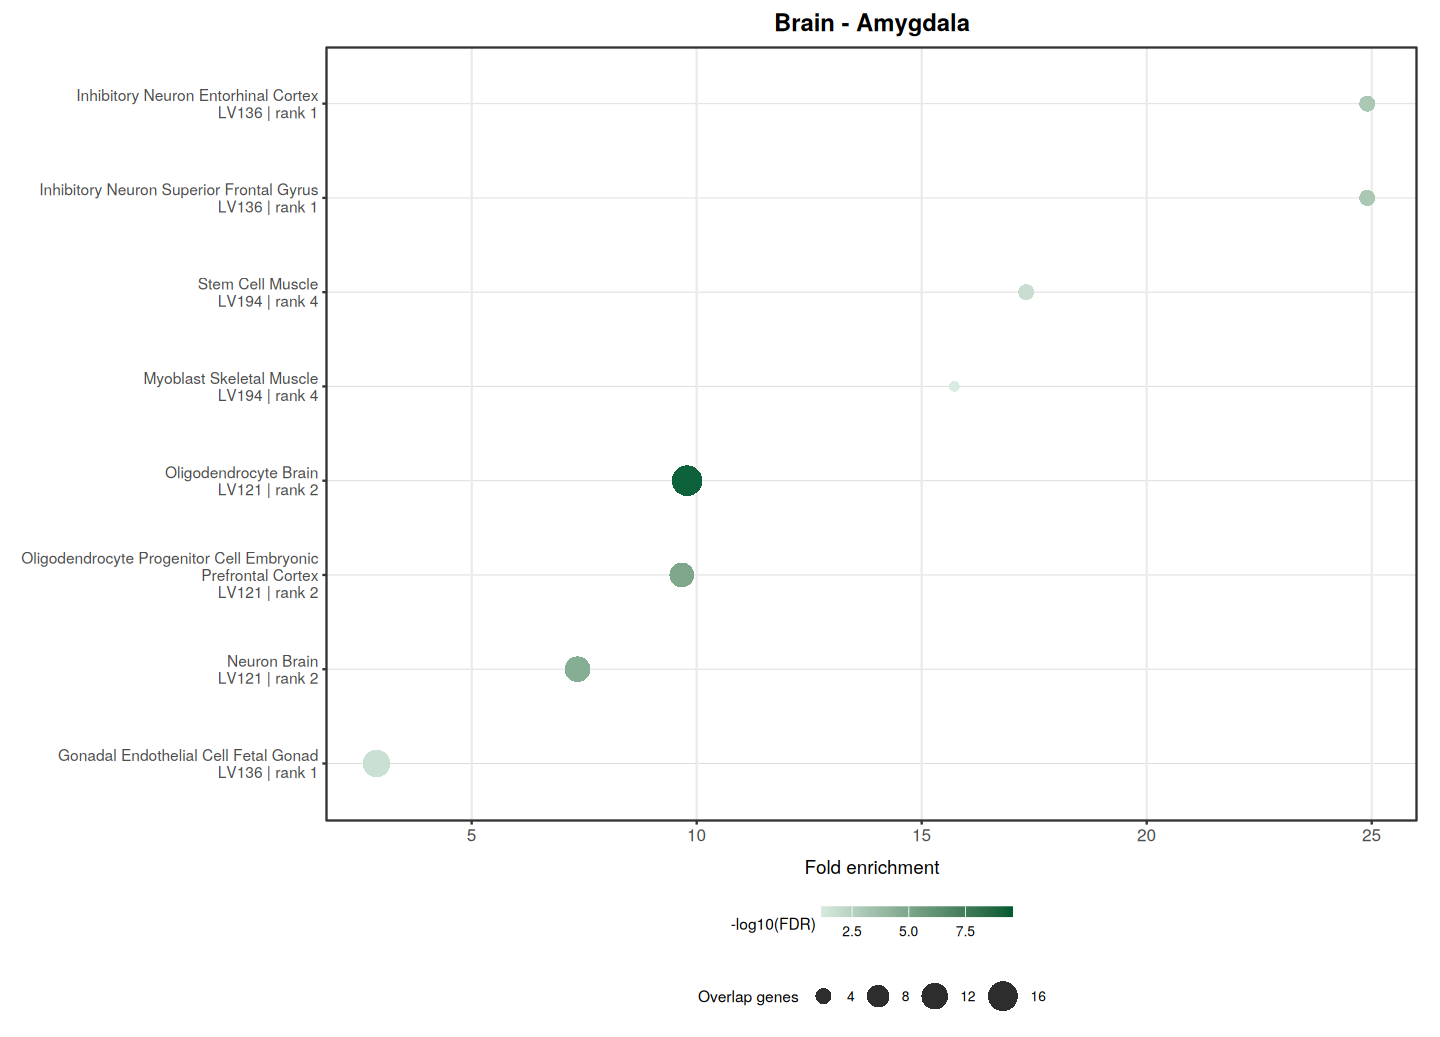

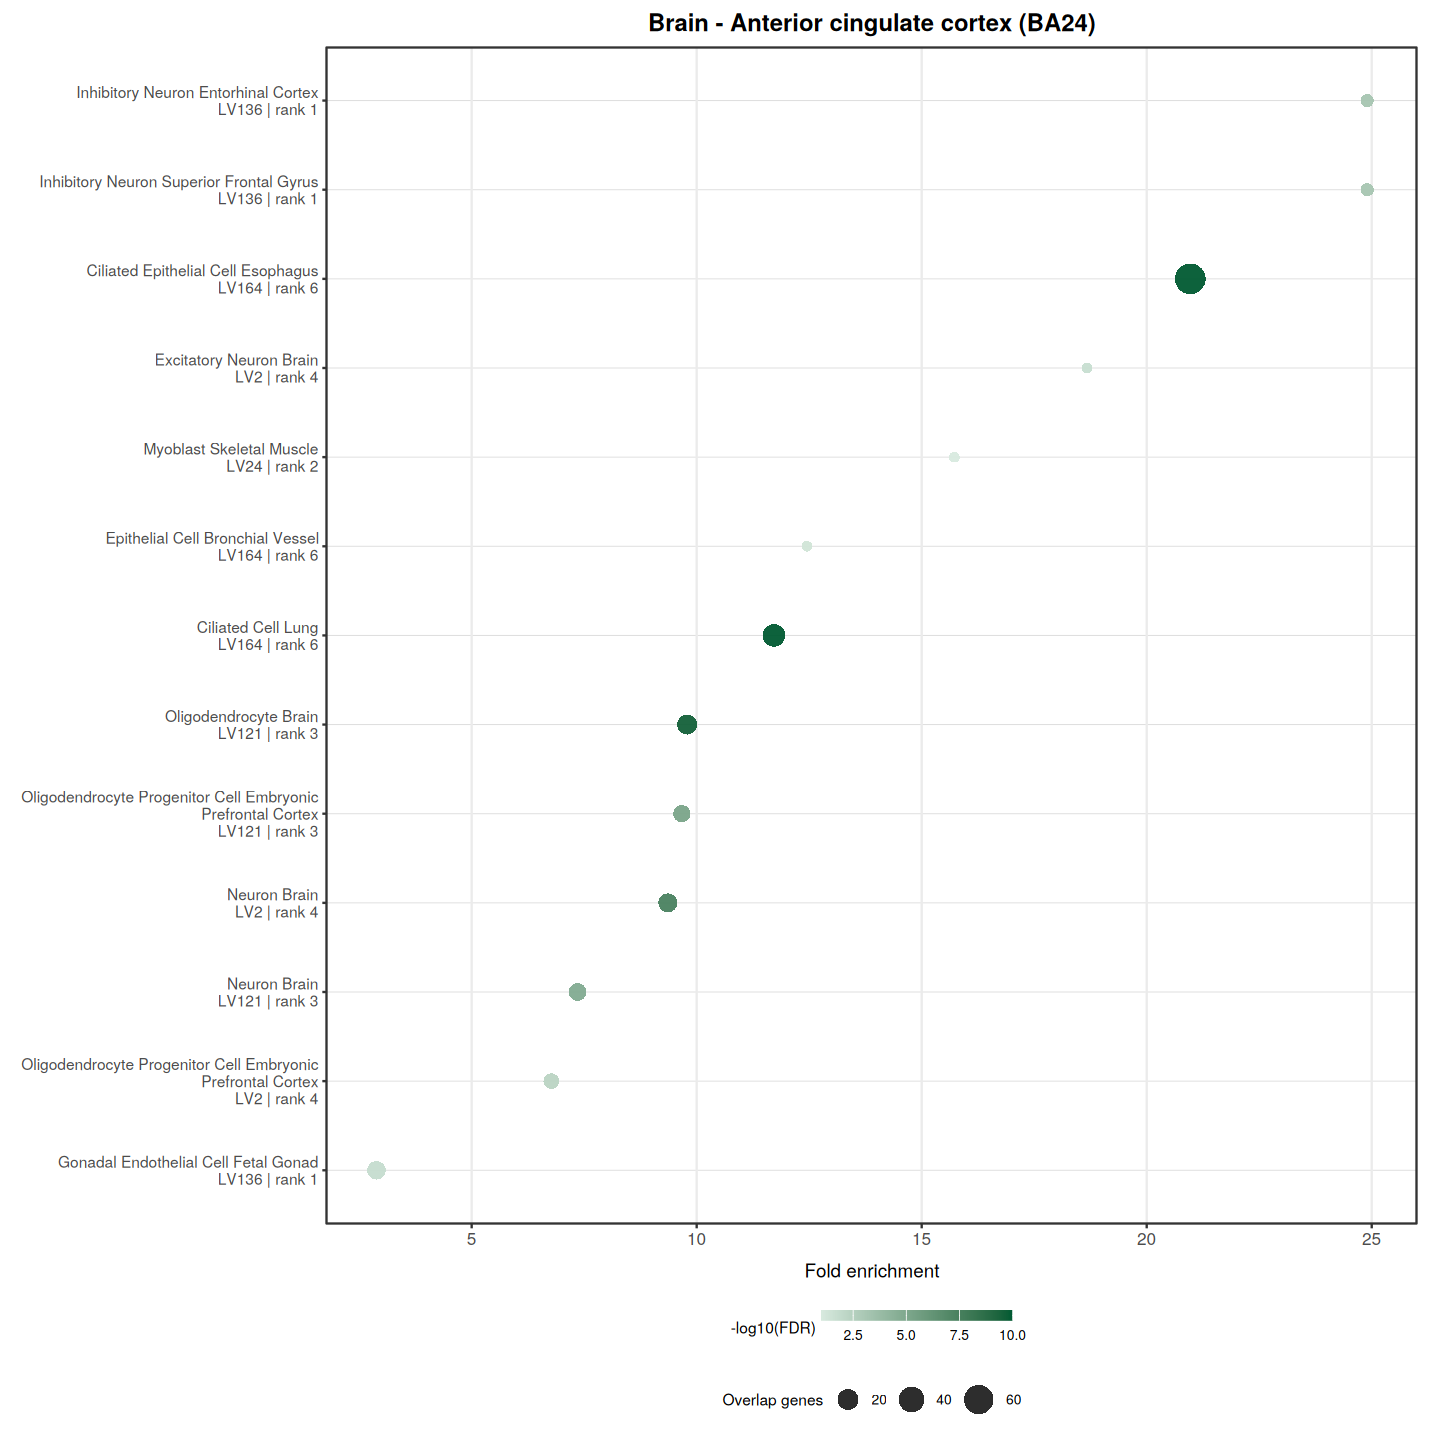

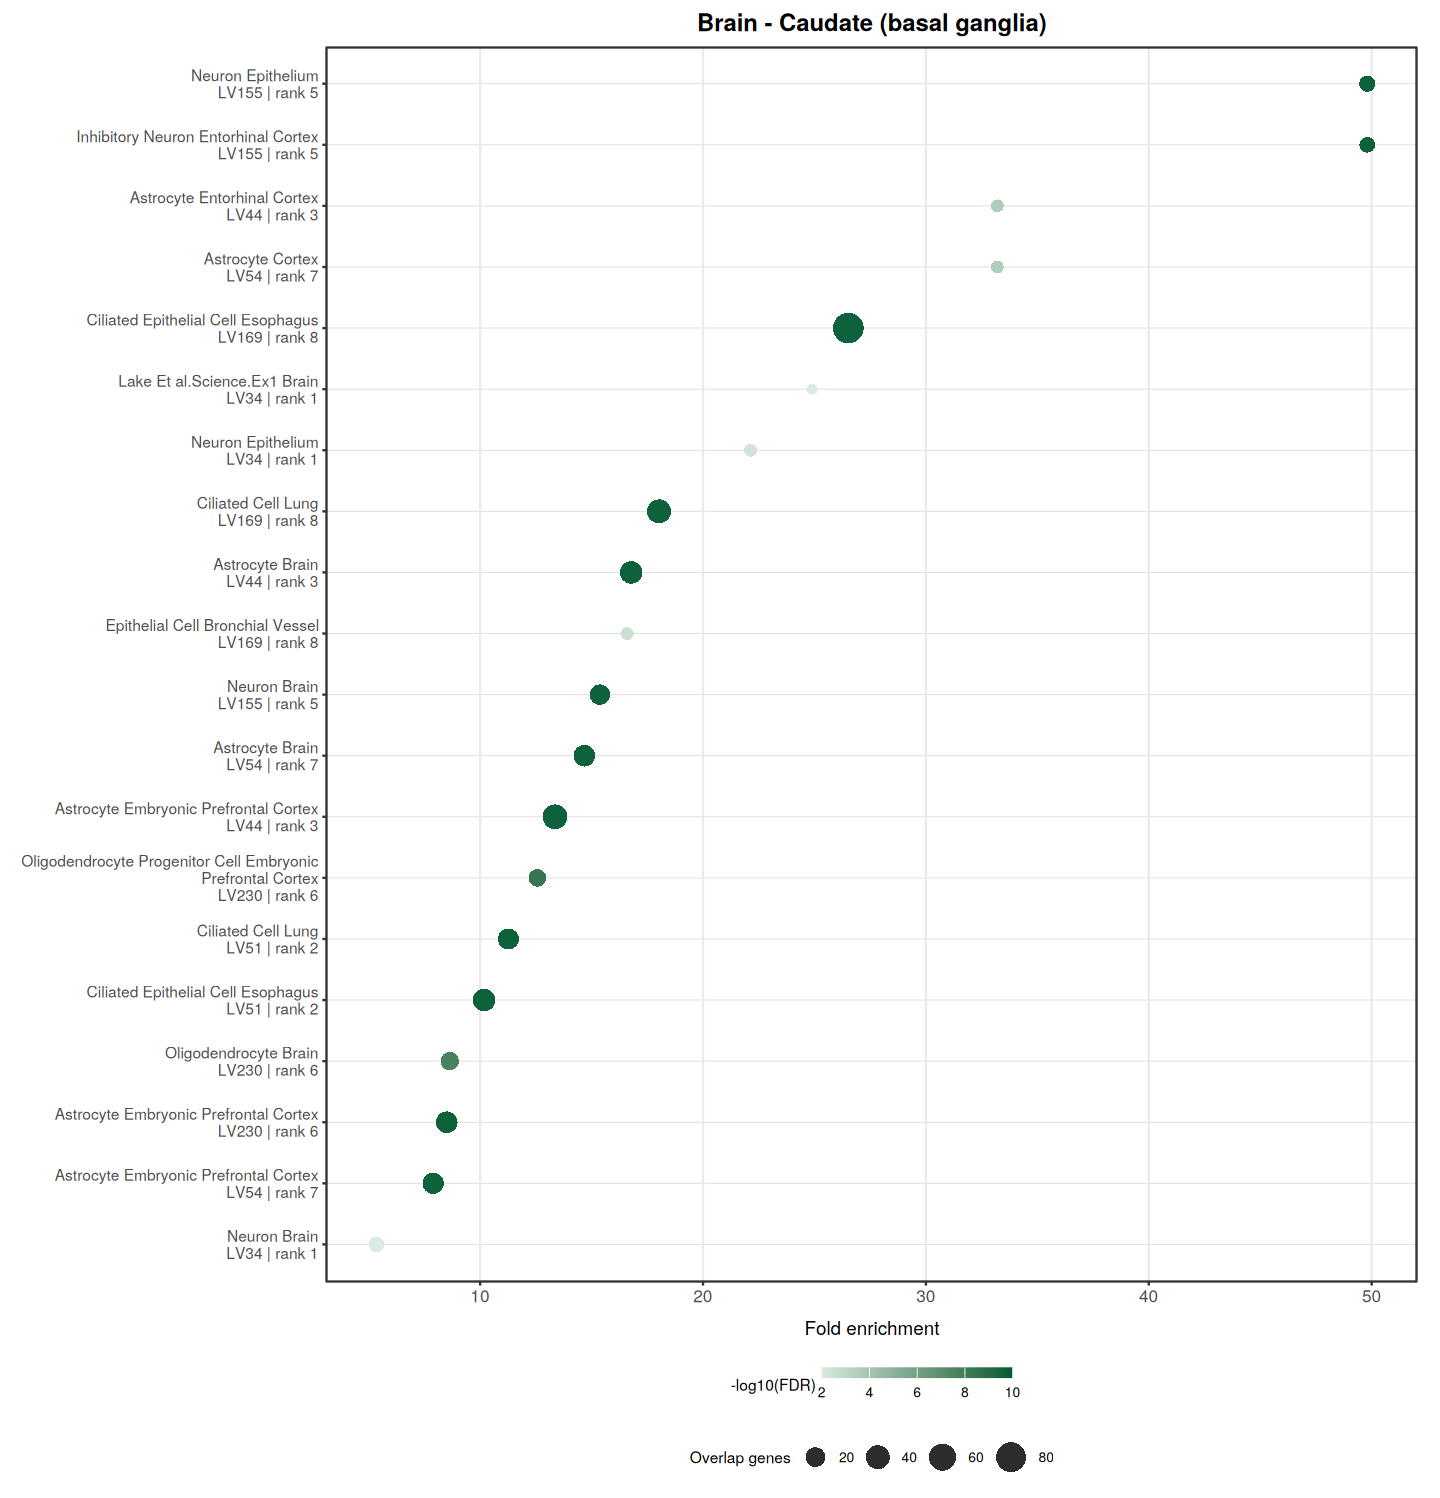

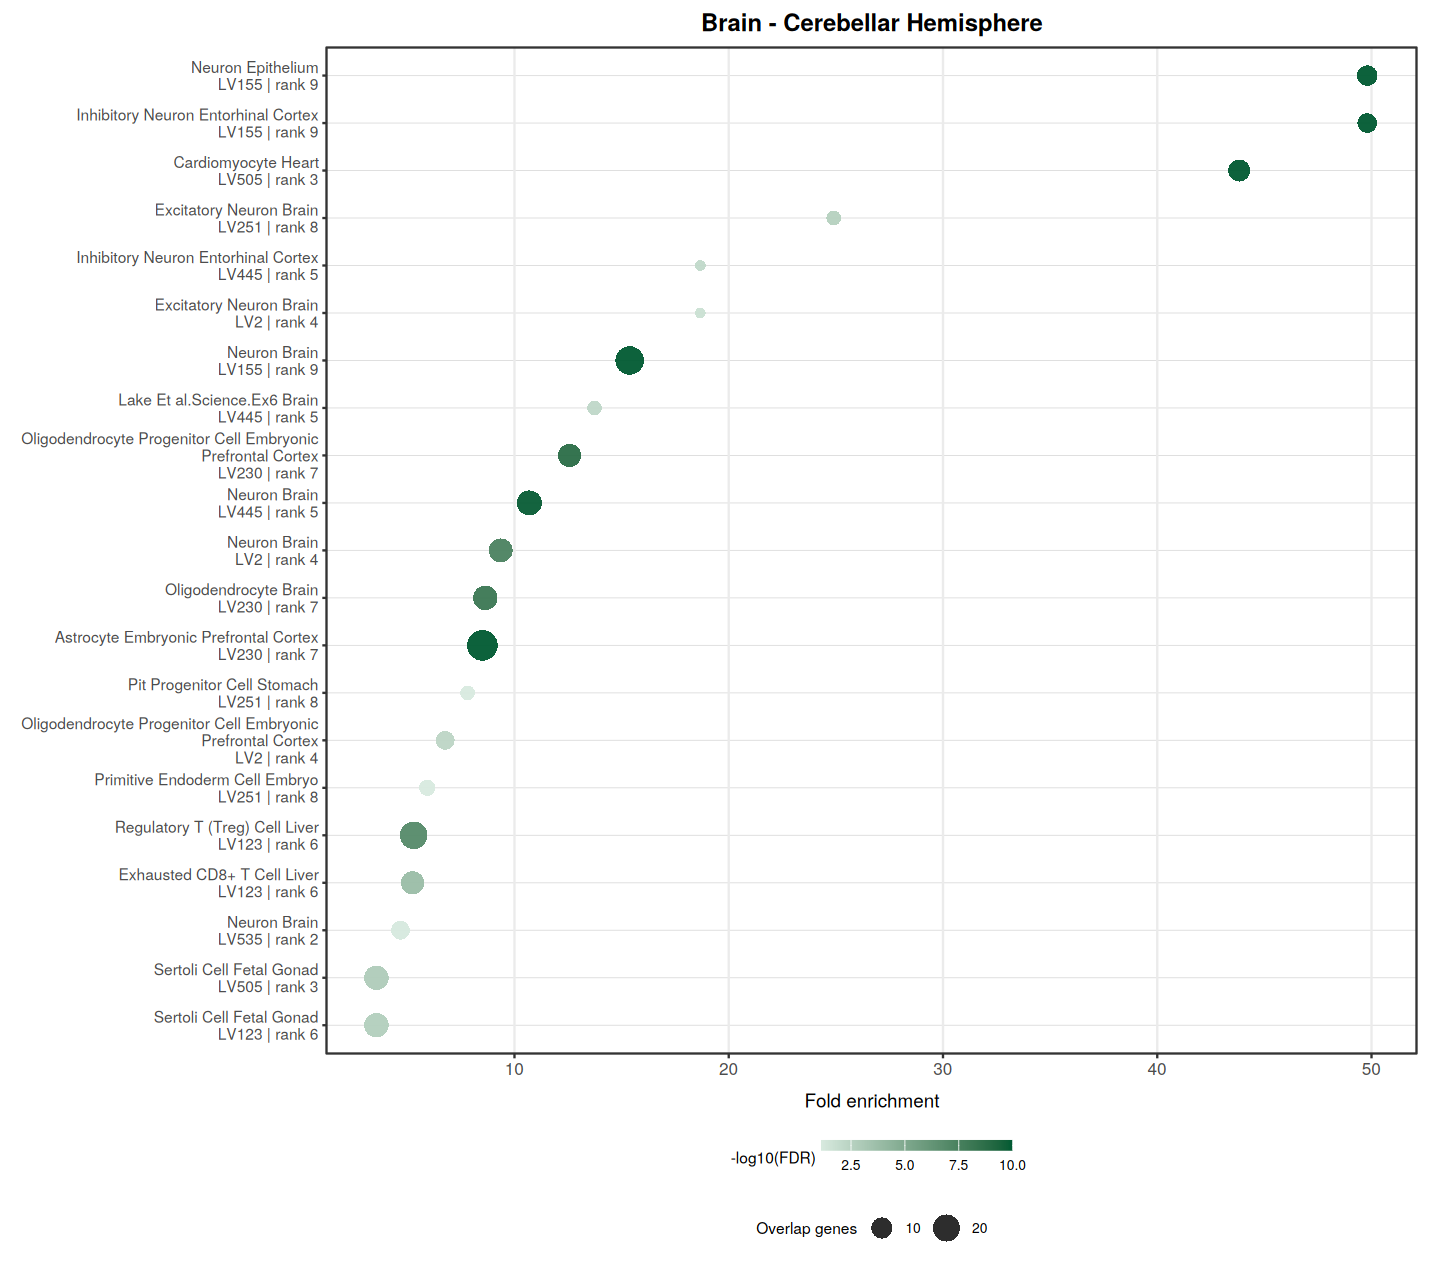

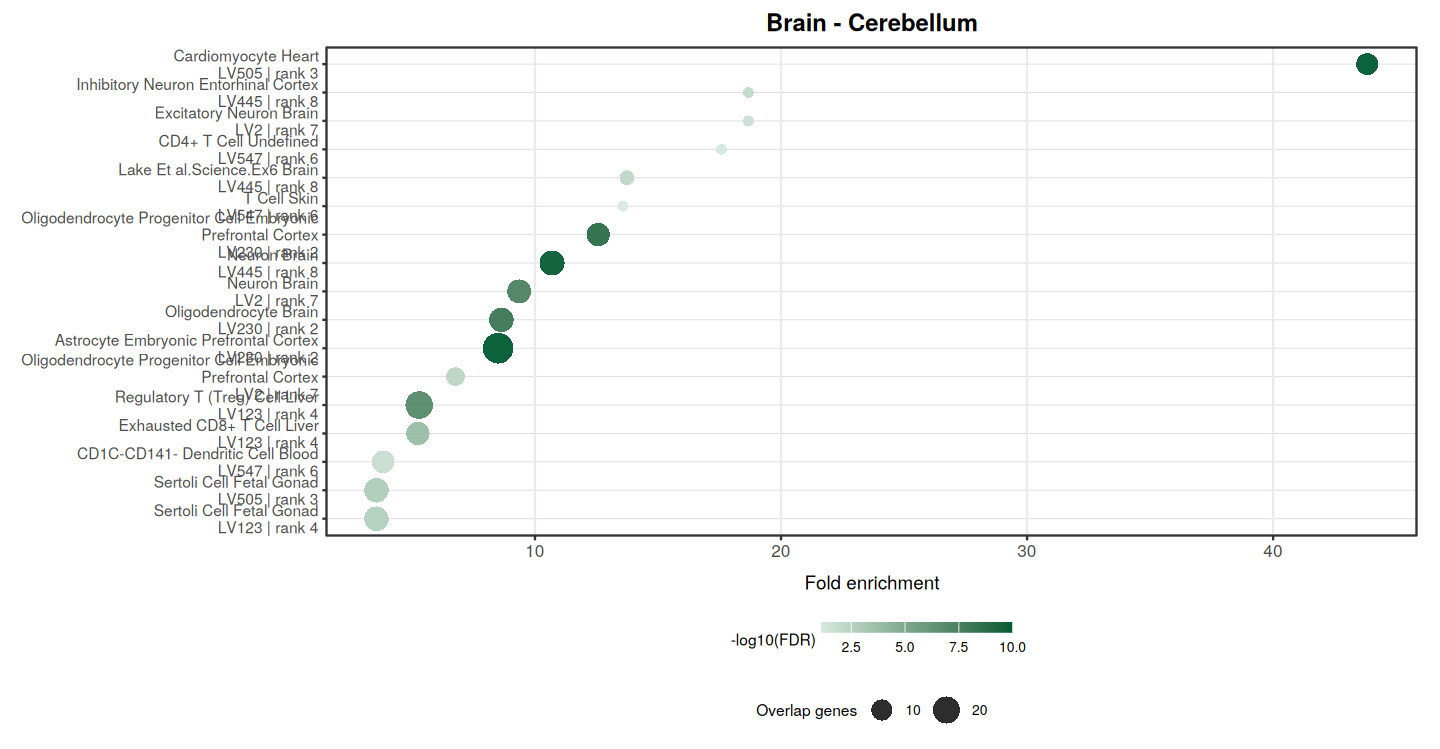

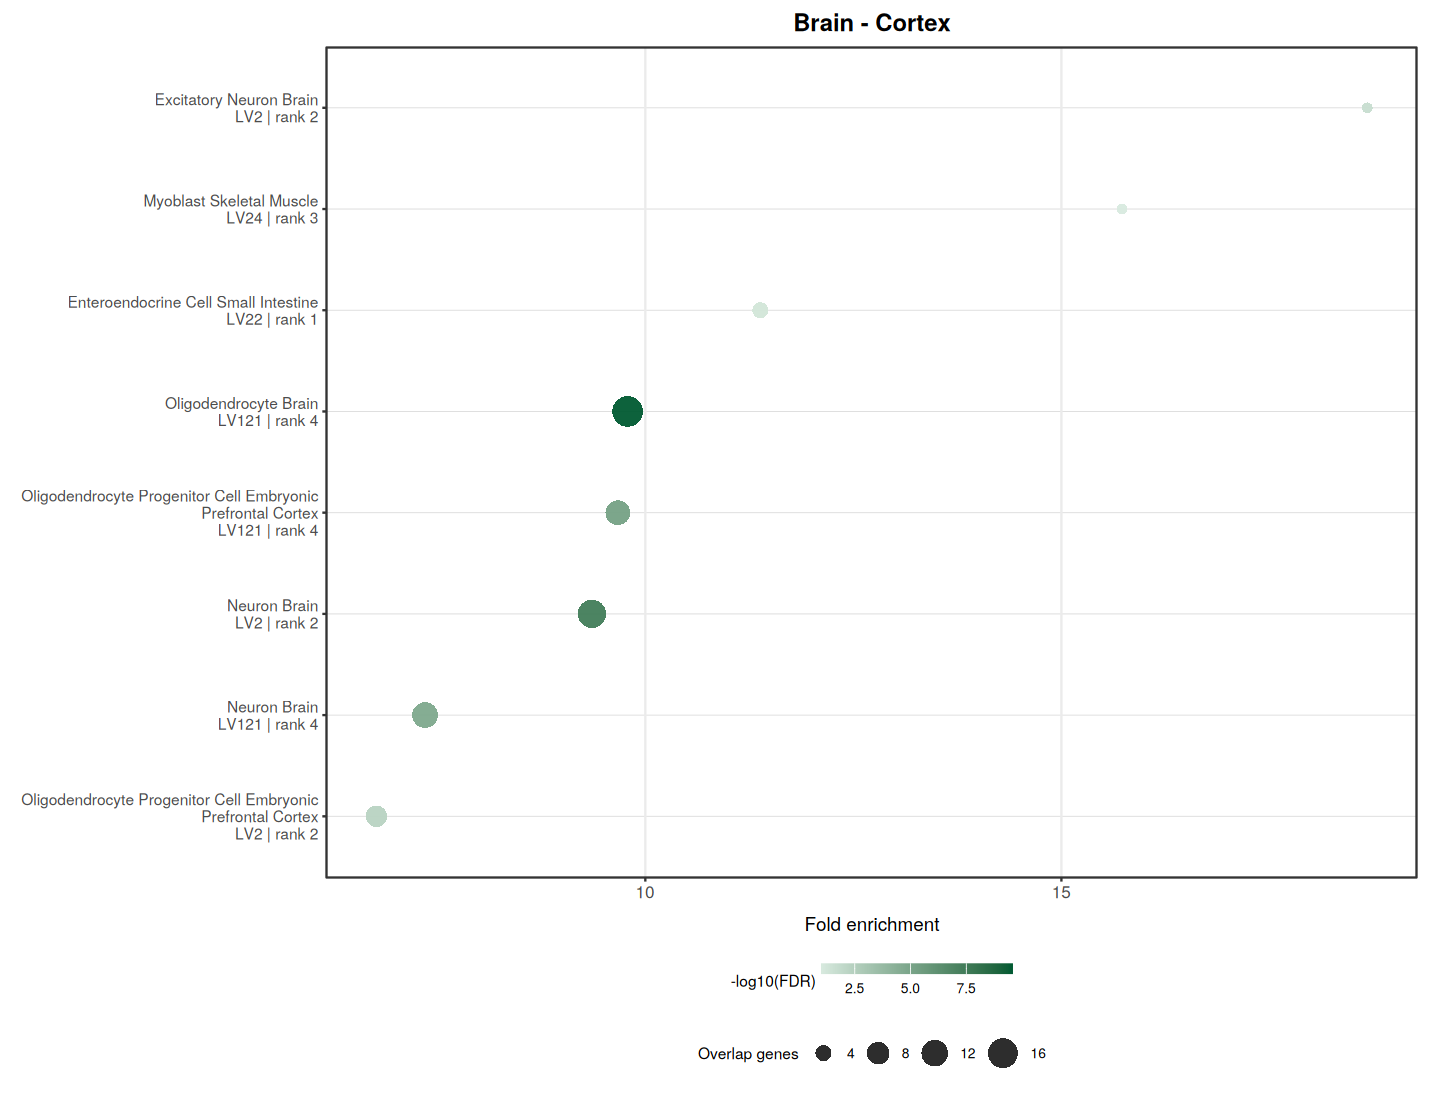

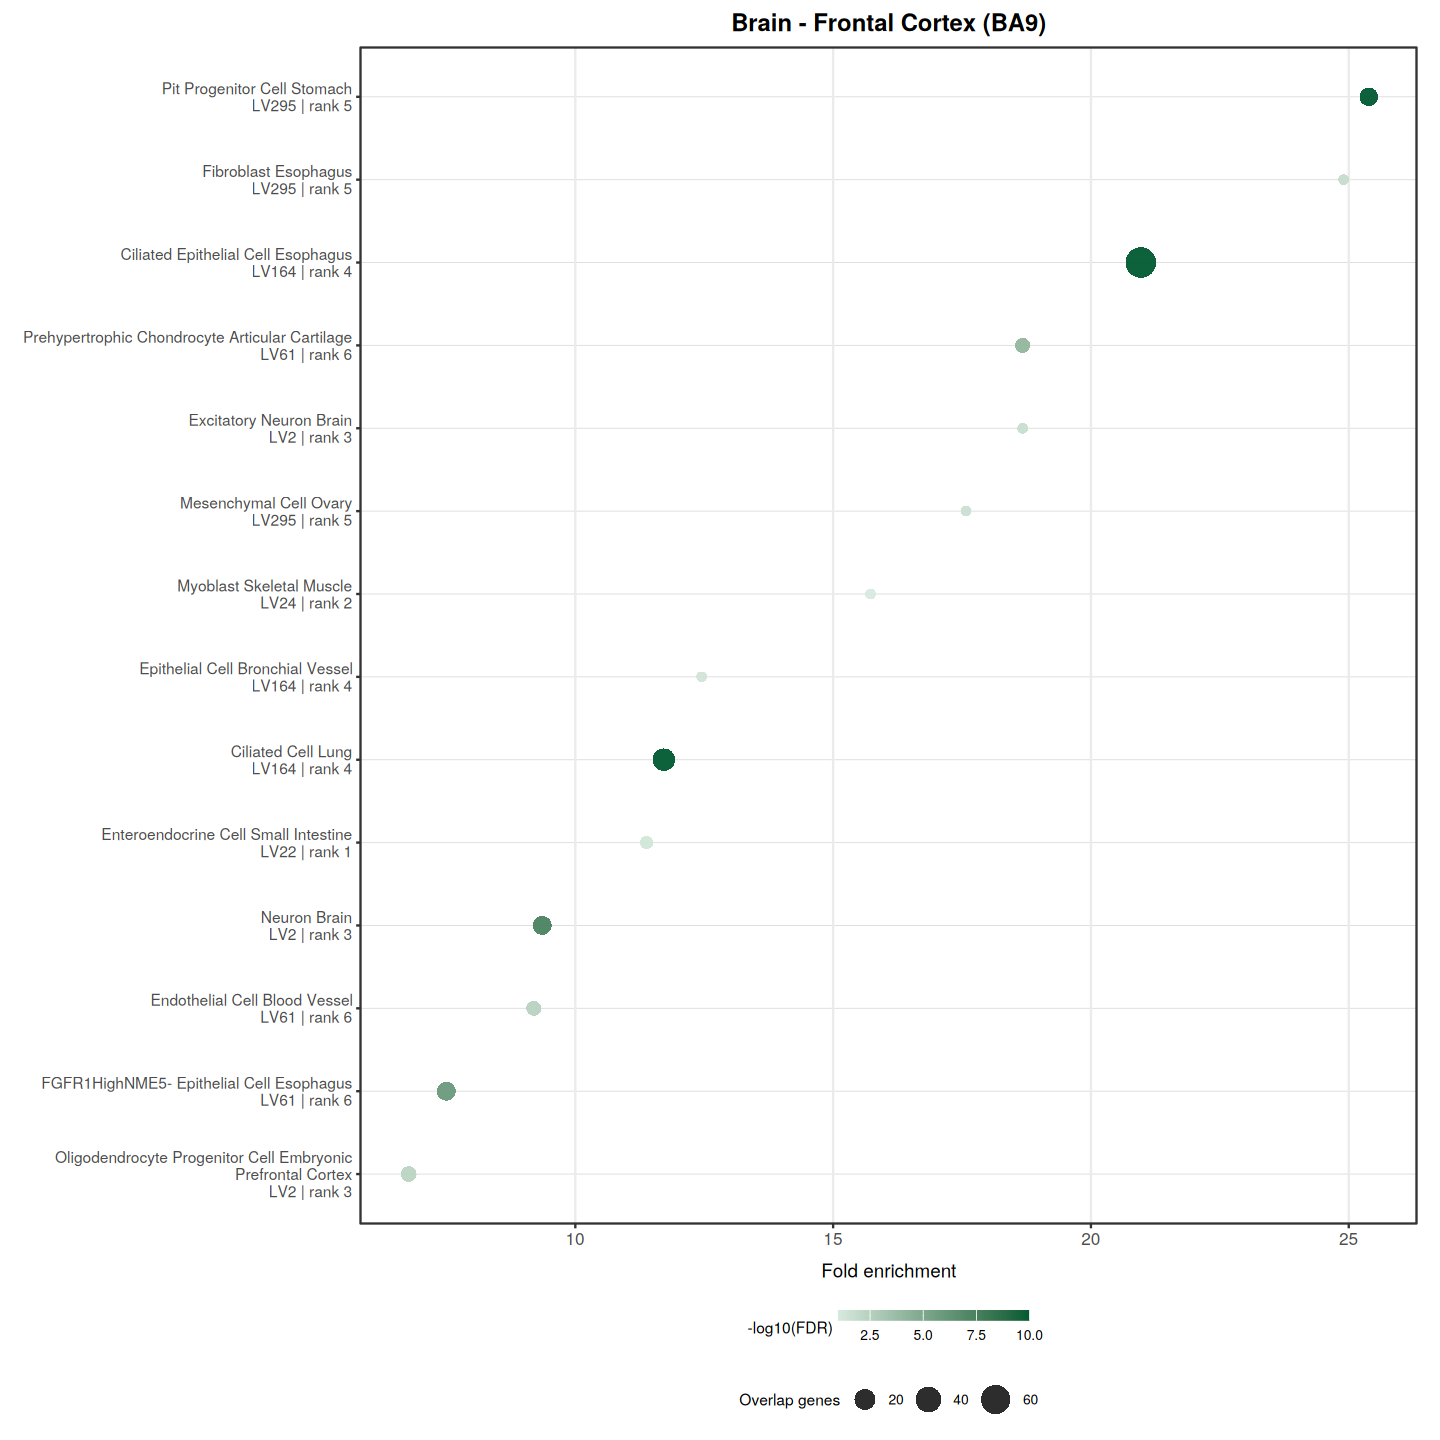

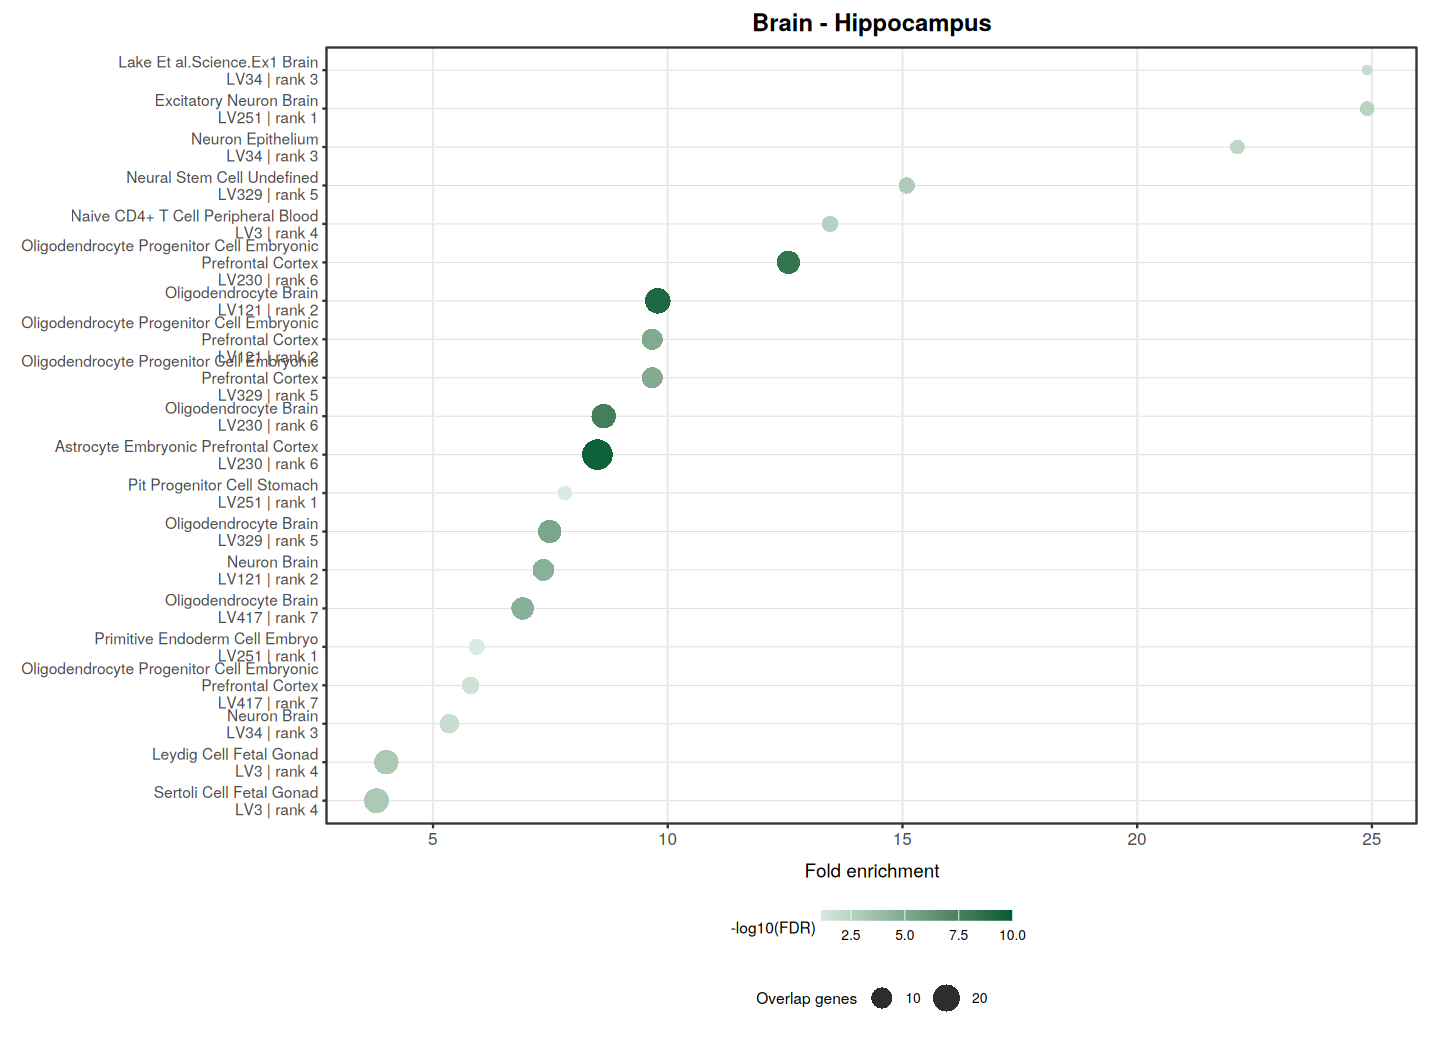

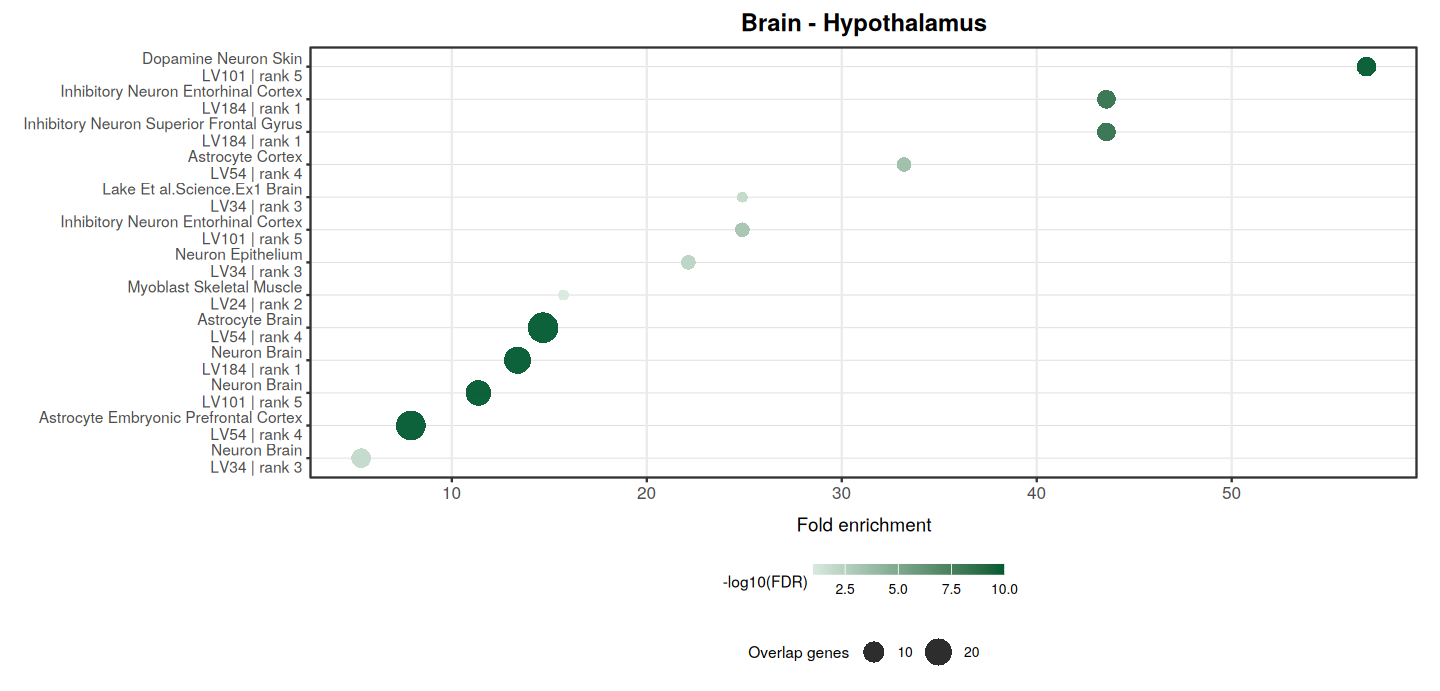

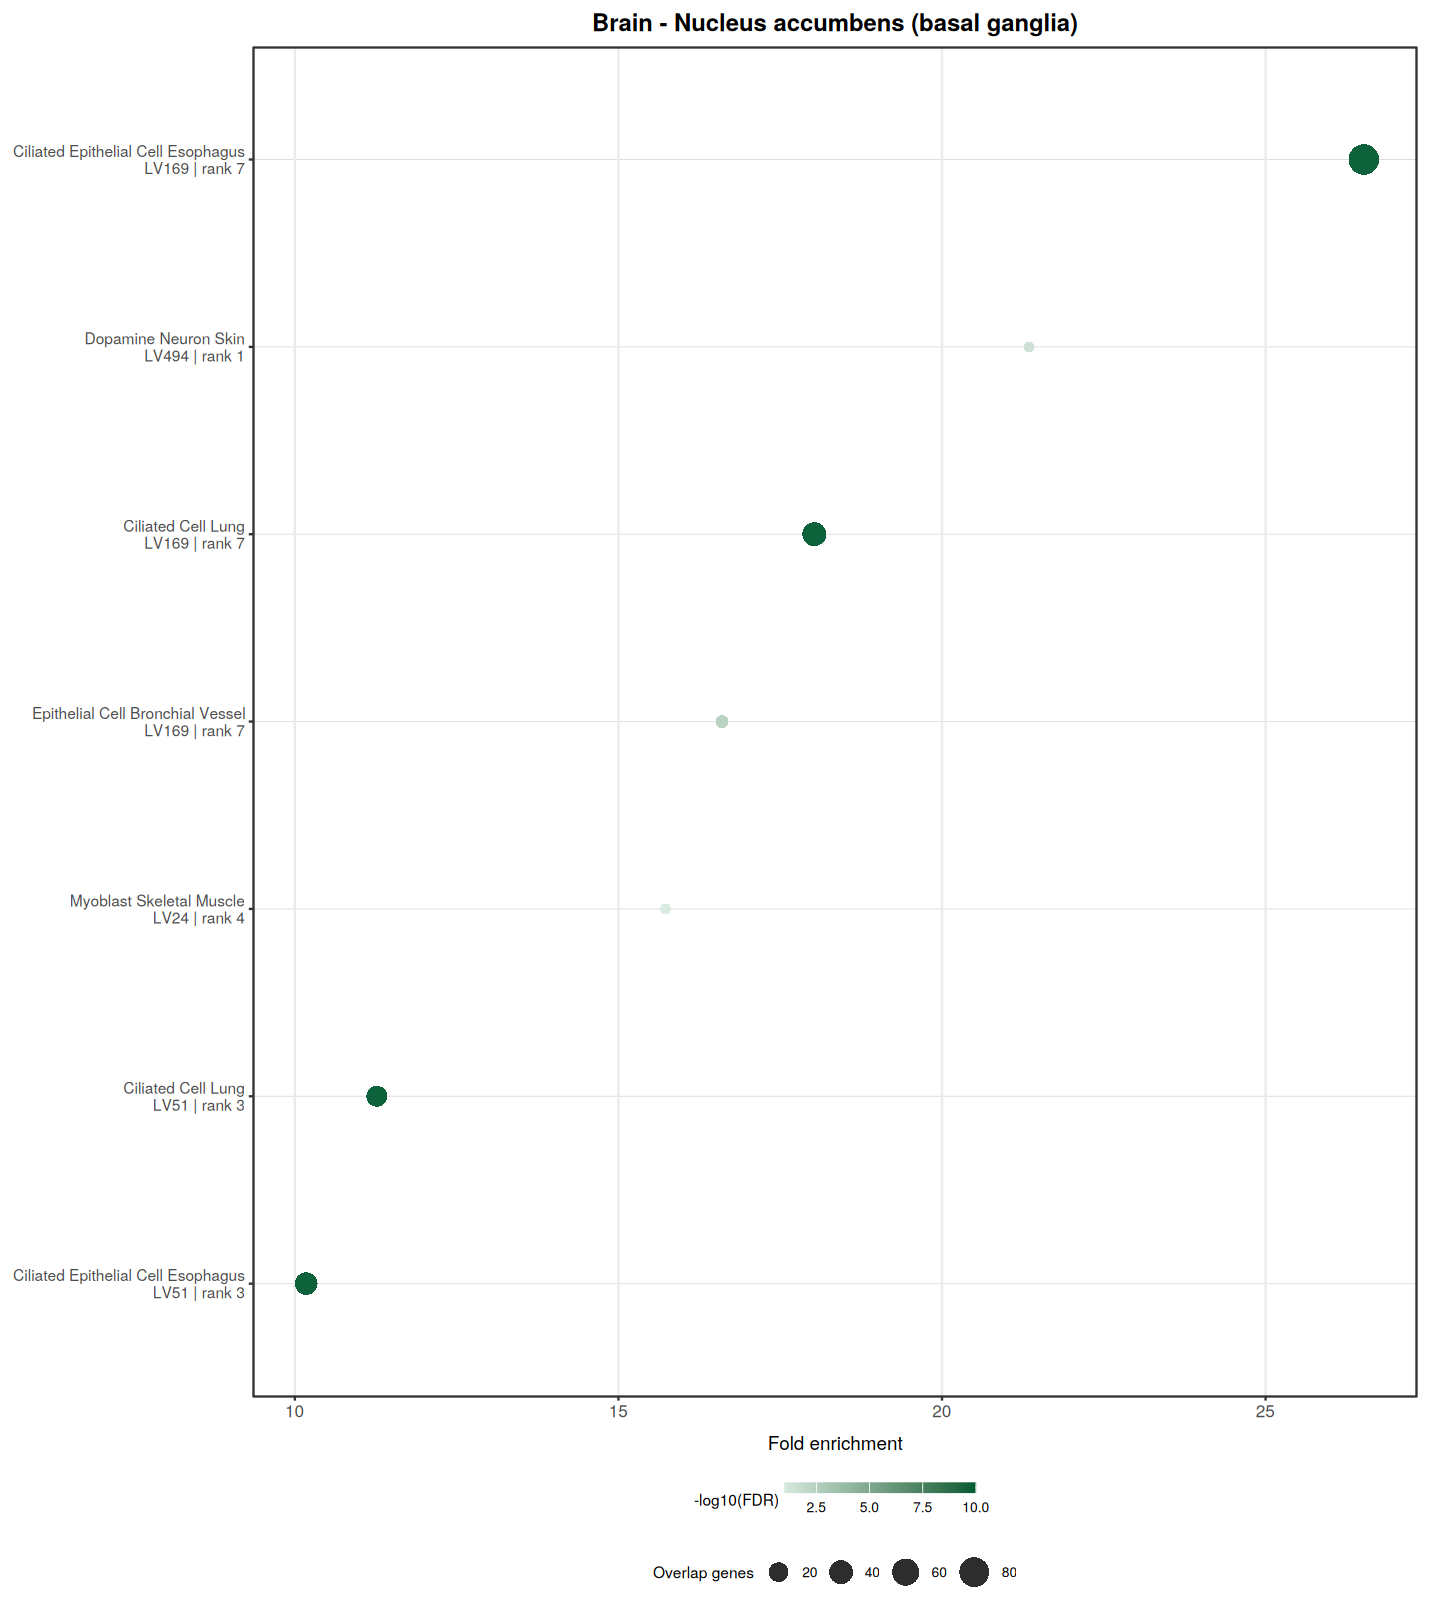

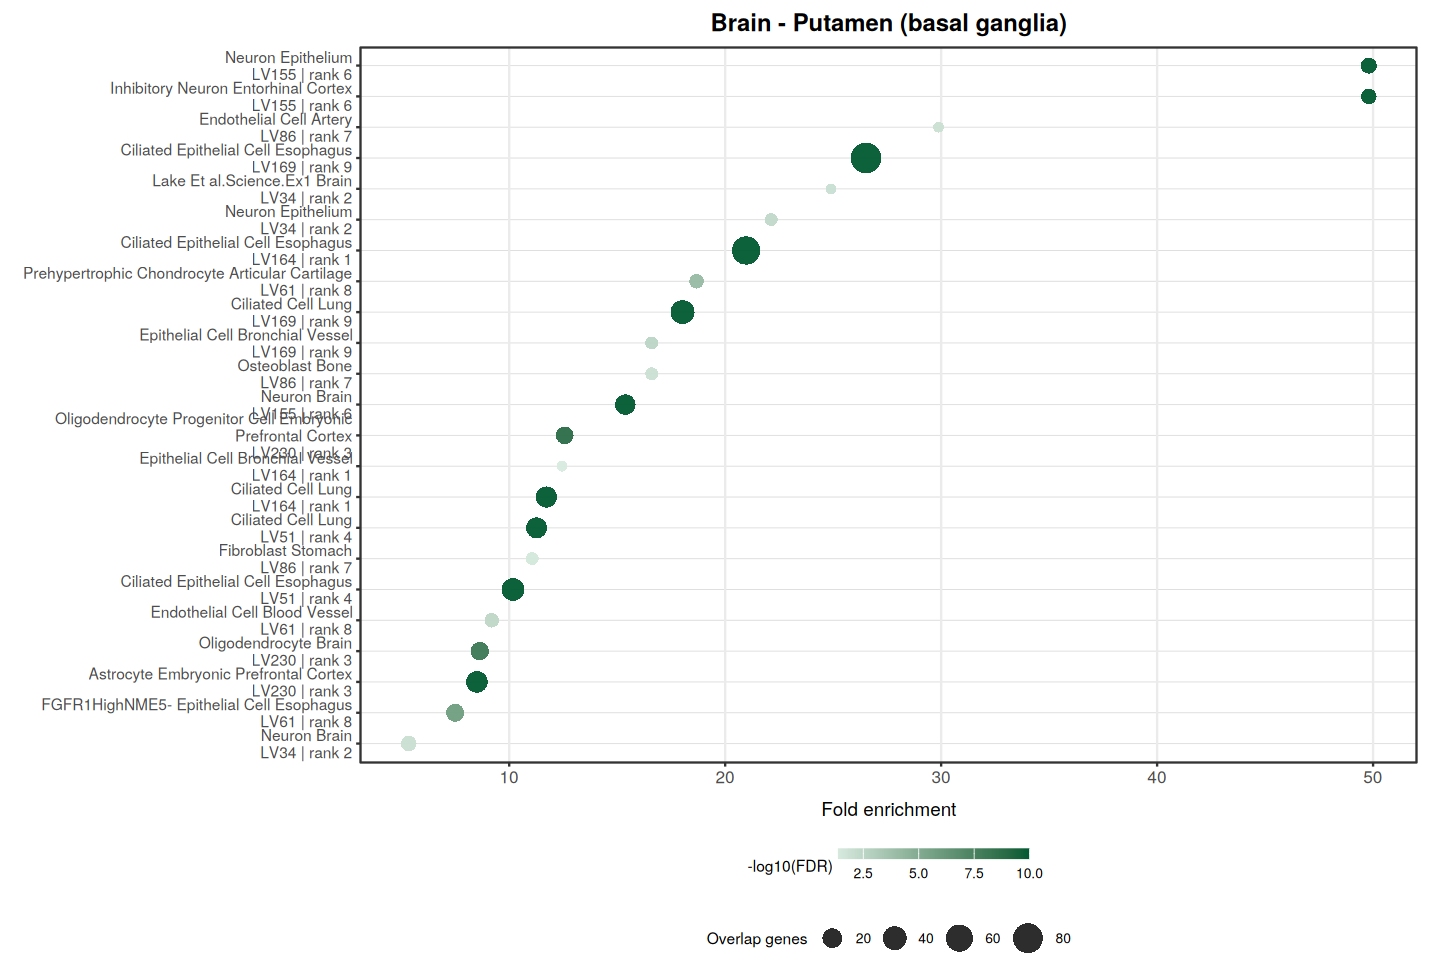

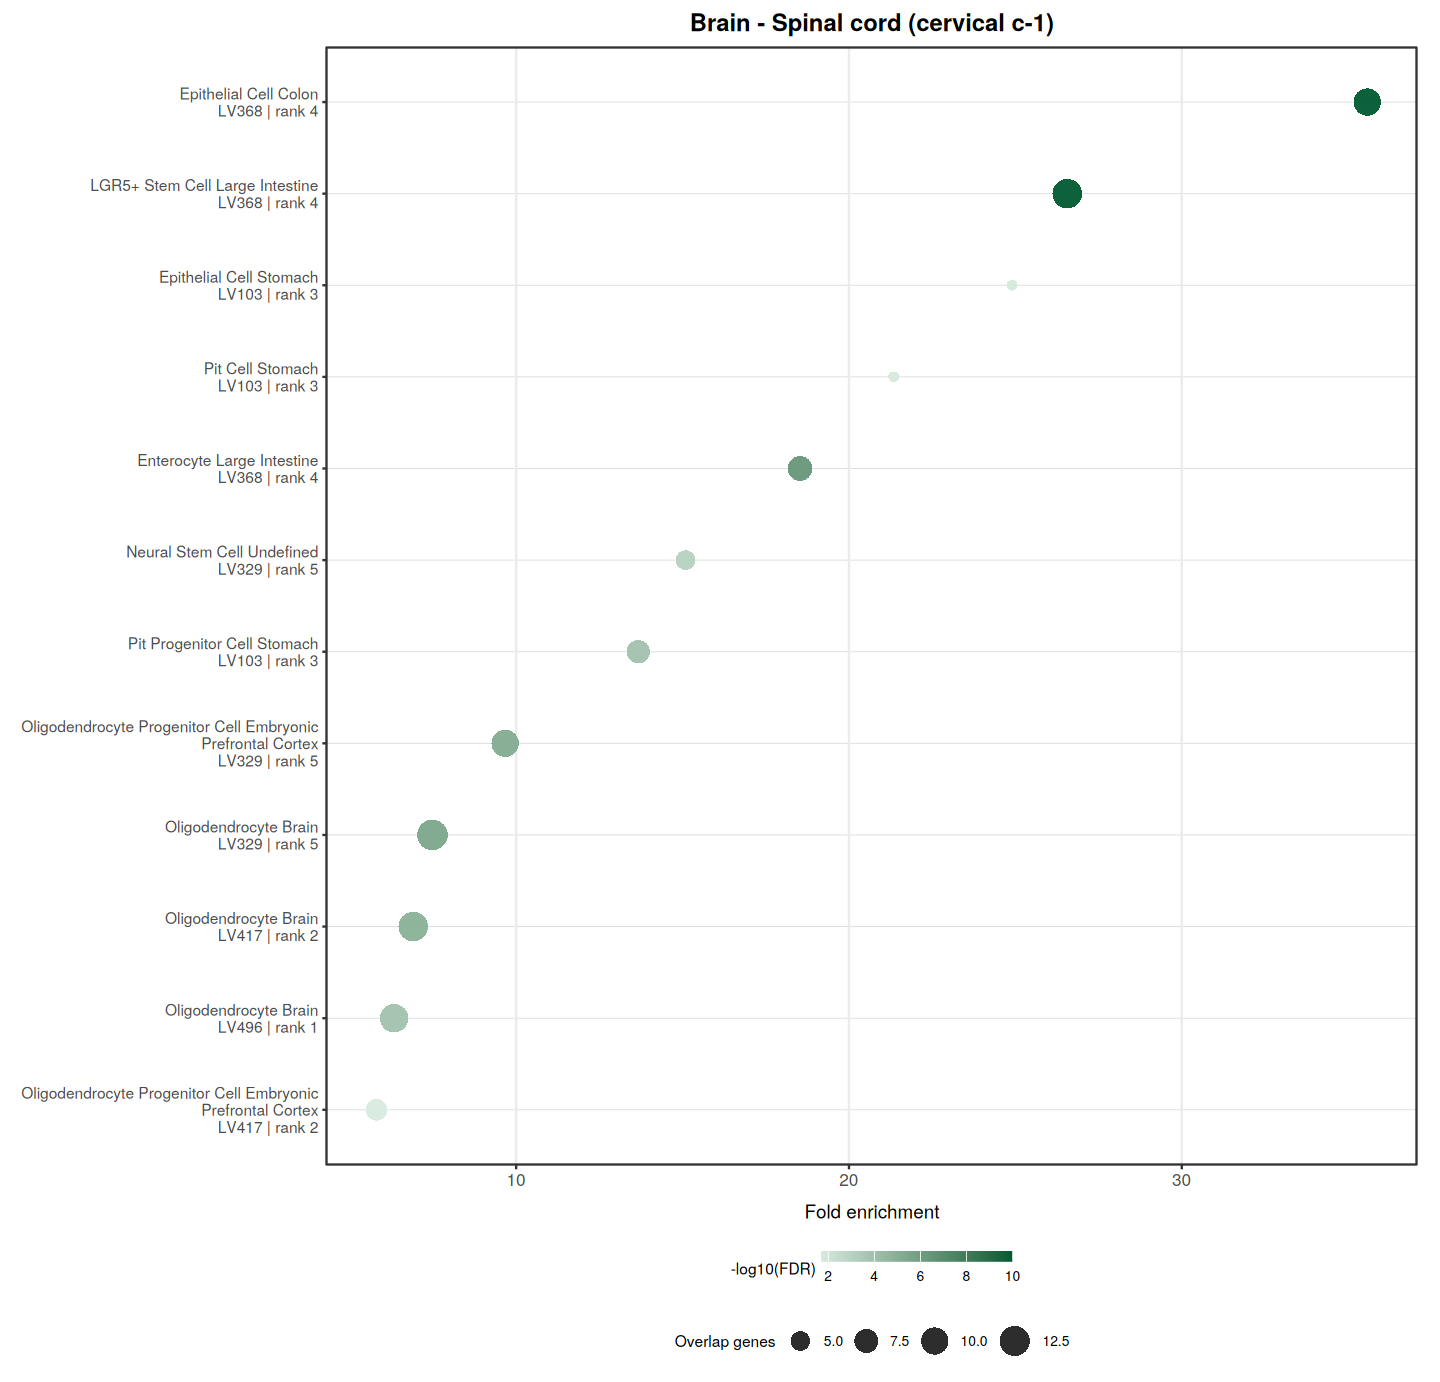

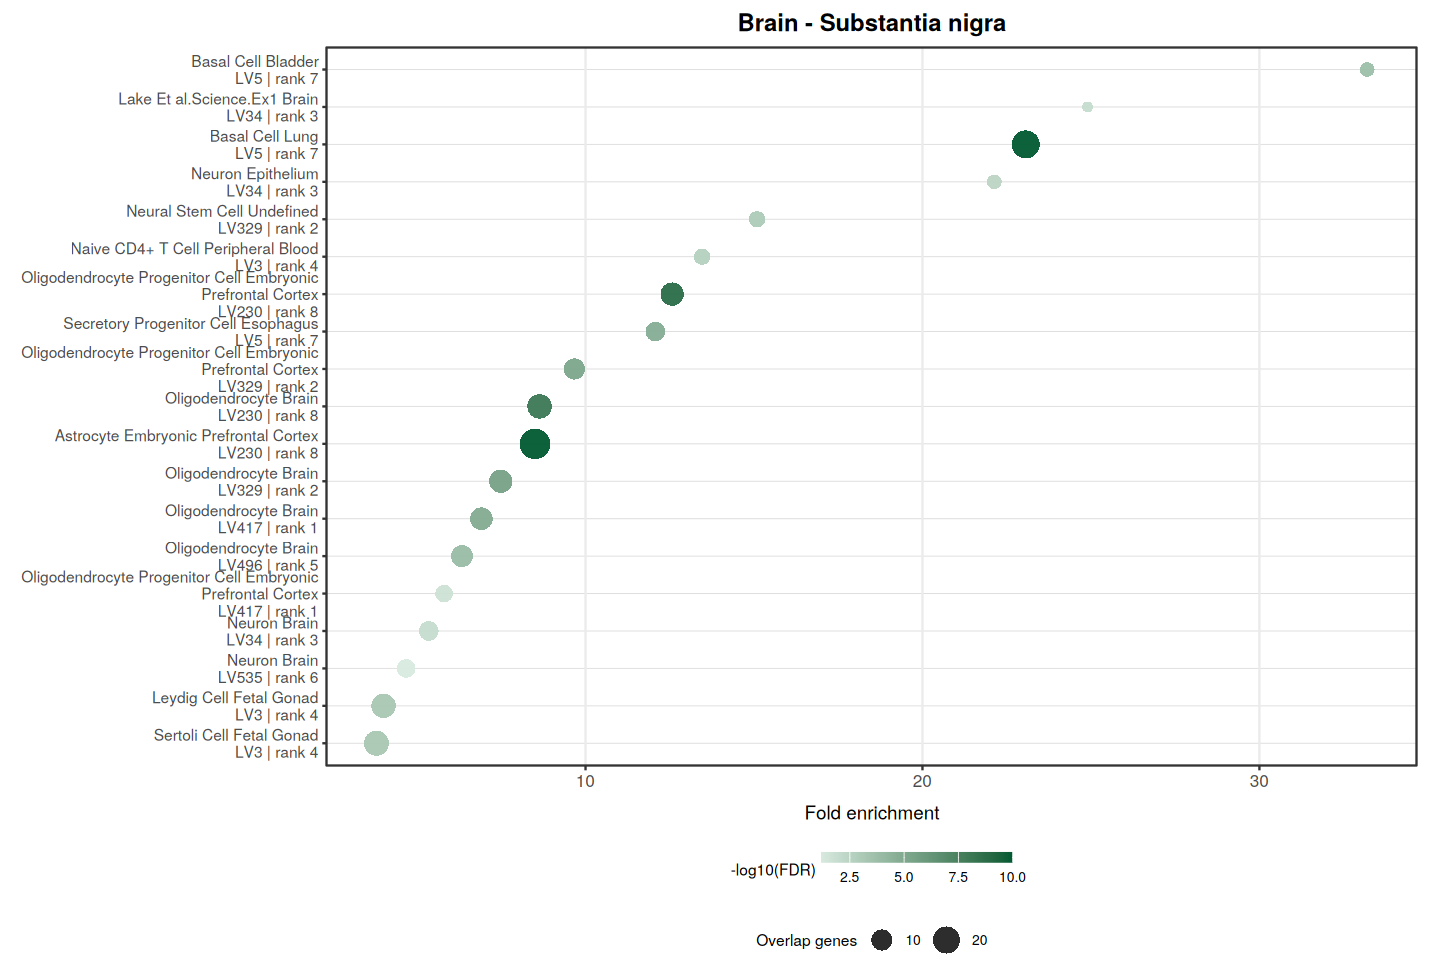

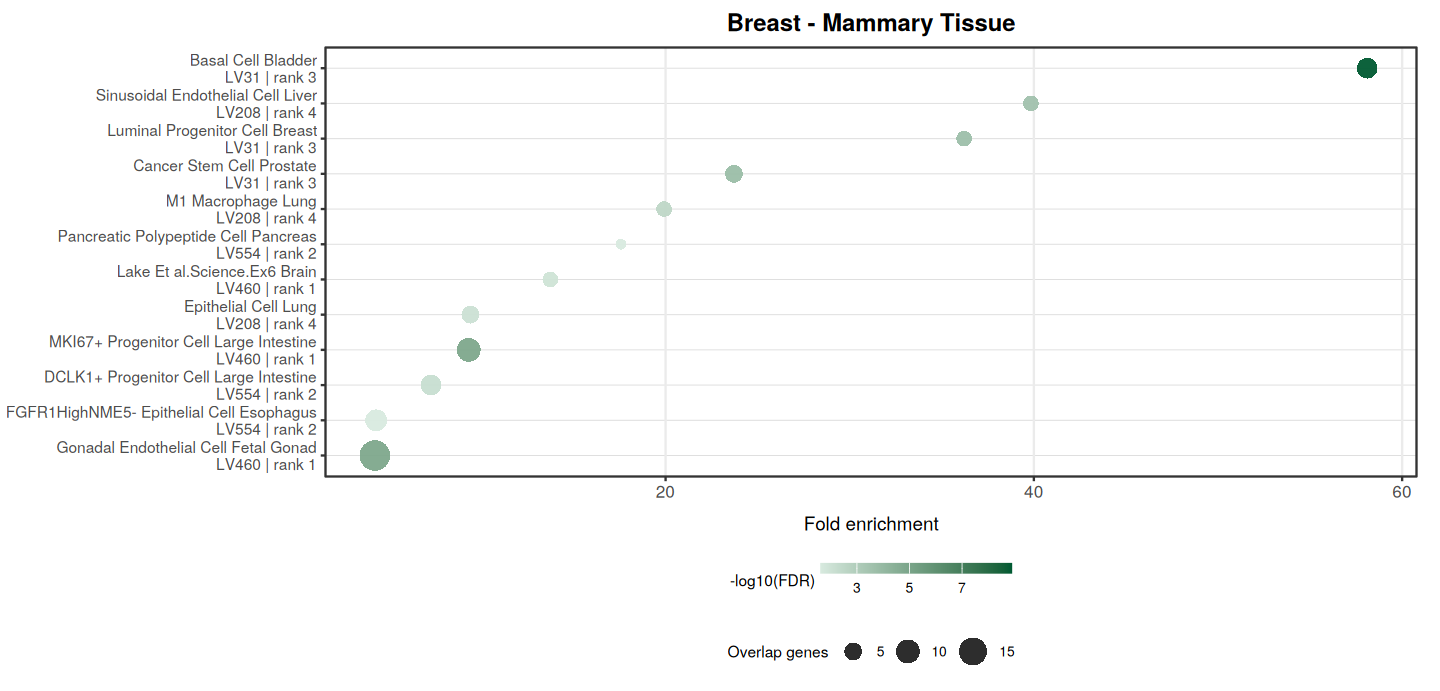

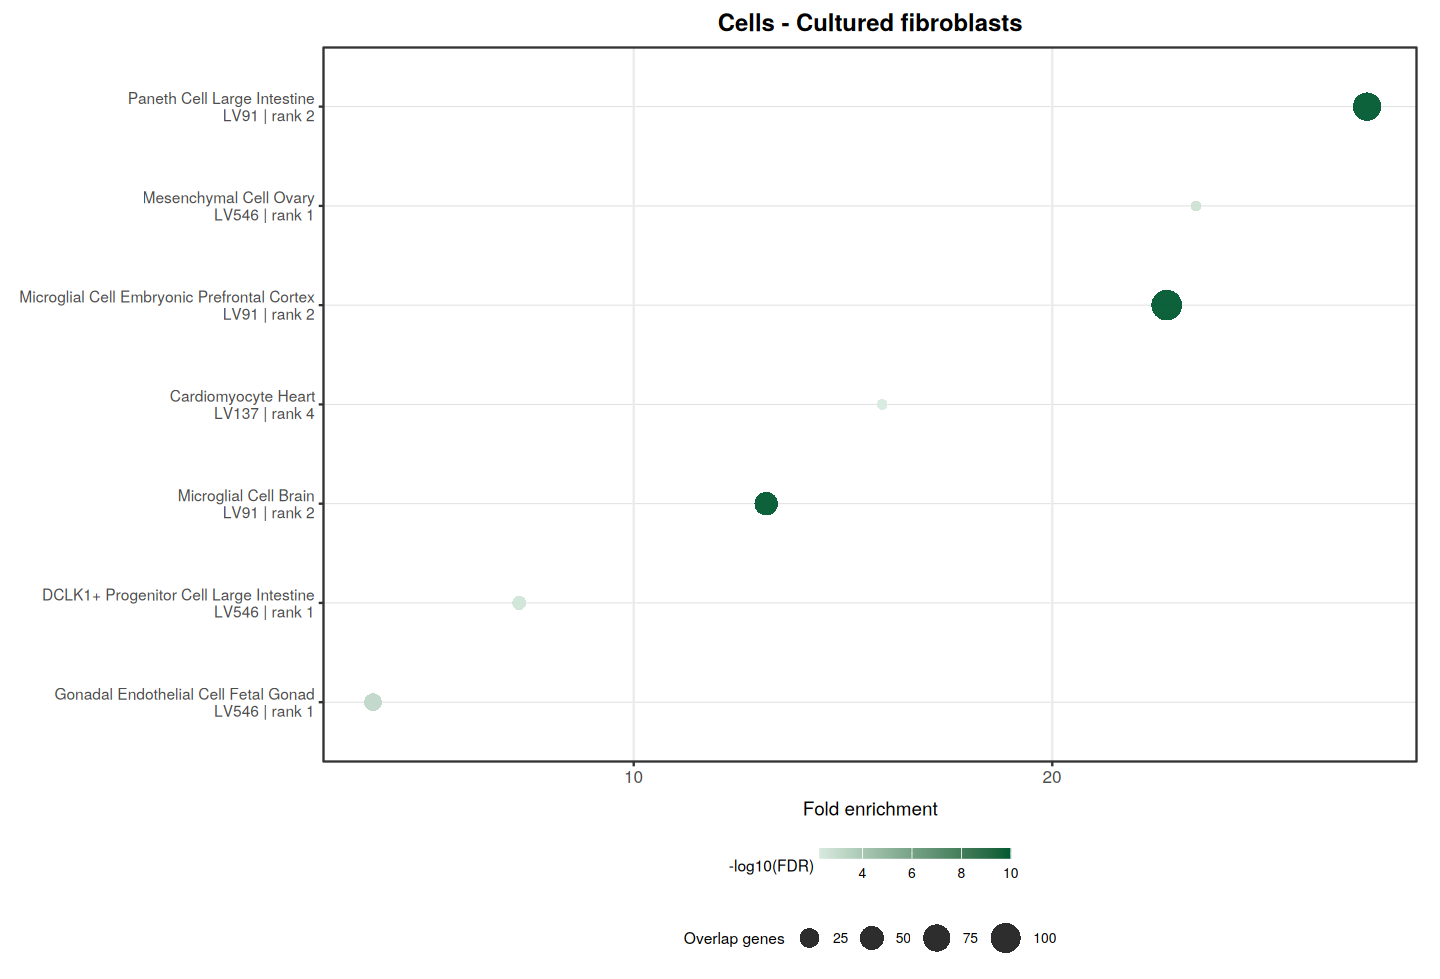

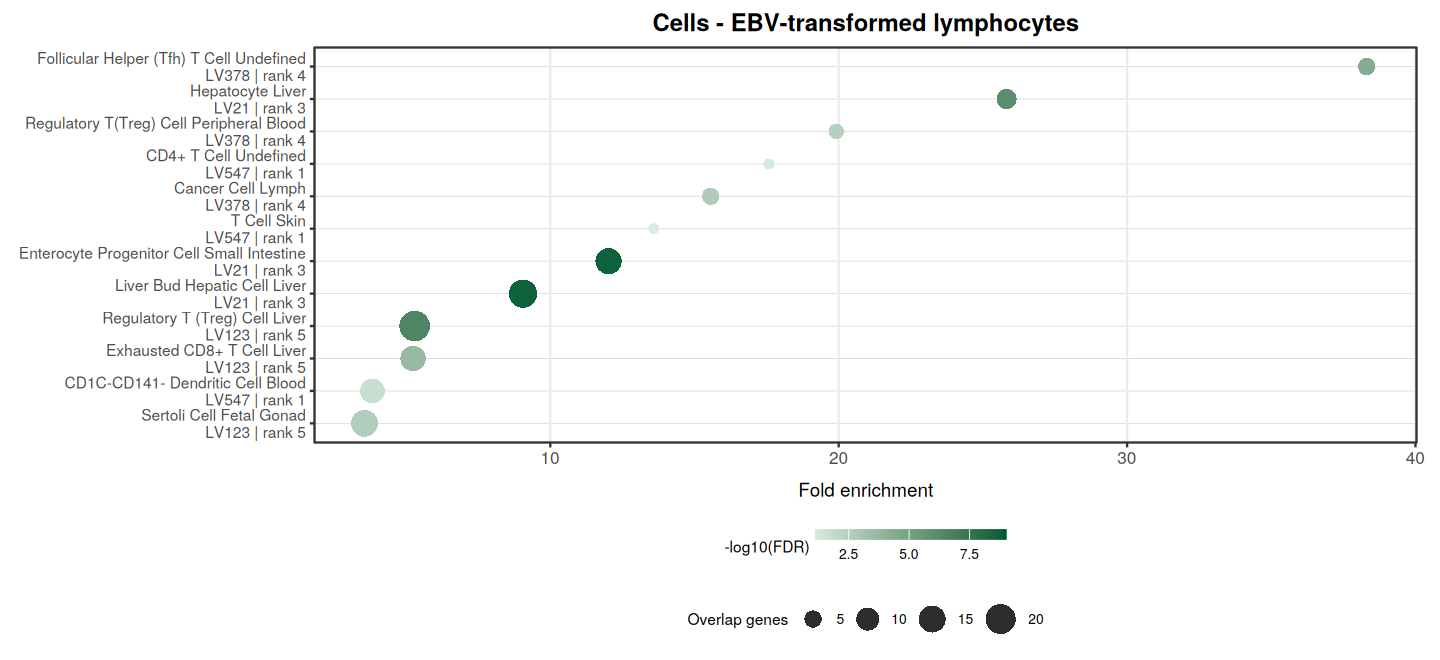

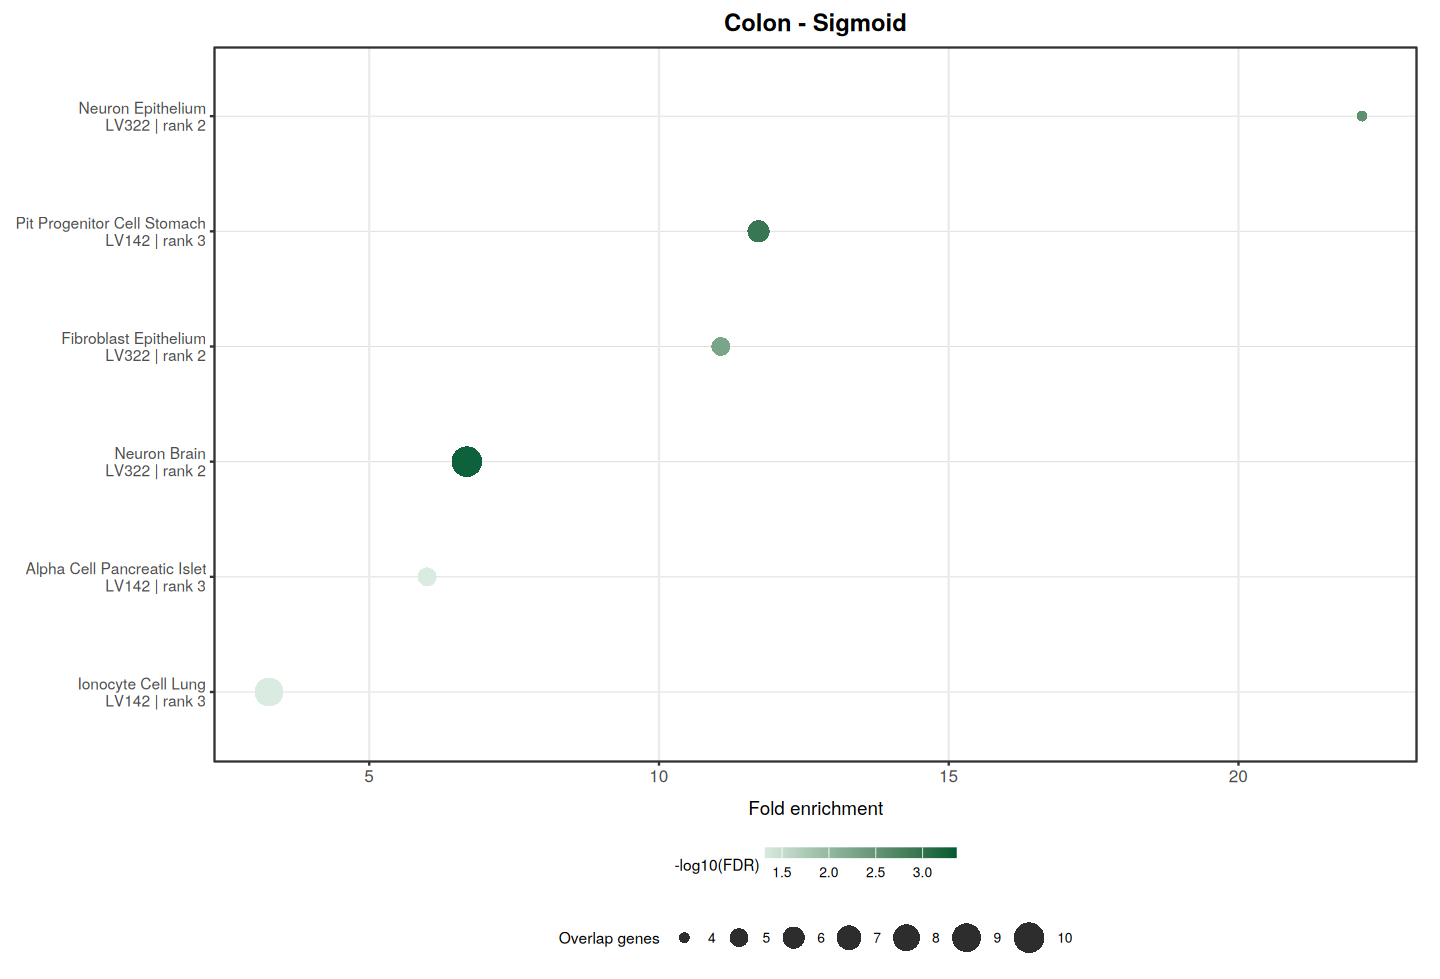

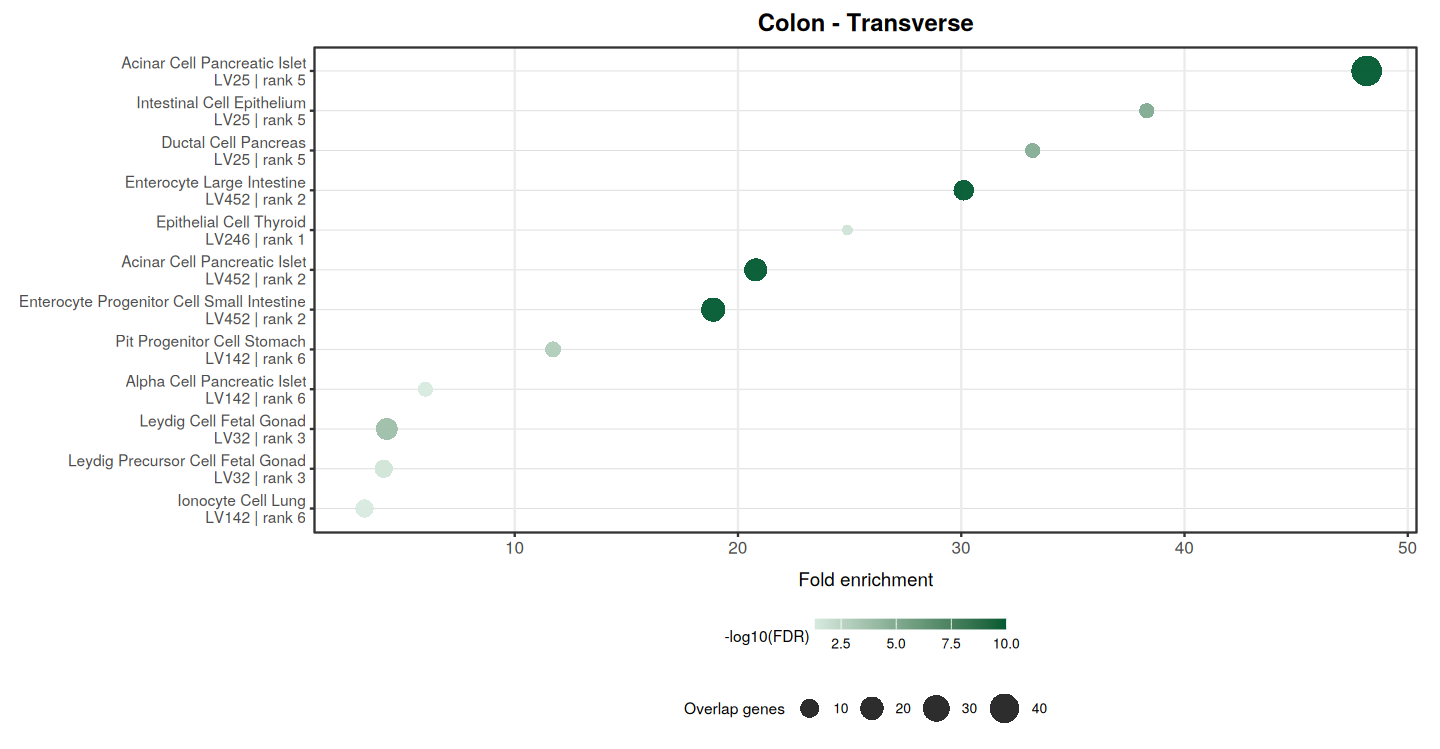

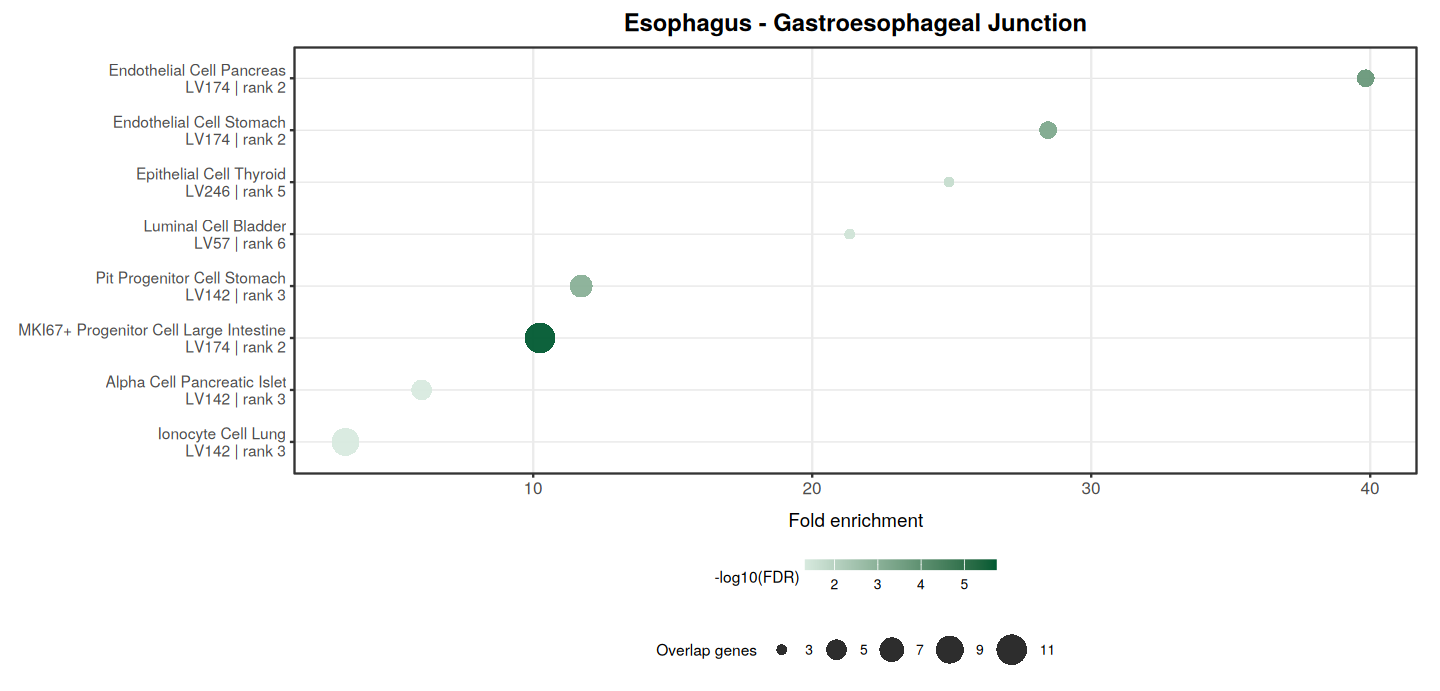

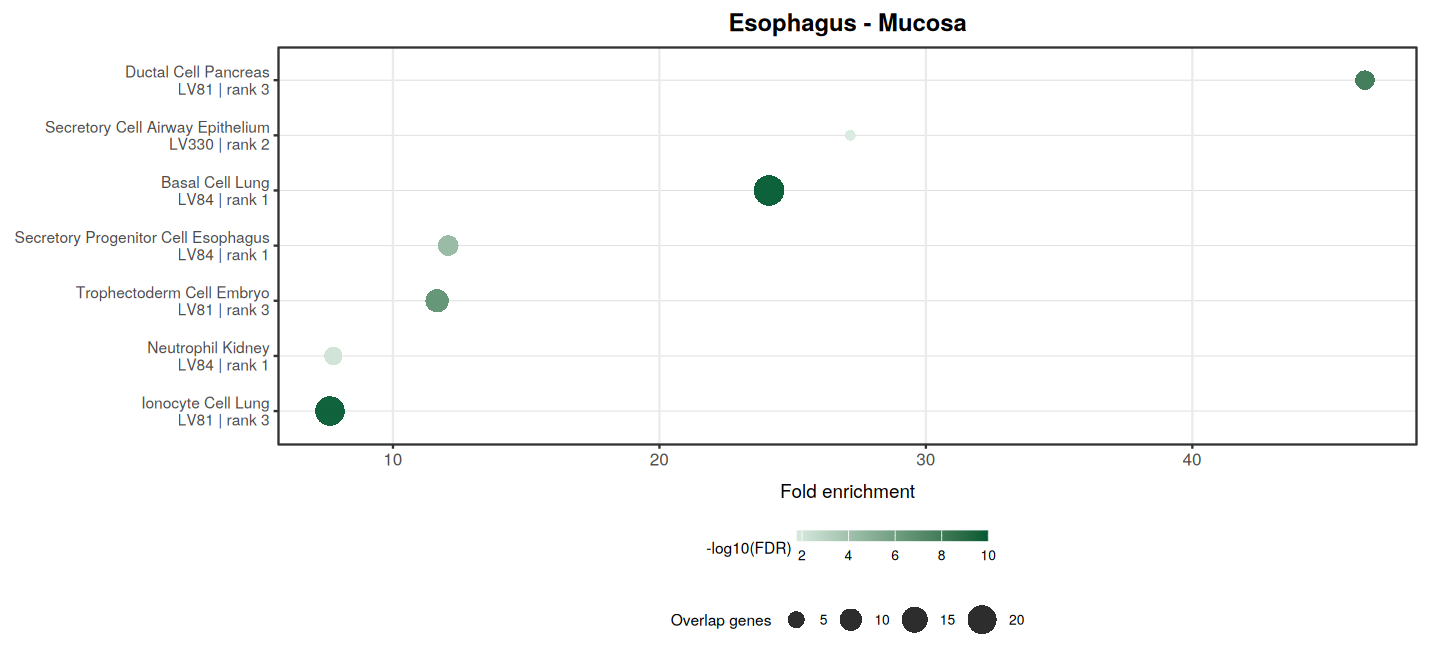

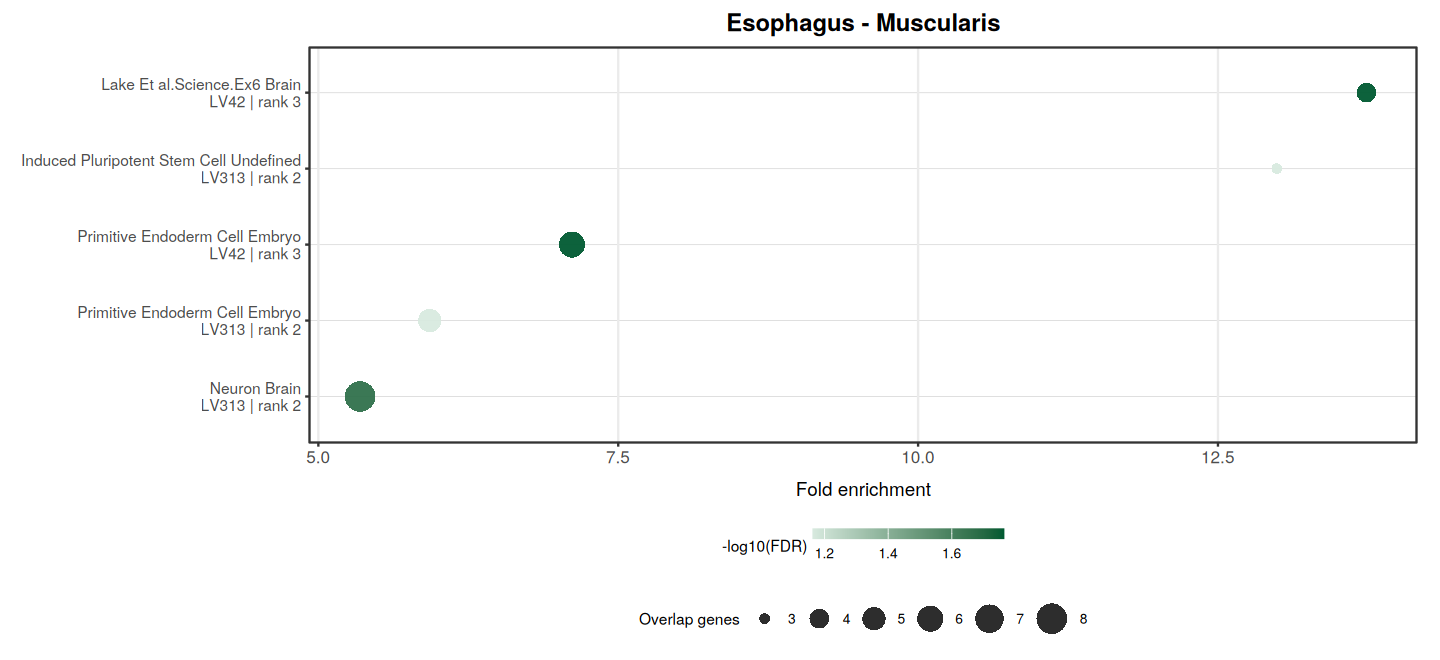

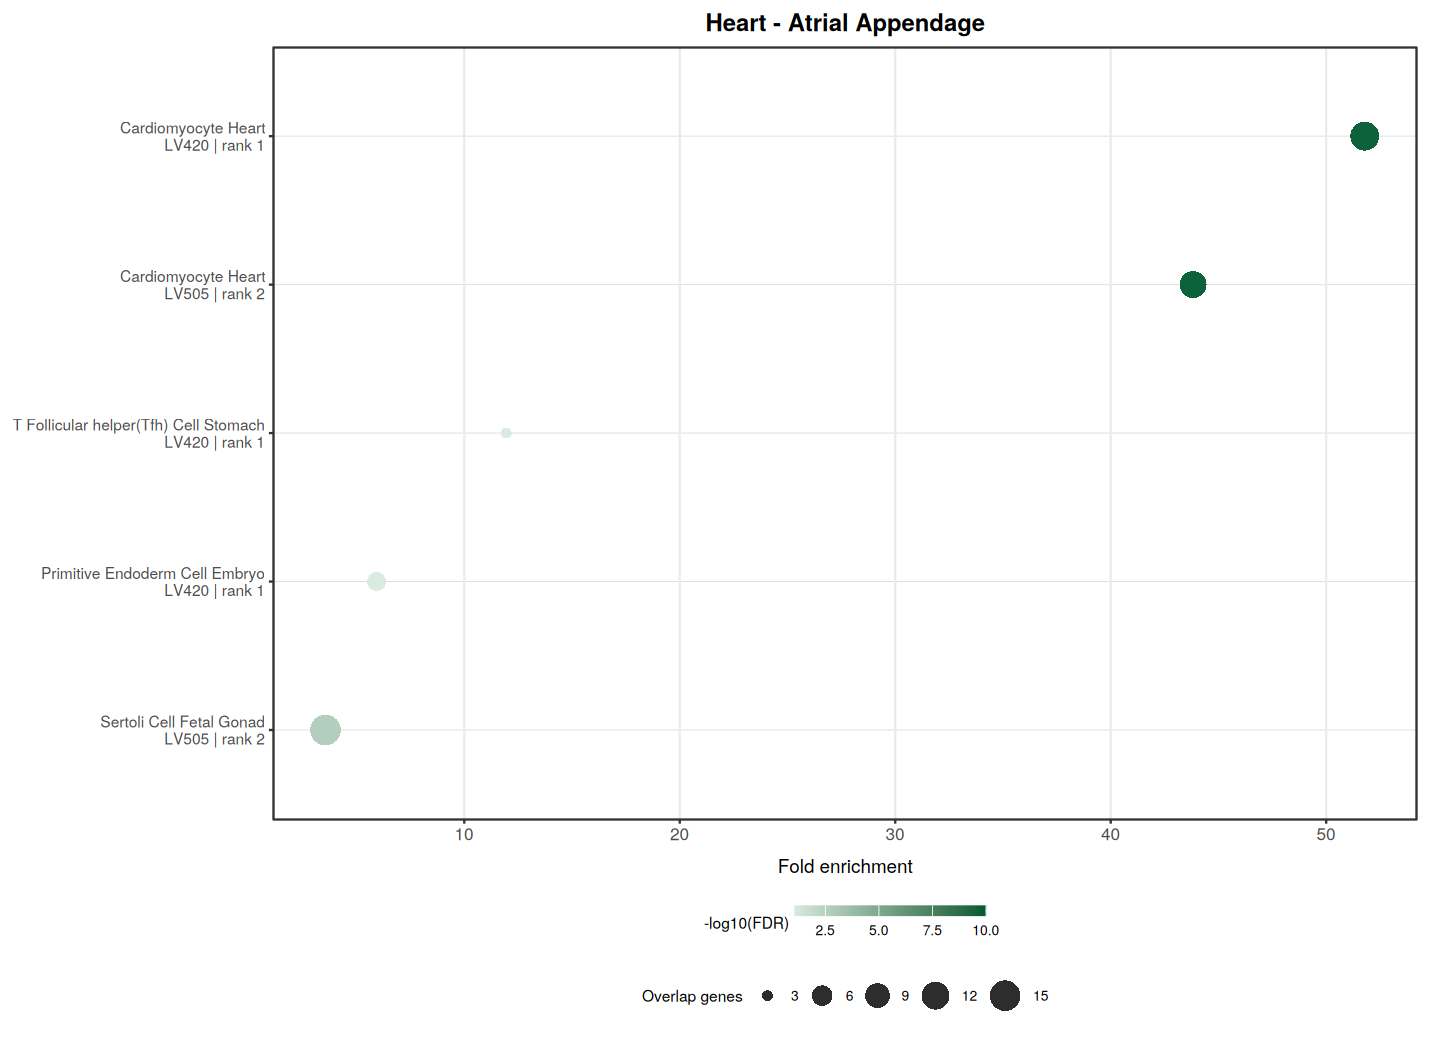

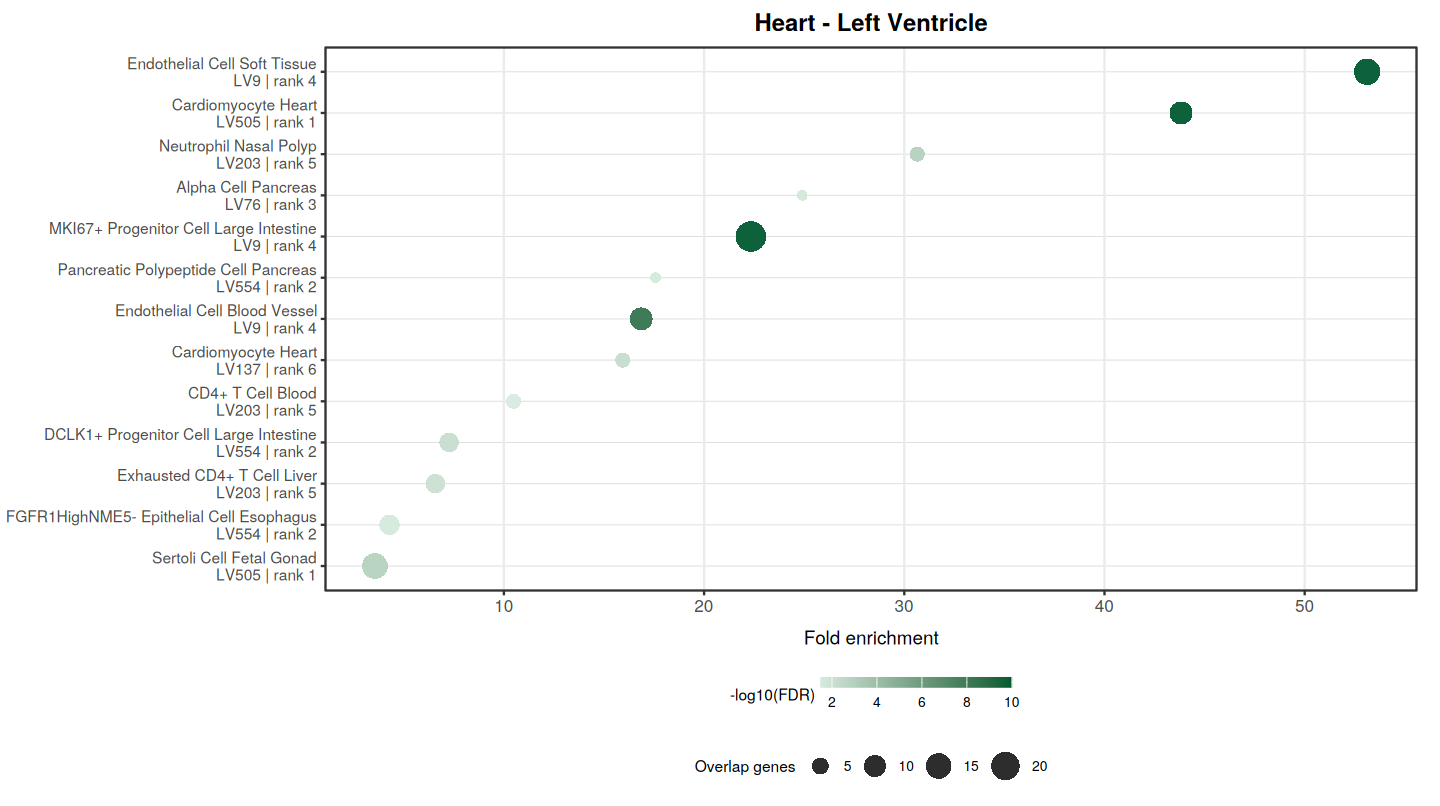

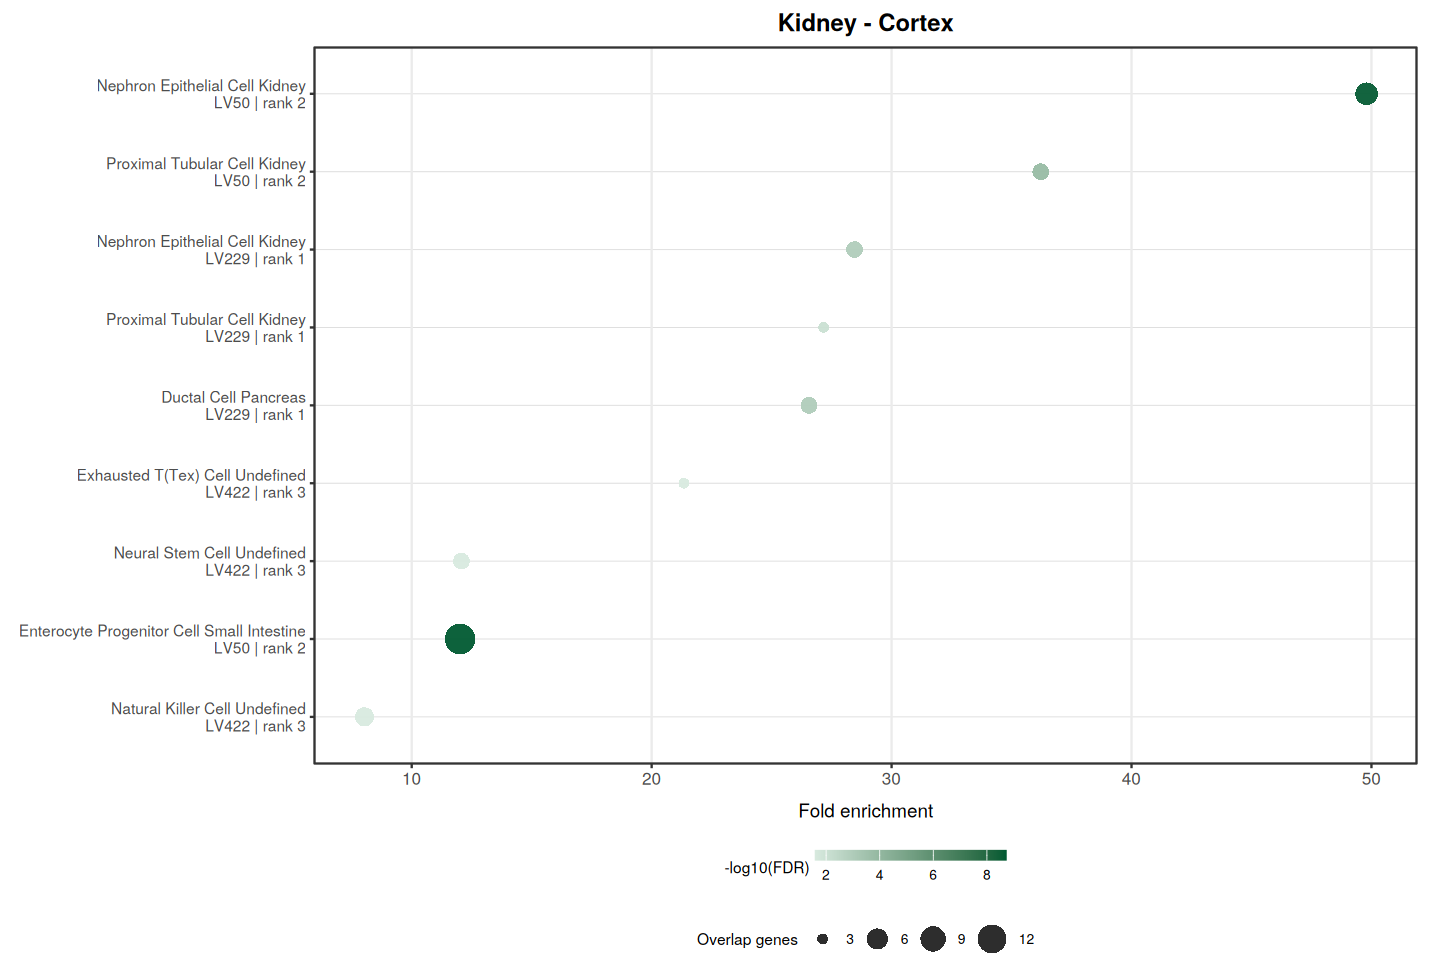

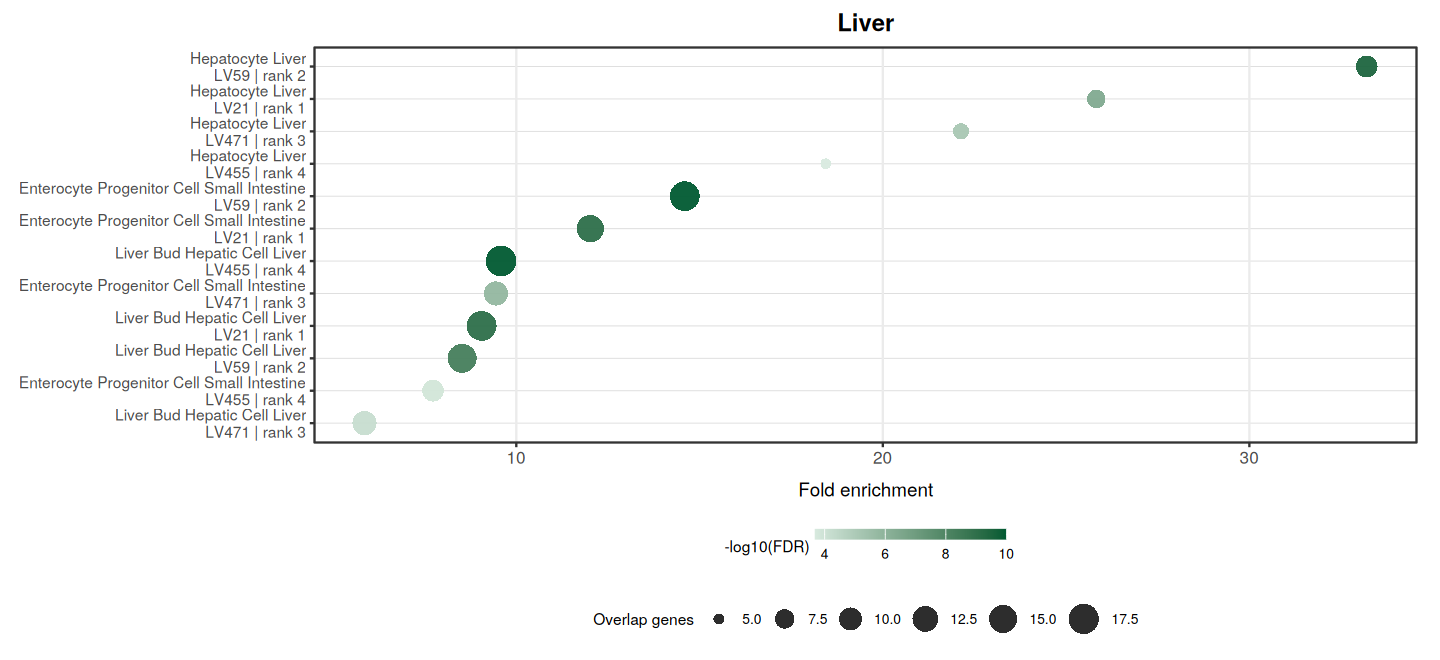

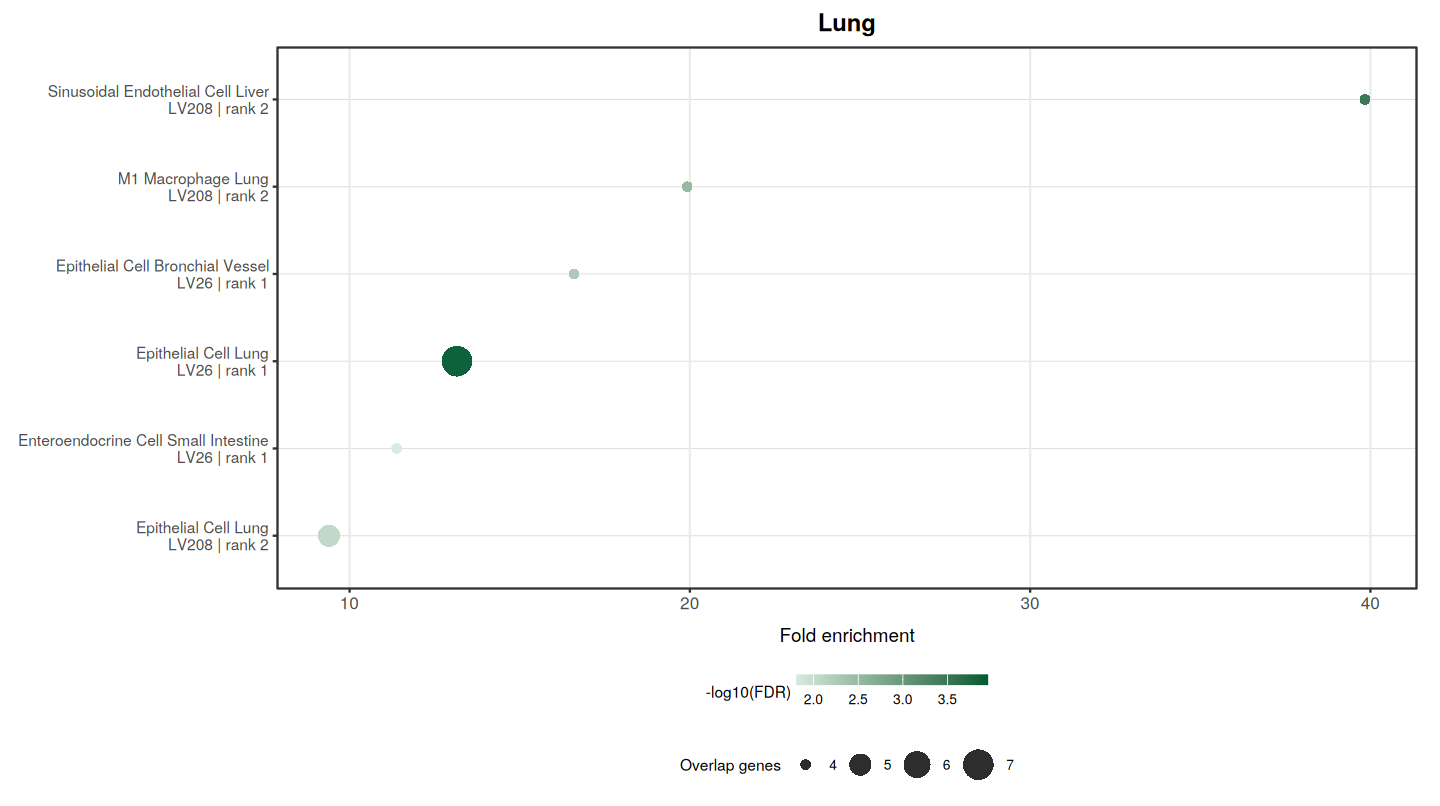

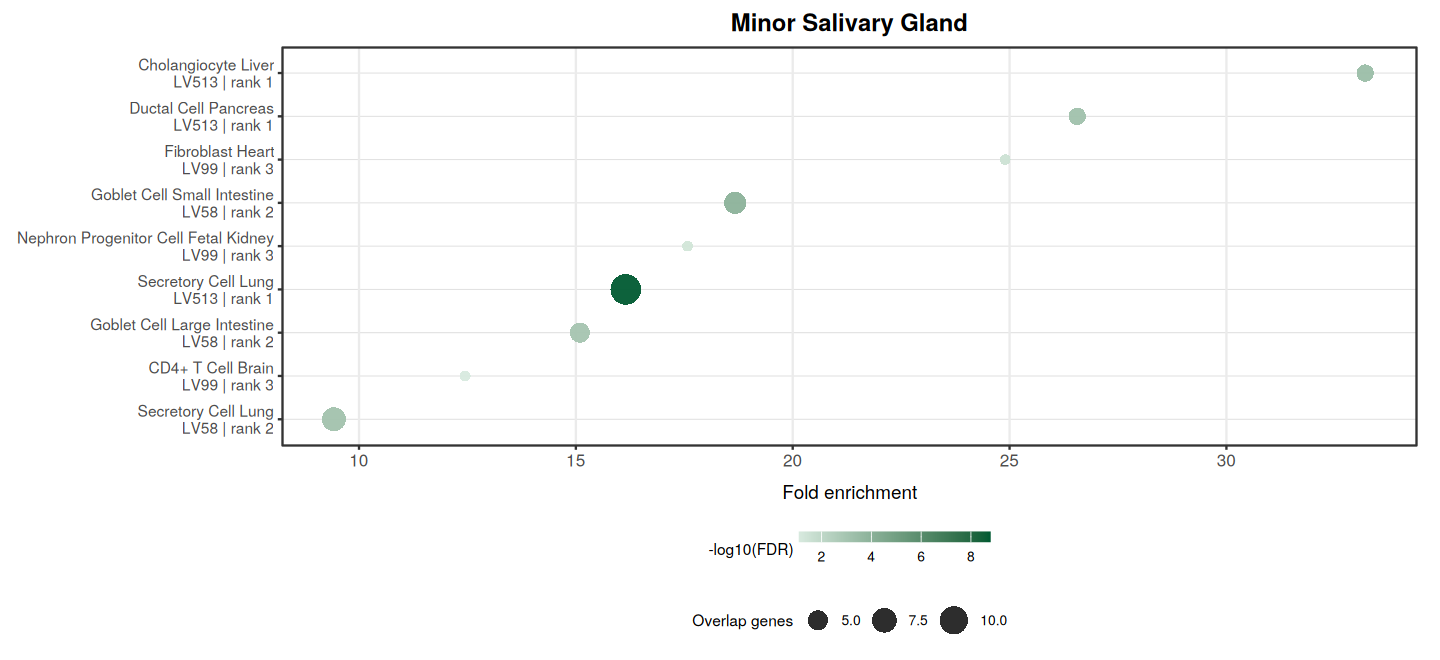

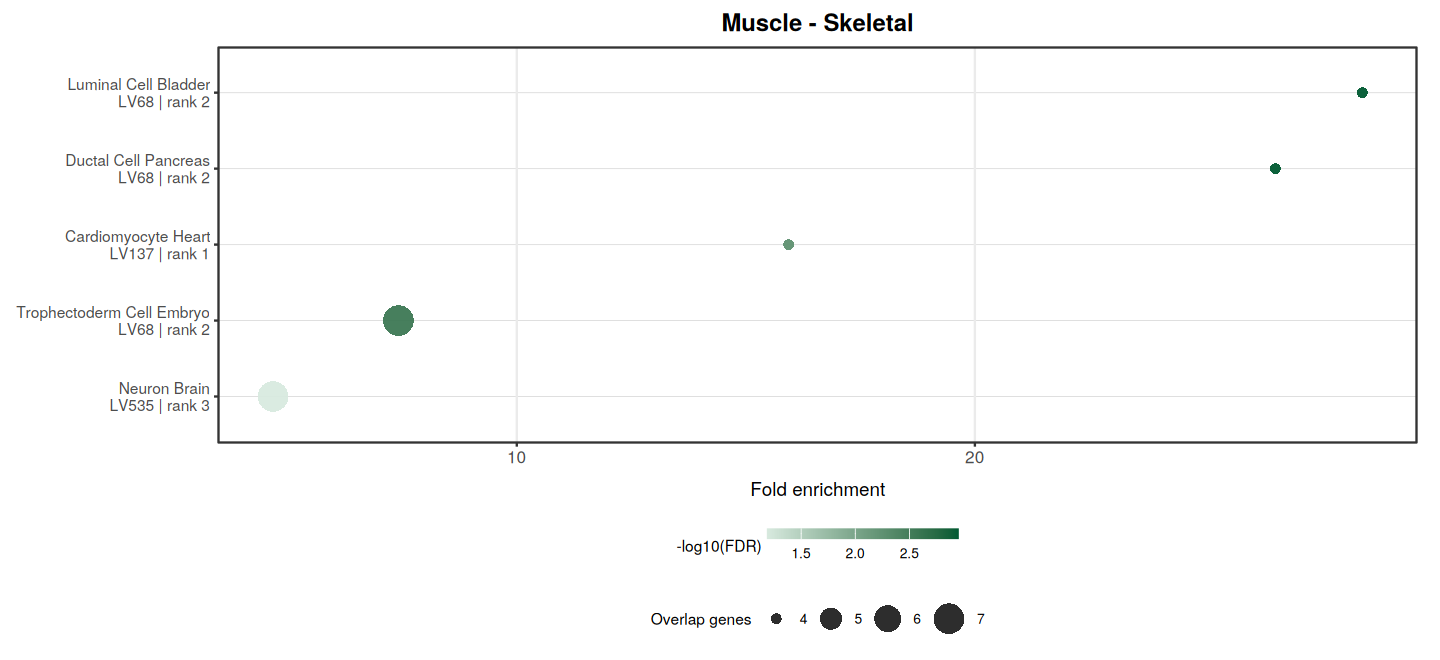

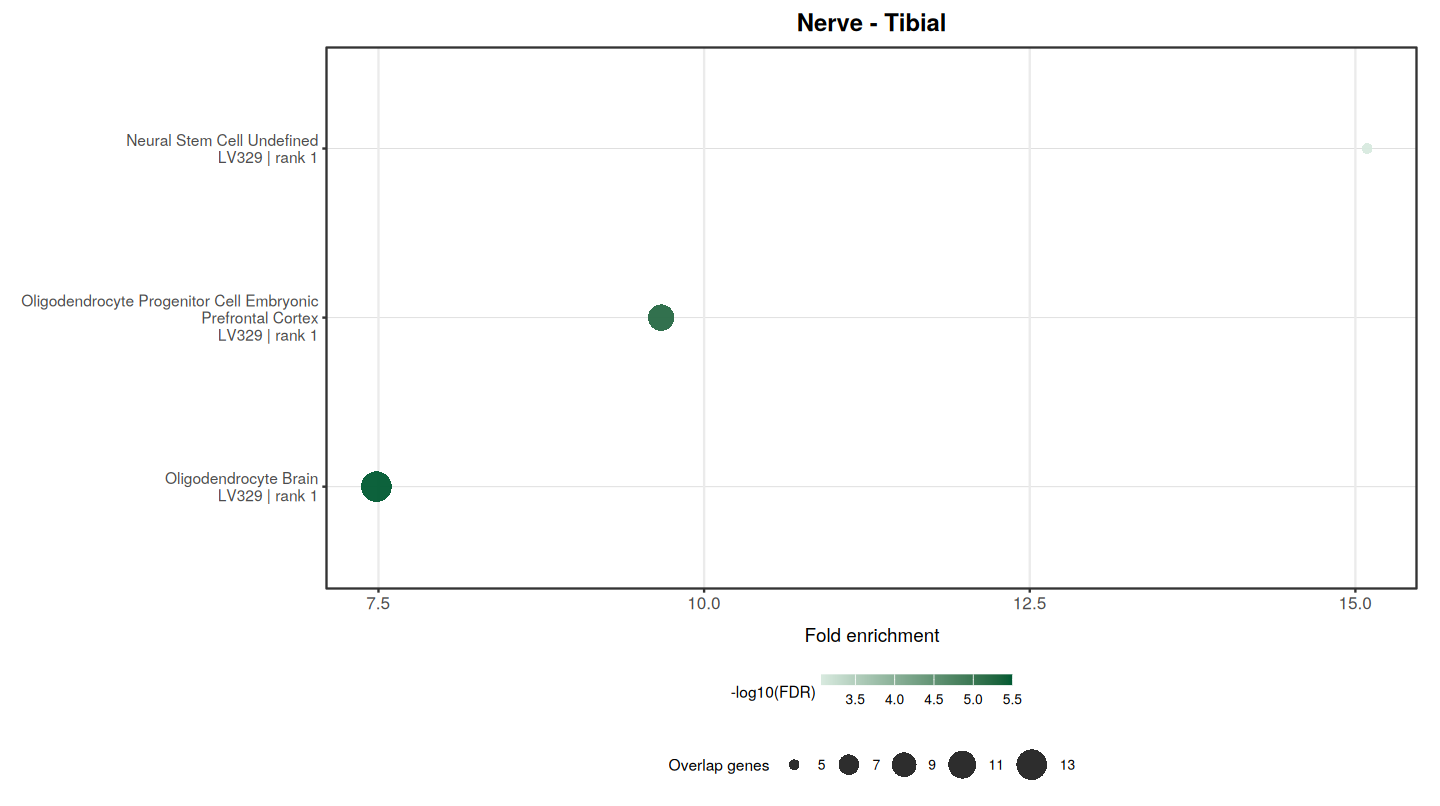

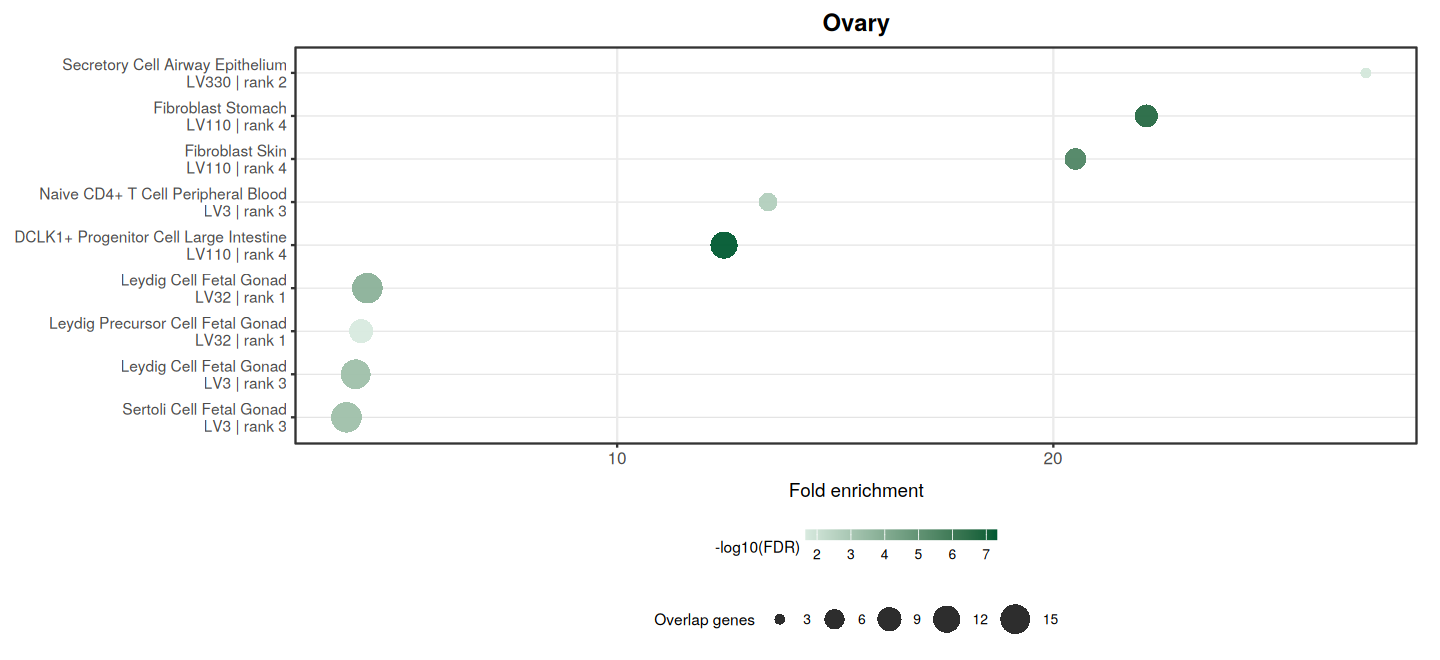

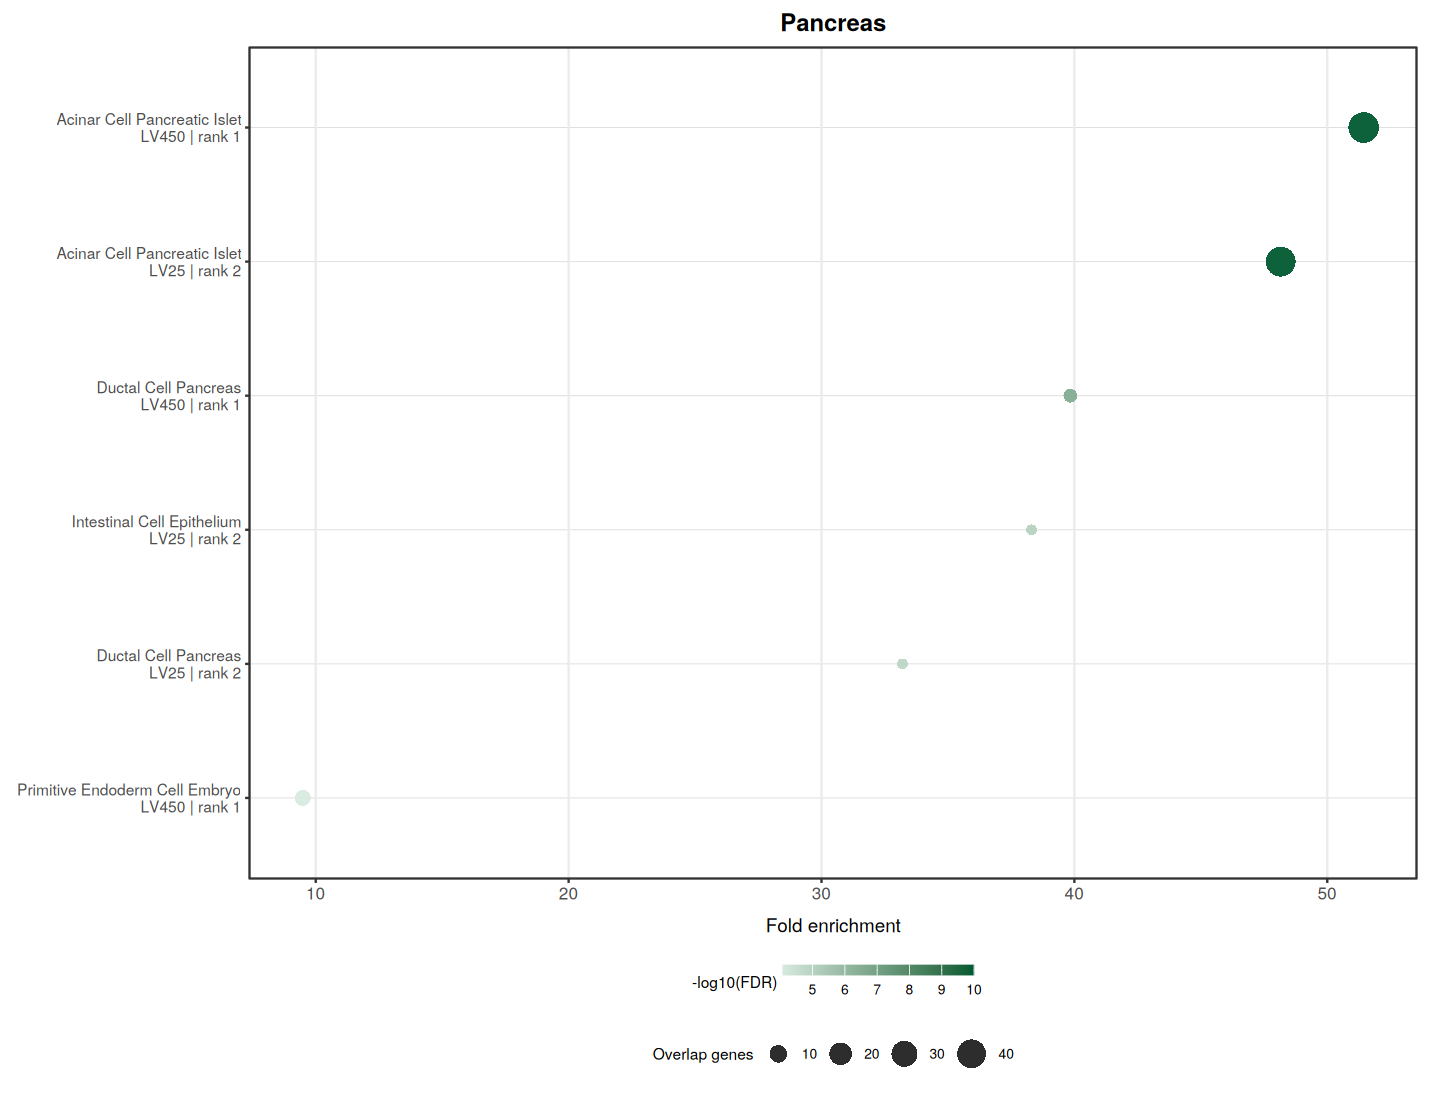

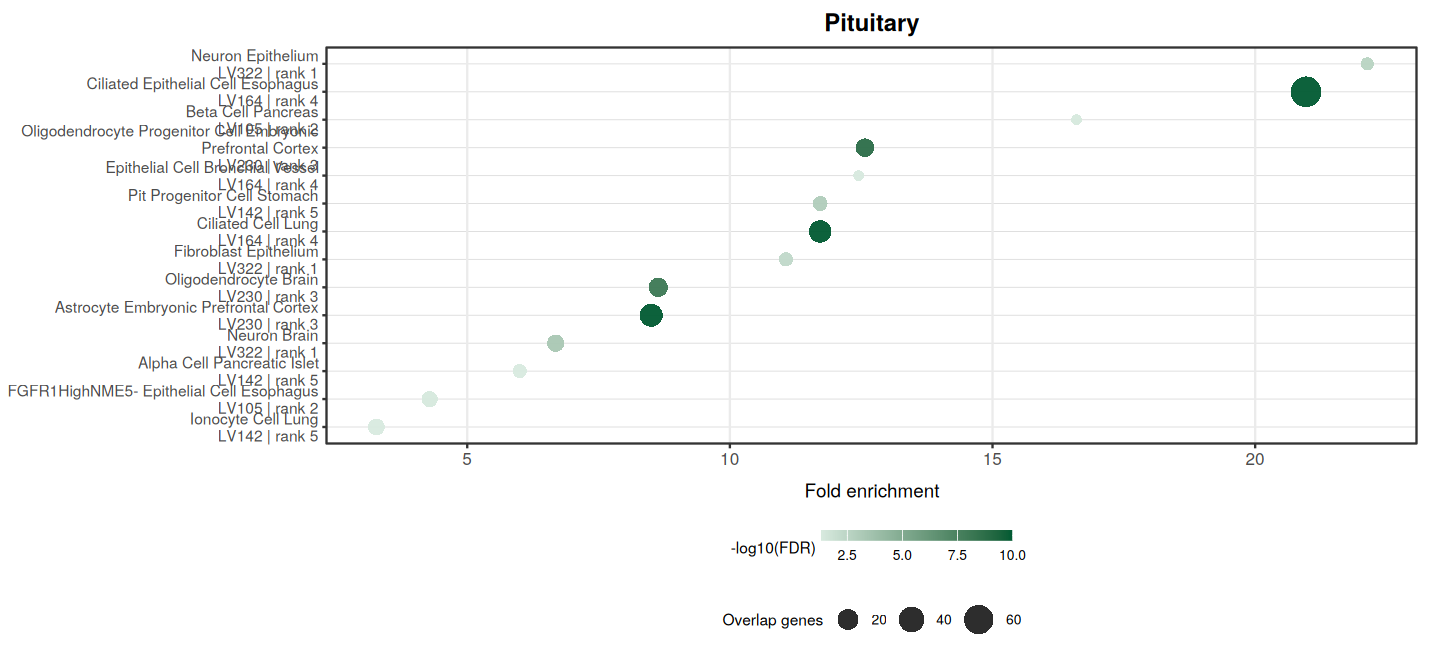

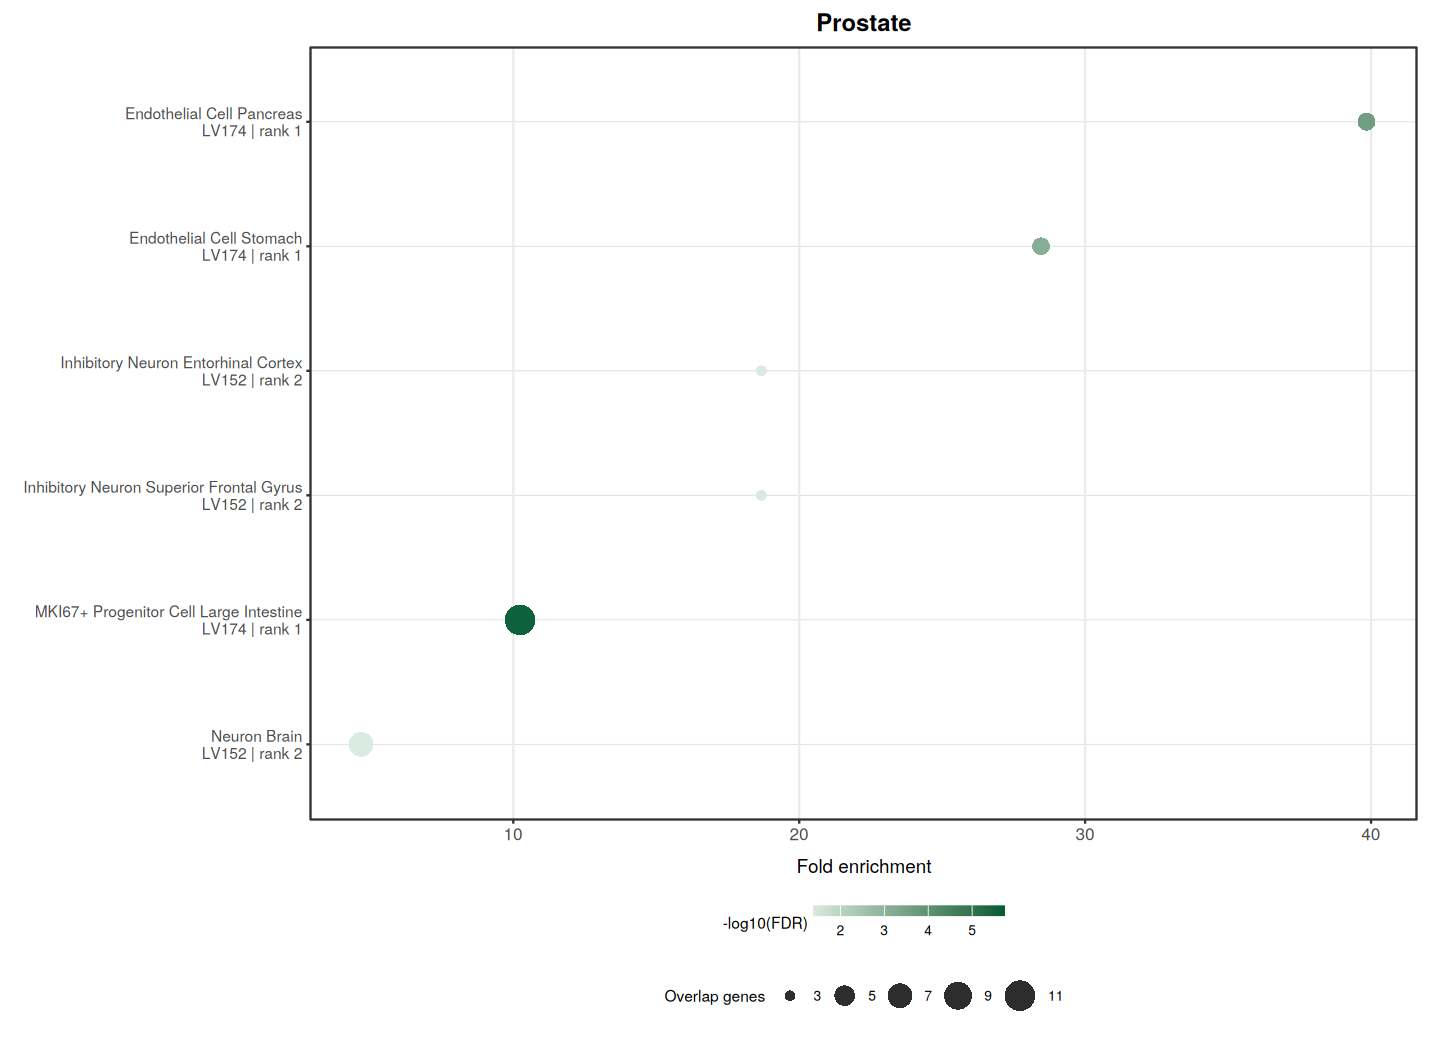

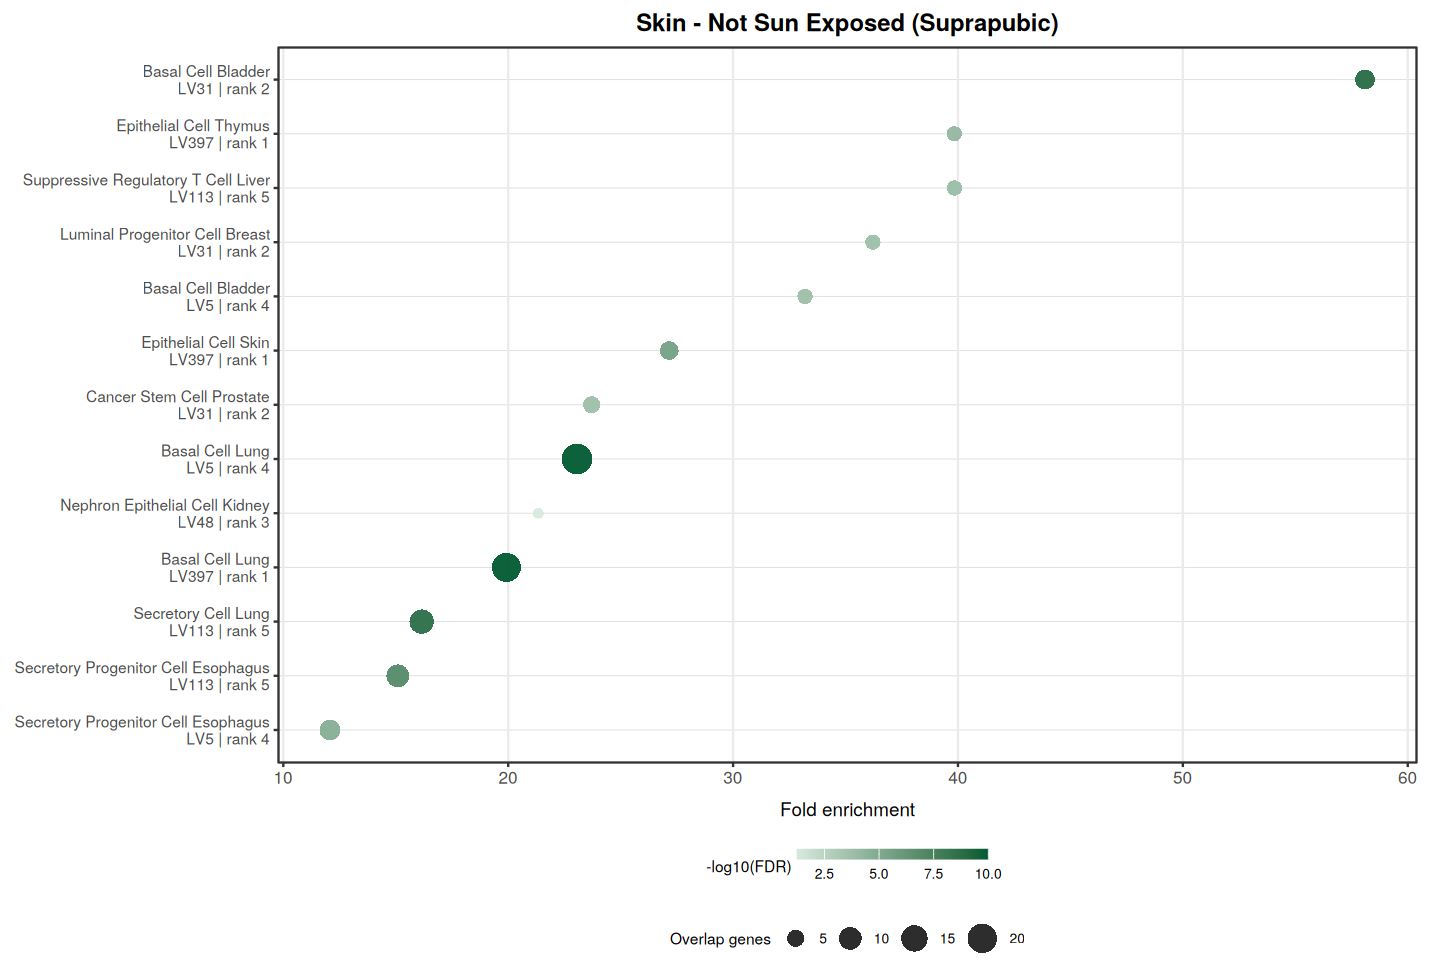

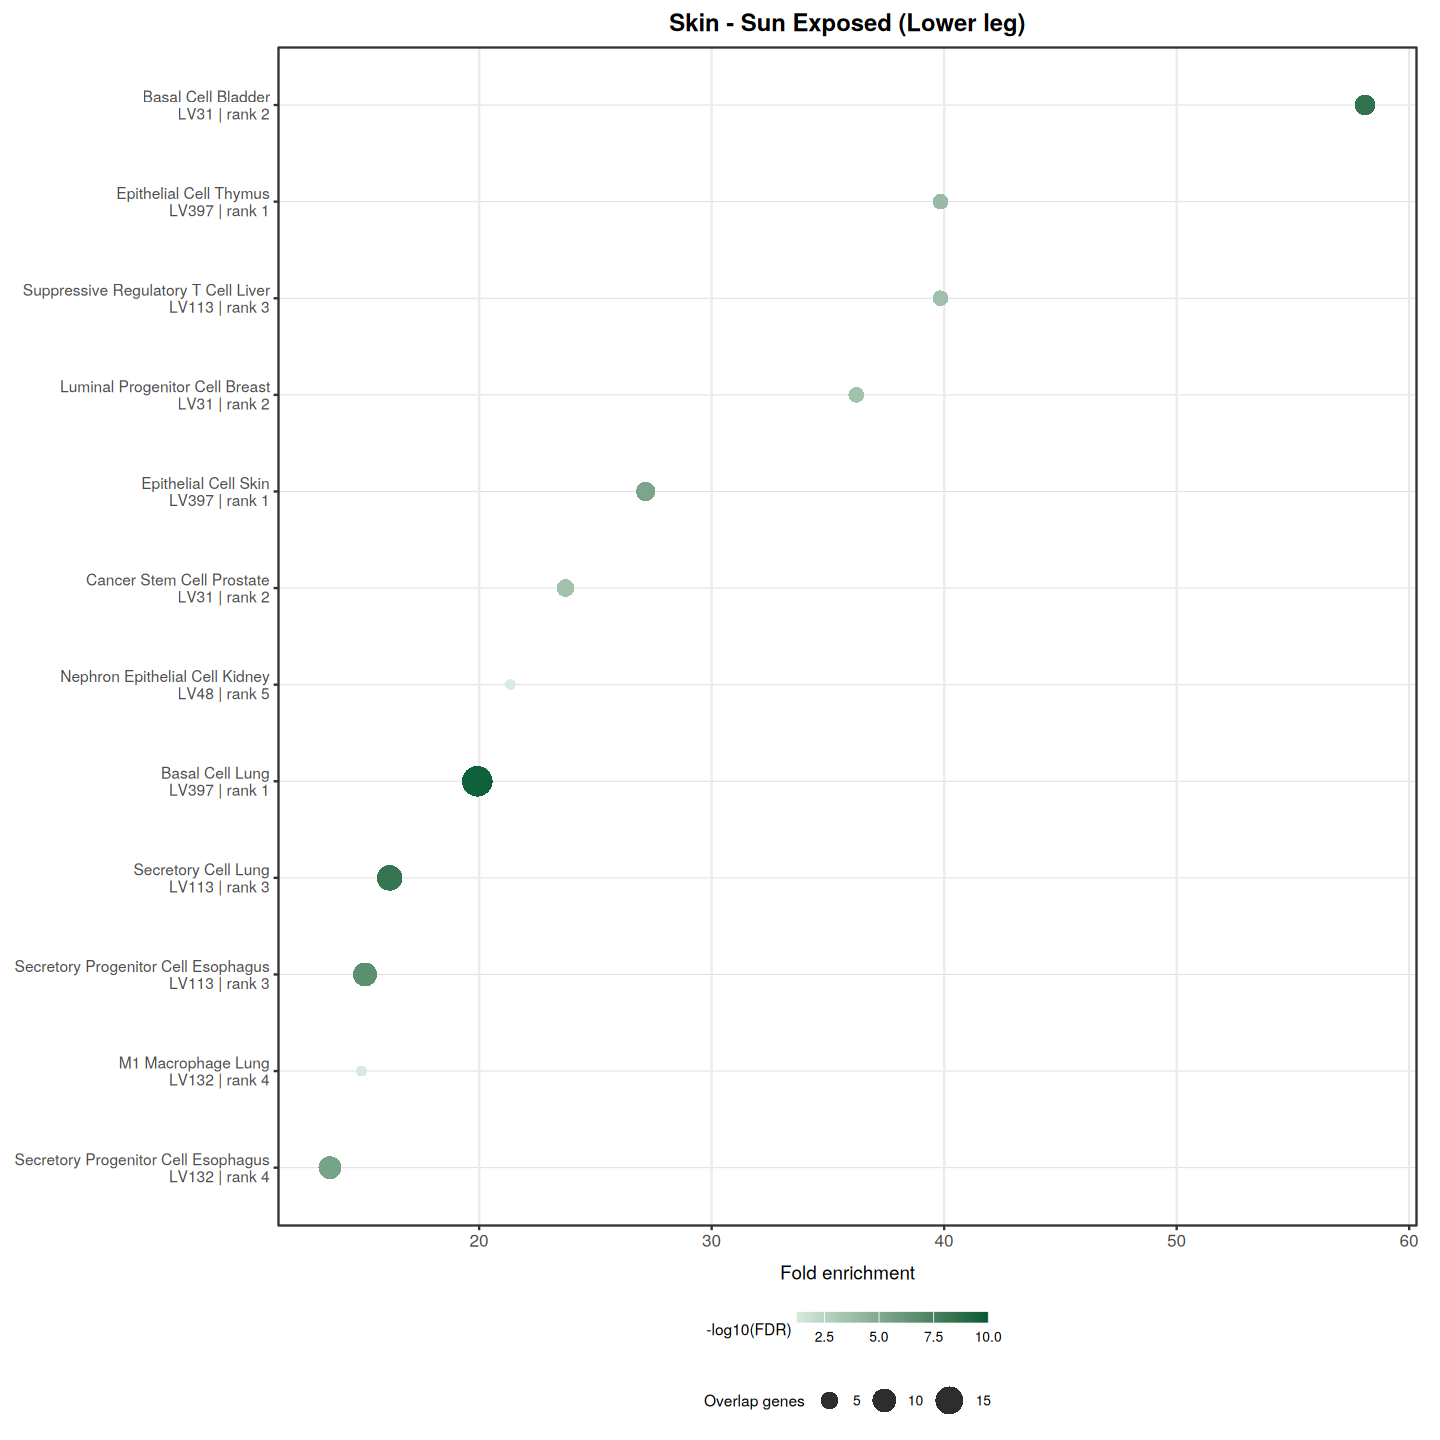

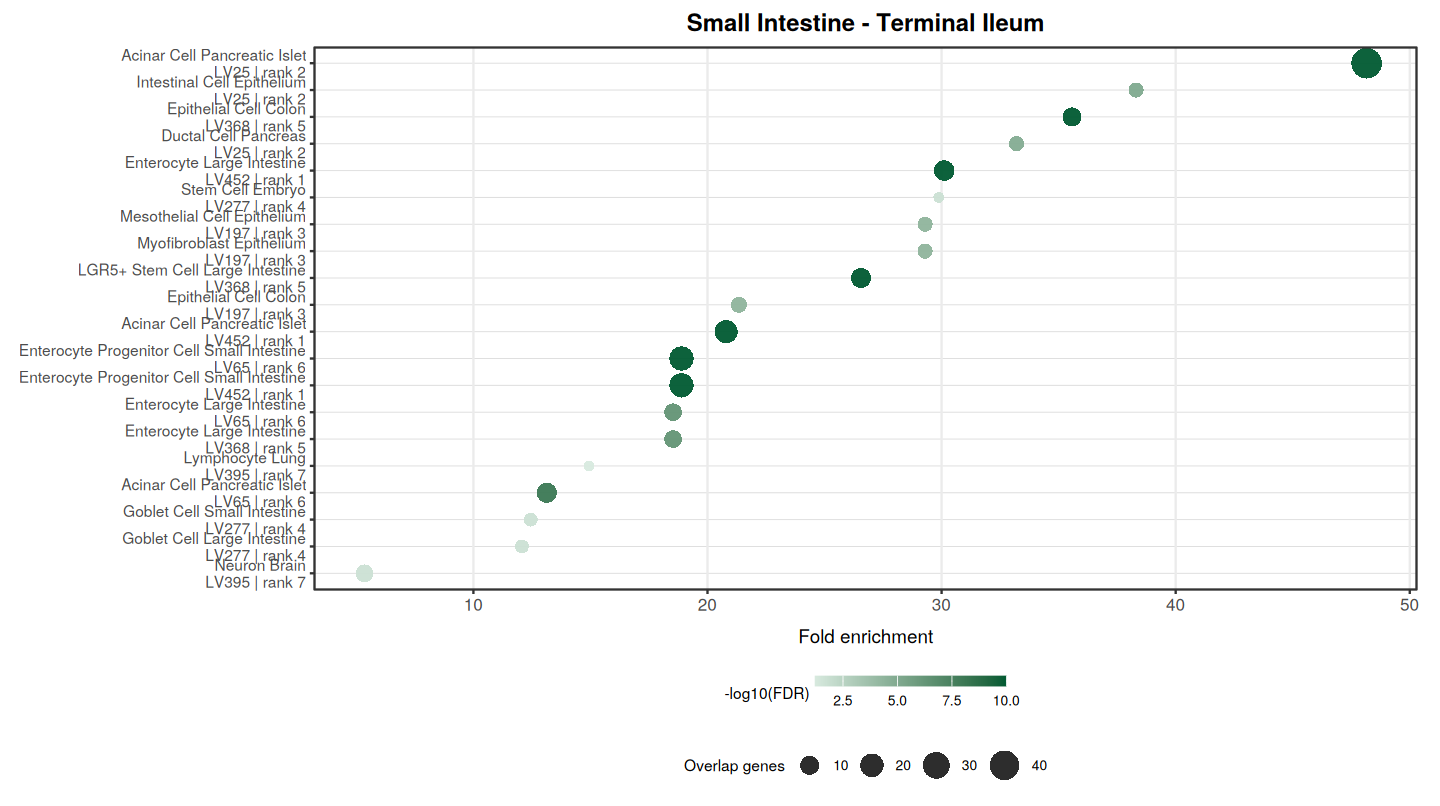

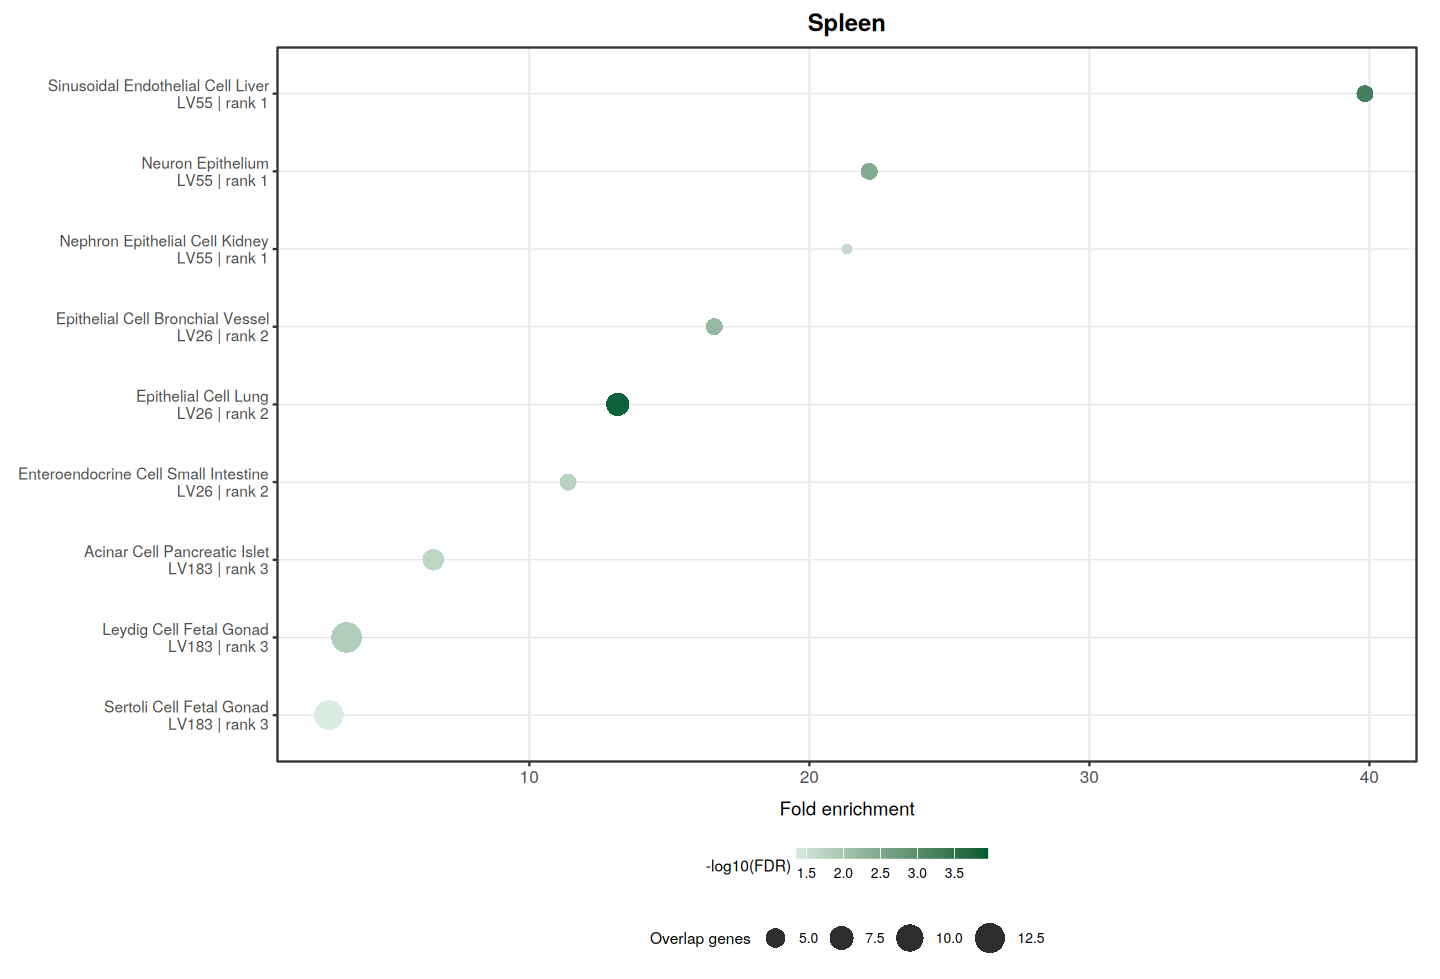

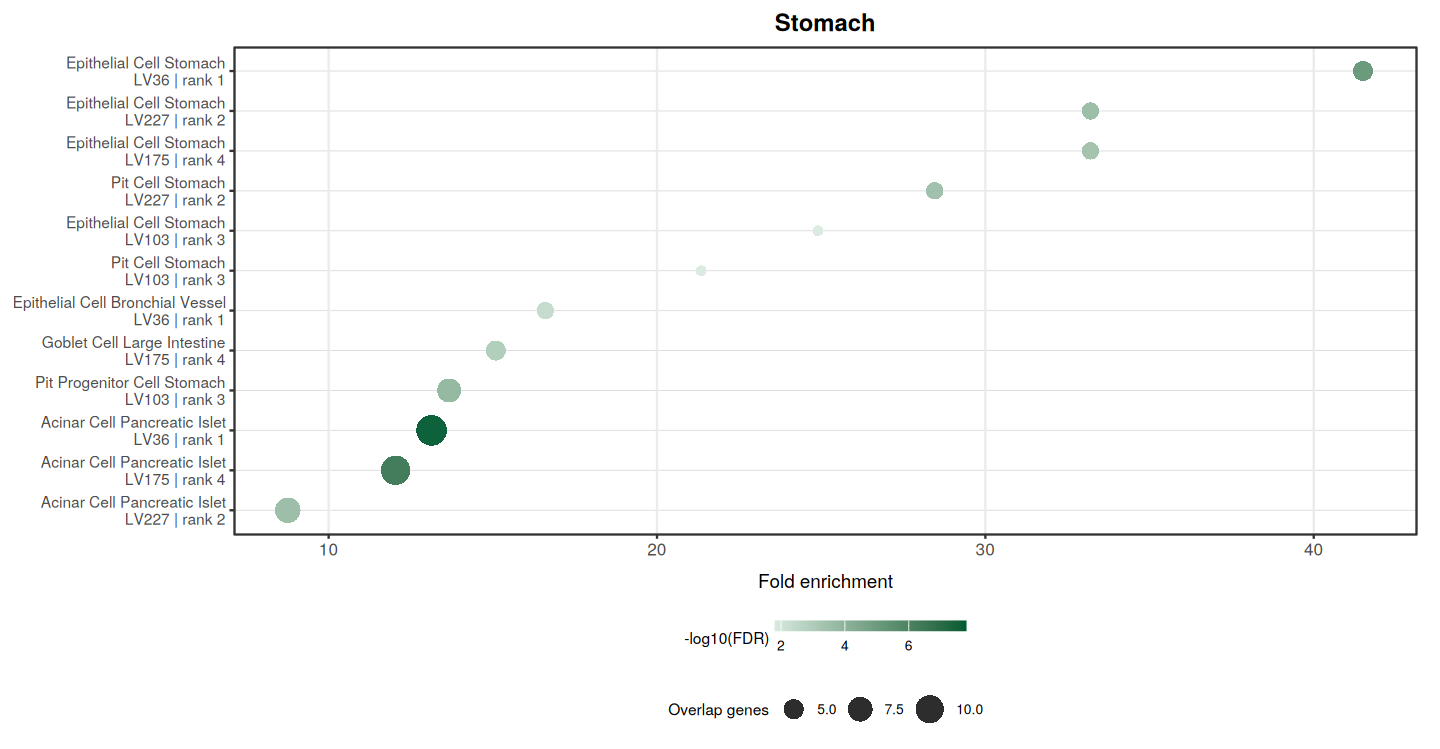

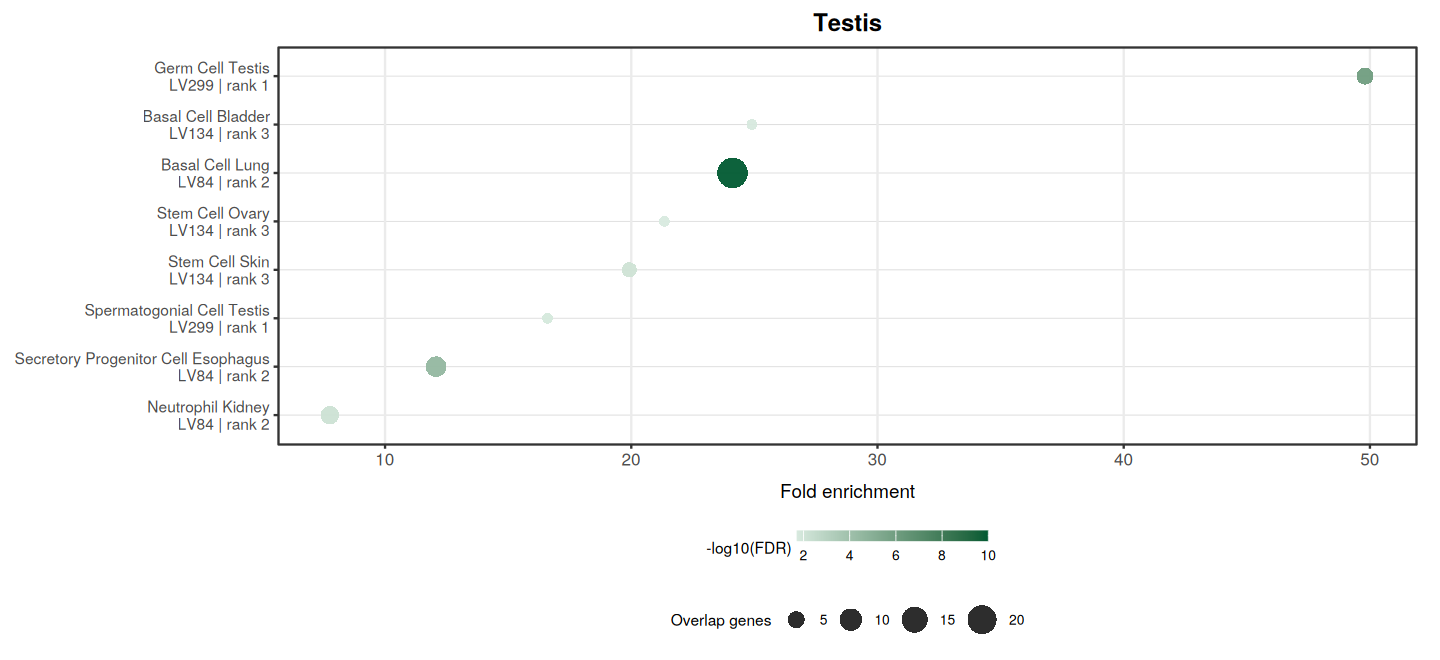

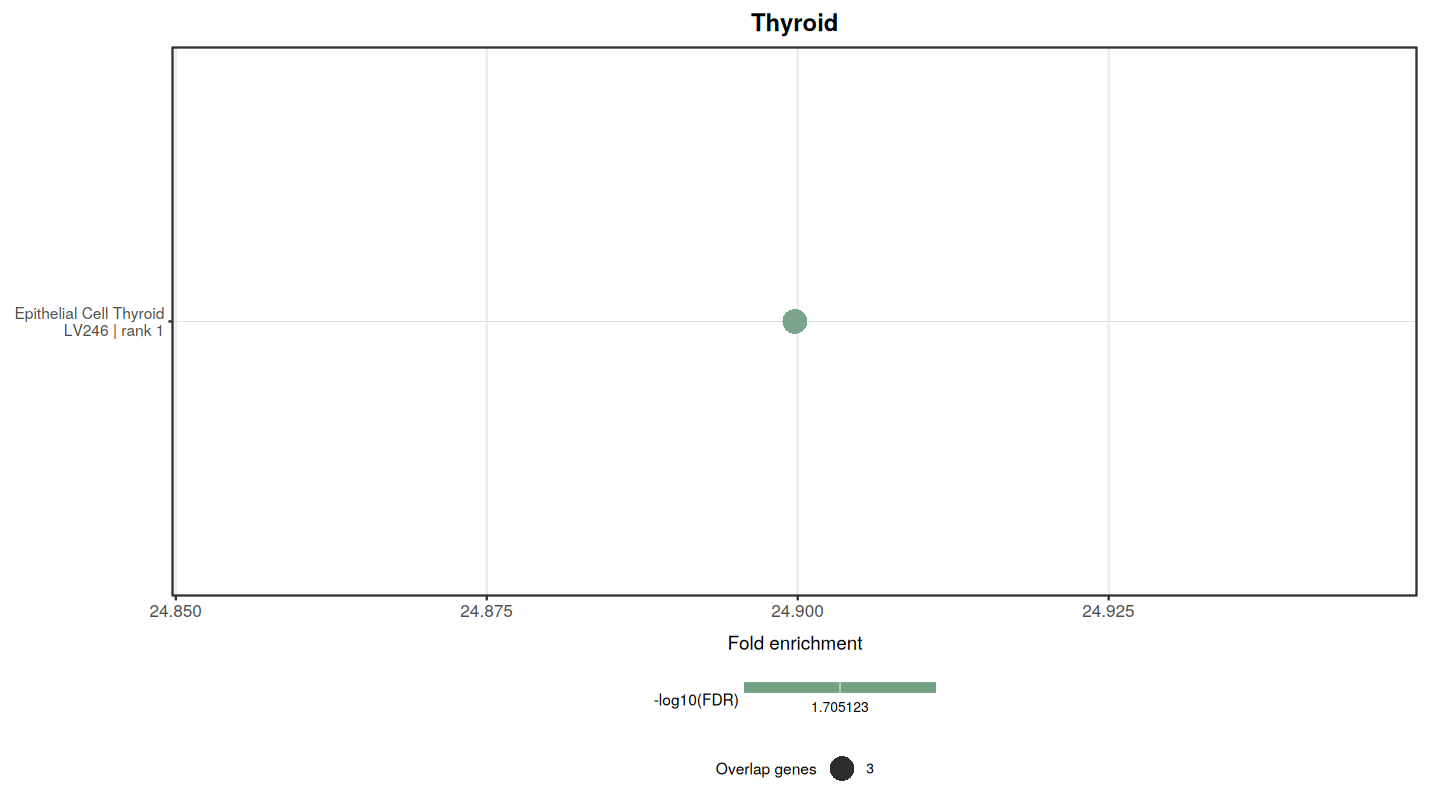

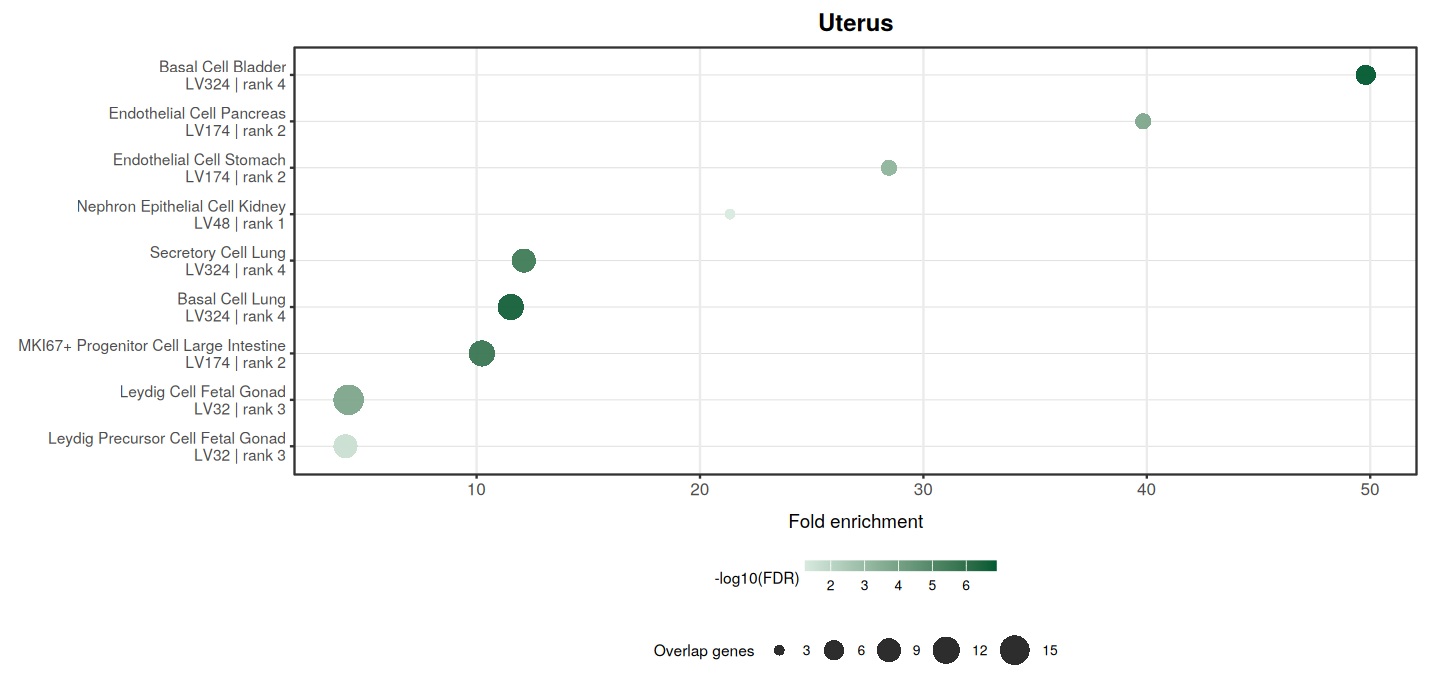

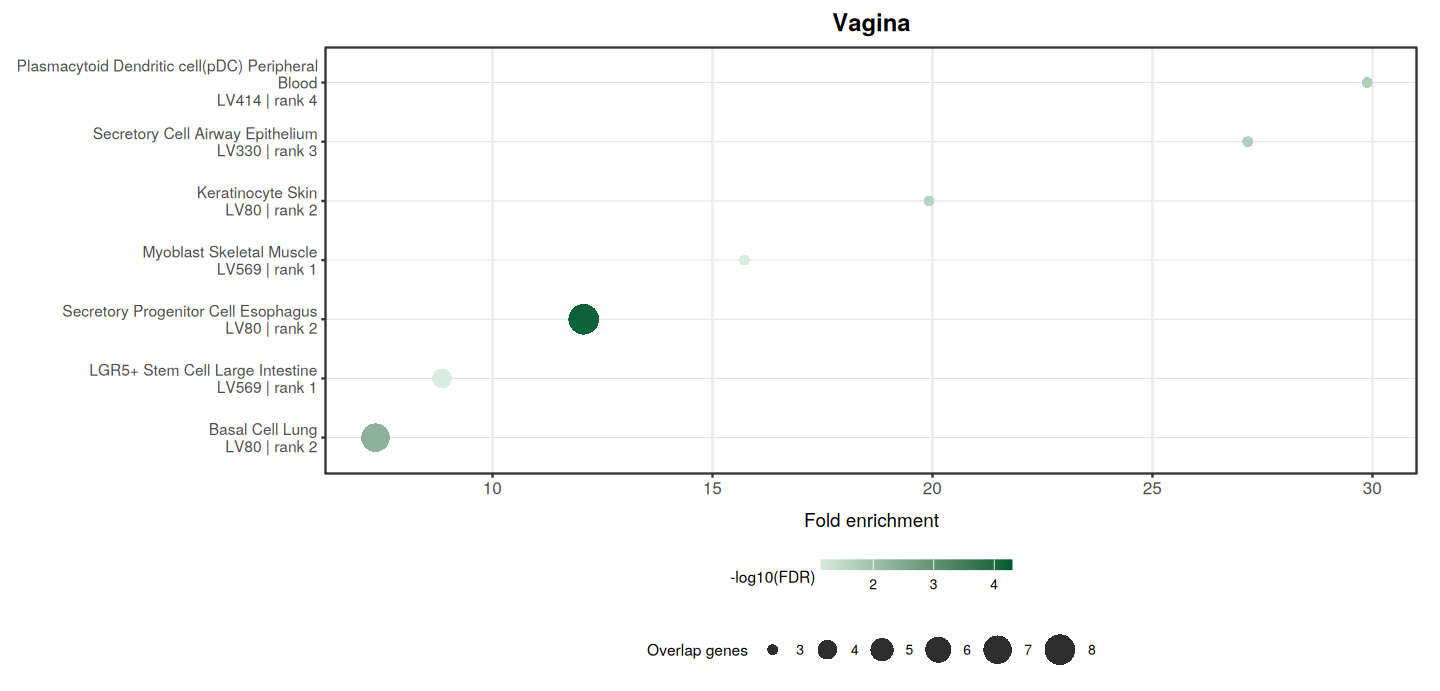

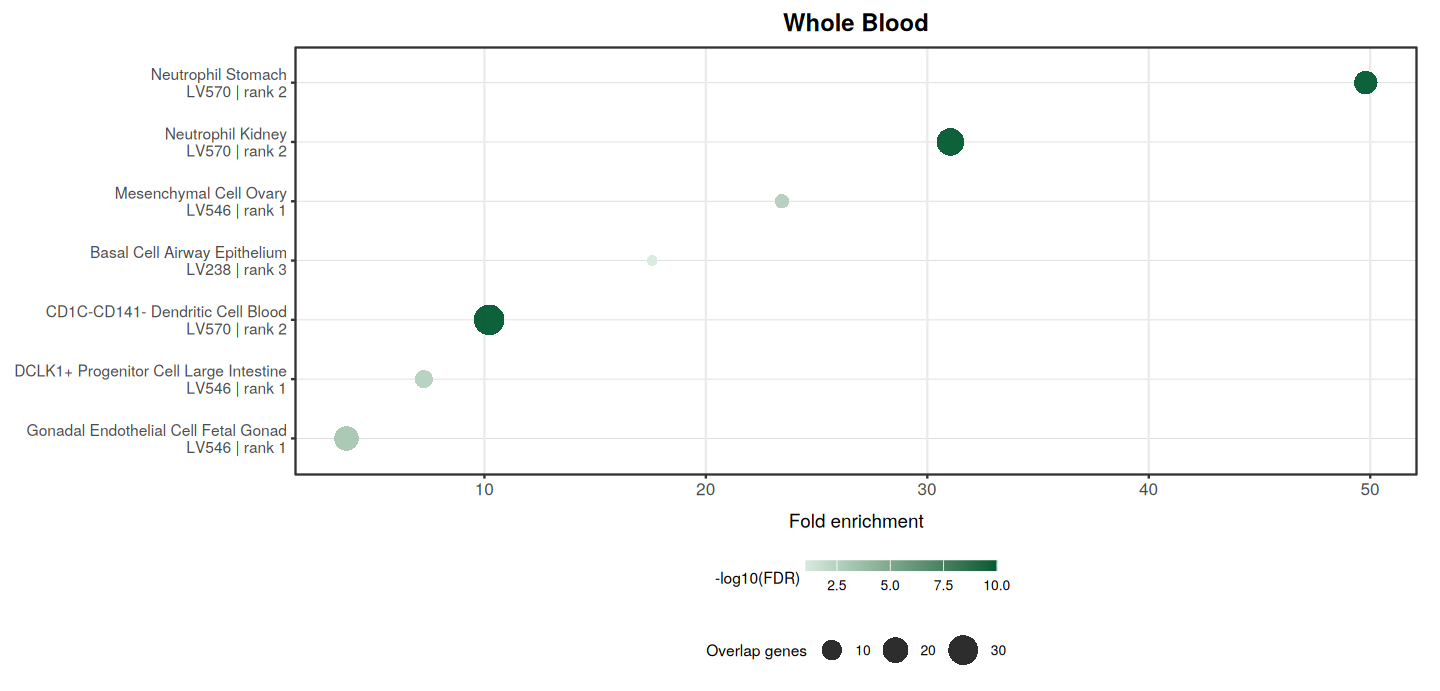

In [12]:
clean_cellmarker_label <- function(text, wrap_width = 48) {
    text <- str_remove(as.character(text), '[[:space:]]+Human$')
    text <- str_remove(text, '^[0-9]+-')
    text <- str_squish(text)
    str_wrap(text, width = wrap_width)
}

plot_cellmarker_tissue <- function(plot_df, tissue) {
    df <- plot_df %>%
        filter(Tissue == tissue) %>%
        arrange(desc(fold_enrich), p.adjust, Rank) %>%
        mutate(
            term_label = paste0(clean_cellmarker_label(ID), '\n', LV, ' | rank ', Rank),
            y_label_raw = paste0(sprintf('%03d', row_number()), '__', term_label),
            y_label_raw = factor(y_label_raw, levels = rev(unique(y_label_raw))),
            neg_log_fdr_cap = pmin(neg_log_fdr, 10)
        )

    if (nrow(df) == 0) {
        message('No CellMarker terms to plot for ', tissue)
        return(NULL)
    }

    options(
        repr.plot.width = 12,
        repr.plot.height = max(5.5, nrow(df) * 0.48 + 2.4)
    )

    ggplot(df, aes(x = fold_enrich, y = y_label_raw)) +
        geom_point(aes(size = Count, colour = neg_log_fdr_cap),
                   shape = 16, alpha = 0.95) +
        scale_y_discrete(labels = function(x) str_remove(x, '^[0-9]+__')) +
        scale_colour_gradient(low = '#d8eadf', high = '#005a32', name = '-log10(FDR)') +
        scale_size_continuous(range = c(2.4, 8), name = 'Overlap genes') +
        guides(
            colour = guide_colourbar(order = 1, barwidth = 8, barheight = 0.45),
            size = guide_legend(order = 2, nrow = 1, override.aes = list(colour = '#222222'))
        ) +
        labs(title = tissue, x = 'Fold enrichment', y = NULL) +
        coord_cartesian(clip = 'off') +
        theme_bw(base_size = 11) +
        theme(
            panel.grid.major.y = element_line(linewidth = 0.2, colour = '#dddddd'),
            panel.grid.minor = element_blank(),
            axis.text.y = element_text(size = 9, lineheight = 0.95),
            axis.text.x = element_text(size = 10),
            axis.title.x = element_text(size = 11, margin = margin(t = 8)),
            plot.title = element_text(face = 'bold', size = 14, hjust = 0.5),
            legend.position = 'bottom',
            legend.box = 'vertical',
            legend.title = element_text(size = 9),
            legend.text = element_text(size = 8),
            plot.margin = margin(8, 14, 8, 8)
        )
}

for (tissue in unique(selected_lvs_cum$Tissue)) {
    p <- plot_cellmarker_tissue(plot_df, tissue)
    if (!is.null(p)) print(p)
}
